# Prepare one 4D-CT patient and train canonical MedGS models

This notebook prepares one respiratory 4D-CT study and trains static MedGS models for one selected respiratory phase.

It:

1. selects a patient with `PATIENT_ID`;
2. unpacks that patient's DICOM series;
3. lists available studies and uses the manually selected `STUDY_INSTANCE_UID`;
4. identifies and orders the respiratory CT phases;
5. saves every phase as raw and Gaussian-denoised HU volumes;
6. provides an interactive original/denoised slice browser;
7. converts one canonical phase to the MedGS `original/` and `mirror/` layout;
8. trains and evaluates raw and denoised canonical models;
9. reports PSNR, SSIM, and LPIPS and provides an input/reconstruction browser.

The canonical model represents only one static respiratory phase. Respiratory deformation, temporal conditioning, and multi-phase training are added later in this notebook.

## How to use it

The notebook may be opened locally in PyCharm while running on a remote WORF or Helios kernel. All paths refer to the filesystem of the remote kernel.

For a normal run:

1. set `PATIENT_ID` and the training parameters;
2. unpack the selected patient;
3. inspect the study table;
4. assign the chosen full DICOM UID to `STUDY_INSTANCE_UID`;
5. run the remaining cells from top to bottom.

Prepared volumes, MedGS datasets, and completed models are reused unless the corresponding rebuild flags are enabled.

The Gaussian filter is only a simple raw-versus-denoised baseline, not a final medical denoising method.

## Outputs

```text
results/
├── prepared_4d_patients/
│   └── <PATIENT_ID>/
│       └── study_<UID_SUFFIX>/
│           ├── preparation.json
│           ├── phase_summary.csv
│           ├── phase_slice_manifest.csv
│           └── volumes/
│               ├── raw/
│               │   ├── phase_00.npy
│               │   └── ...
│               └── denoised/
│                   ├── phase_00.npy
│                   └── ...
└── canonical_medgs/
    └── patient_<PATIENT_ID>__study_<UID_SUFFIX>__phase_<PHASE>__<raw|denoised>__poly<P>__iter<N>/
        ├── run.json
        ├── frame_manifest.csv
        ├── dataset/
        │   ├── original/
        │   └── mirror/
        ├── model/
        ├── train_metrics.csv
        └── train_metrics_summary.csv
```

`<UID_SUFFIX>` is the last 12 digits of the full `StudyInstanceUID`. The complete UID is retained in the JSON and CSV metadata.

`prepared_4d_patients/` contains reusable study-level medical data. `canonical_medgs/` contains separate training experiments for different phases, input representations, and MedGS settings.


In [17]:
# Main configuration: normally this is the only cell that needs editing.

PATIENT_ID = "117_HM10395"

# Leave as None to select automatically the study with the most CT phases.
# STUDY_INSTANCE_UID = None

# The phase used to train the canonical MedGS model.
CANONICAL_PHASE_PERCENT = 20.0

# Choose which prepared representation is converted to MedGS PNG input.
TRAIN_ON_DENOISED = False

HU_WINDOW_LOW = -1000.0
HU_WINDOW_HIGH = 400.0

# Mild 3D Gaussian denoising in voxel units: (slice, row, column).
# DENOISE_SIGMA = (0.35, 0.70, 0.70)
DENOISE_SIGMA = (0.20, 0.40, 0.40)

ITERATIONS = 30_000
POLY_DEGREE = 2
BATCH_SIZE = 3
CAMERA = "mirror"

RUN_TRAINING = True
REUSE_COMPLETED_MODEL = True
REBUILD_PREPARED_VOLUMES = False
REBUILD_MEDGS_DATASET = False

## 1. Imports and project paths

Shared DICOM data and the MedGS repository are read from the existing project location. Generated arrays, PNG files, manifests, and model checkpoints are written under the current user's `medgs4d/results` directory.

In [ ]:
from __future__ import annotations

from pathlib import Path

import ipywidgets as widgets
import json
import numpy as np
import pandas as pd
import pydicom
import re
import shlex
import subprocess
import sys
import torch
from IPython.display import clear_output, display
from PIL import Image
from pydicom.dataset import Dataset
from scipy.ndimage import gaussian_filter
from typing import Any

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_rows", 500)

# ------------------------------------------------------------------
# Project paths
# ------------------------------------------------------------------

# WORF paths — active.
PROJECT_ROOT = Path(
    "/home/jovyan/shared/mtm_medgs_stack"
).resolve()

DATA_ROOT = (
        PROJECT_ROOT
        / "data"
        / "tcia_4d_lung"
)

SERIES_ZIPS_ROOT = (
        DATA_ROOT
        / "raw"
        / "series_zips"
)

DICOM_ROOT = (
        DATA_ROOT
        / "raw"
        / "dicom_by_series"
)

MEDGS4D_REPOSITORY = (
        PROJECT_ROOT
        / "repo"
        / "medgs4d"
)

MEDGS_REPOSITORY = (
        PROJECT_ROOT
        / "repo"
        / "MedGS"
)

RESULTS_ROOT = PROJECT_ROOT / "results"

# HELIOS paths — uncomment this block and comment out the WORF block
# when running the notebook on Helios.
#
# PROJECT_ROOT = Path(
#     "/net/storage/pr3/plgrid/plggtriplane/plgmozo/medgs4d"
# ).resolve()
#
# DATA_ROOT = PROJECT_ROOT / "data"
#
# SERIES_ZIPS_ROOT = (
#     DATA_ROOT
#     / "raw"
#     / "series_zips"
# )
#
# DICOM_ROOT = (
#     DATA_ROOT
#     / "raw"
#     / "dicom_by_series"
# )
#
# MEDGS4D_REPOSITORY = (
#     PROJECT_ROOT
#     / "repo"
#     / "medgs4d"
# )
#
# MEDGS_REPOSITORY = (
#     PROJECT_ROOT
#     / "repo"
#     / "MedGS"
# )
#
# RESULTS_ROOT = PROJECT_ROOT / "results"


PREPARED_4D_ROOT = (
        RESULTS_ROOT
        / "prepared_4d_patients"
)

CANONICAL_EXPERIMENTS_ROOT = (
        RESULTS_ROOT
        / "canonical_medgs"
)

required_paths = [DICOM_ROOT, MEDGS_REPOSITORY]
missing_paths = [path for path in required_paths if not path.is_dir()]
if missing_paths:
    raise FileNotFoundError(
        "Required directories are missing:\n"
        + "\n".join(str(path) for path in missing_paths)
    )



In [3]:
required_paths = [
    SERIES_ZIPS_ROOT,
    MEDGS4D_REPOSITORY,
    MEDGS_REPOSITORY,
]

missing_paths = [
    path
    for path in required_paths
    if not path.is_dir()
]

if missing_paths:
    raise FileNotFoundError(
        "Required directories are missing:\n"
        + "\n".join(str(path) for path in missing_paths)
    )

DICOM_ROOT.mkdir(parents=True, exist_ok=True)
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)
PREPARED_4D_ROOT.mkdir(parents=True, exist_ok=True)
CANONICAL_EXPERIMENTS_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

print(f"Python:           {sys.executable}")
print(f"CUDA available:   {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU:              {torch.cuda.get_device_name(0)}")

print(f"Project root:     {PROJECT_ROOT}")
print(f"Series ZIPs:      {SERIES_ZIPS_ROOT}")
print(f"DICOM root:       {DICOM_ROOT}")
print(f"MedGS4D repo:     {MEDGS4D_REPOSITORY}")
print(f"MedGS repository: {MEDGS_REPOSITORY}")
print(f"Results root:     {RESULTS_ROOT}")

Python:           /home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/bin/python
CUDA available:   True
GPU:              NVIDIA RTX A5500
Project root:     /home/jovyan/shared/mtm_medgs_stack
Series ZIPs:      /home/jovyan/shared/mtm_medgs_stack/data/tcia_4d_lung/raw/series_zips
DICOM root:       /home/jovyan/shared/mtm_medgs_stack/data/tcia_4d_lung/raw/dicom_by_series
MedGS4D repo:     /home/jovyan/shared/mtm_medgs_stack/repo/medgs4d
MedGS repository: /home/jovyan/shared/mtm_medgs_stack/repo/MedGS
Results root:     /home/jovyan/shared/mtm_medgs_stack/results


In [6]:
patient_ids = sorted(
    path.name
    for path in SERIES_ZIPS_ROOT.iterdir()
    if path.is_dir()
)

print(f"Available patients: {len(patient_ids)}\n")

for patient_id in patient_ids:
    marker = "  <-- selected" if patient_id == PATIENT_ID else ""
    print(f"{patient_id}{marker}")

Available patients: 20

100_HM10395
101_HM10395
102_HM10395
103_HM10395
104_HM10395
105_HM10395
106_HM10395
107_HM10395
108_HM10395
109_HM10395
110_HM10395
111_HM10395
112_HM10395
113_HM10395
114_HM10395
115_HM10395
116_HM10395
117_HM10395  <-- selected
118_HM10395
119_HM10395


In [22]:
import shutil

dataset_readers_path = (
        MEDGS_REPOSITORY
        / "models"
        / "scenes"
        / "dataset_readers.py"
)

source = dataset_readers_path.read_text(
    encoding="utf-8"
)

assert "dtype=np.byte" in source

source = source.replace(
    "dtype=np.byte",
    "dtype=np.uint8",
)

dataset_readers_path.write_text(
    source,
    encoding="utf-8",
)

# shutil.rmtree(model_root)

print(f"Patched MedGS reader: {dataset_readers_path}")
print(f"Removed failed model: {model_root}")

Patched MedGS reader: /home/jovyan/shared/mtm_medgs_stack/repo/MedGS/models/scenes/dataset_readers.py
Removed failed model: /home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__phase_20__raw__poly2__iter30000/model


## 2. DICOM helper functions

Respiratory phase percentages are read from `SeriesDescription`, exactly as in the earlier inspection notebook. Slices are ordered by their physical coordinate along the DICOM slice normal, not by filename.

In [5]:
# Extract the selected patient using the existing MedGS4D
# extraction and verification functions.

from concurrent.futures import ThreadPoolExecutor
import importlib.util

UNPACK_SCRIPT = (
        MEDGS4D_REPOSITORY
        / "scripts"
        / "unpack_4d_lung.py"
)

if not UNPACK_SCRIPT.is_file():
    raise FileNotFoundError(
        f"Unpacking script not found: {UNPACK_SCRIPT}"
    )

spec = importlib.util.spec_from_file_location(
    "medgs4d_unpack_4d_lung",
    UNPACK_SCRIPT,
)

if spec is None or spec.loader is None:
    raise RuntimeError(
        f"Could not load the unpacking script: {UNPACK_SCRIPT}"
    )

unpack_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(unpack_module)

archives = unpack_module.discover_archives(
    SERIES_ZIPS_ROOT,
    [PATIENT_ID],
)

if not archives:
    raise FileNotFoundError(
        f"No ZIP archives found for patient {PATIENT_ID} "
        f"under {SERIES_ZIPS_ROOT}"
    )

tasks = [
    (
        str(archive),
        str(SERIES_ZIPS_ROOT),
        str(DICOM_ROOT),
        False,  # force
        False,  # dry_run
    )
    for archive in archives
]

print(f"Patient:             {PATIENT_ID}")
print(f"Selected archives:   {len(archives)}")
print(f"Archive root:        {SERIES_ZIPS_ROOT}")
print(f"Destination root:    {DICOM_ROOT}")
print("Extracting and verifying series...")

worker_count = min(4, len(tasks))

with ThreadPoolExecutor(
        max_workers=worker_count
) as executor:
    results = list(
        executor.map(
            unpack_module.extract_one,
            tasks,
        )
    )

status_counts = {}

for result in results:
    status = result["status"]
    status_counts[status] = (
            status_counts.get(status, 0) + 1
    )

print("\nExtraction summary:")

for status in (
        "extracted",
        "skipped",
        "failed",
):
    print(
        f"  {status.capitalize():10s}: "
        f"{status_counts.get(status, 0)}"
    )

failed_results = [
    result
    for result in results
    if result["status"] == "failed"
]

if failed_results:
    failed_preview = "\n".join(
        (
            f"{result['archive']}: "
            f"{result['message']}"
        )
        for result in failed_results[:10]
    )

    raise RuntimeError(
        "Some archives could not be extracted:\n"
        + failed_preview
    )

patient_dicom_root = DICOM_ROOT / PATIENT_ID

extracted_series = sorted(
    path
    for path in patient_dicom_root.iterdir()
    if path.is_dir()
    and not path.name.startswith(".")
)

print(
    f"\nPatient {PATIENT_ID}: "
    f"{len(extracted_series)} extracted series."
)
print(f"Patient DICOM root: {patient_dicom_root}")

Patient:             117_HM10395
Selected archives:   420
Archive root:        /home/jovyan/shared/mtm_medgs_stack/data/tcia_4d_lung/raw/series_zips
Destination root:    /home/jovyan/shared/mtm_medgs_stack/data/tcia_4d_lung/raw/dicom_by_series
Extracting and verifying series...

Extraction summary:
  Extracted : 420
  Skipped   : 0
  Failed    : 0

Patient 117_HM10395: 420 extracted series.
Patient DICOM root: /home/jovyan/shared/mtm_medgs_stack/data/tcia_4d_lung/raw/dicom_by_series/117_HM10395


In [7]:
PHASE_PATTERN = re.compile(r"(\d+(?:\.\d+)?)\s*%")


def parse_phase_percent(description: str) -> float:
    """Extract a respiratory phase percentage or return NaN."""

    match = PHASE_PATTERN.search(description)
    return float(match.group(1)) if match else float("nan")


def phase_tag(phase: float) -> str:
    """Return a filesystem-safe phase label."""

    return f"{phase:g}".replace(".", "p")


def list_dicom_files(series_dir: Path) -> list[Path]:
    """Return DICOM files stored directly in one series directory."""

    return sorted(path for path in series_dir.glob("*.dcm") if path.is_file())


def read_float_vector(
        dataset: Dataset,
        attribute: str,
        expected_length: int,
) -> np.ndarray:
    """Read a required fixed-length numeric DICOM vector."""

    if not hasattr(dataset, attribute):
        raise ValueError(f"Missing DICOM attribute {attribute}.")

    vector = np.asarray(
        [float(value) for value in getattr(dataset, attribute)],
        dtype=np.float64,
    )
    if vector.size != expected_length:
        raise ValueError(
            f"{attribute} has length {vector.size}; expected {expected_length}."
        )
    return vector


def slice_coordinate(dataset: Dataset) -> float:
    """Calculate the signed position along the DICOM slice normal."""

    position = read_float_vector(dataset, "ImagePositionPatient", 3)
    orientation = read_float_vector(dataset, "ImageOrientationPatient", 6)
    normal = np.cross(orientation[:3], orientation[3:])
    normal /= np.linalg.norm(normal)
    return float(np.dot(position, normal))


def inspect_series(patient_directory: Path) -> pd.DataFrame:
    """Read one representative header from every patient series."""

    records: list[dict[str, Any]] = []
    for series_dir in sorted(path for path in patient_directory.iterdir() if path.is_dir()):
        files = list_dicom_files(series_dir)
        if not files:
            continue

        dataset = pydicom.dcmread(
            str(files[0]), stop_before_pixels=True, force=True
        )
        description = str(getattr(dataset, "SeriesDescription", ""))
        records.append(
            {
                "StudyDate": str(getattr(dataset, "StudyDate", "")),
                "StudyDescription": str(
                    getattr(dataset, "StudyDescription", "")
                ),
                "StudyInstanceUID": str(
                    getattr(dataset, "StudyInstanceUID", "")
                ),
                "Modality": str(getattr(dataset, "Modality", "")),
                "PhasePercent": parse_phase_percent(description),
                "SeriesNumber": getattr(dataset, "SeriesNumber", ""),
                "SeriesDescription": description,
                "SeriesInstanceUID": str(
                    getattr(dataset, "SeriesInstanceUID", "")
                ),
                "DICOM files": len(files),
                "Series path": str(series_dir),
            }
        )

    frame = pd.DataFrame(records)
    if frame.empty:
        raise RuntimeError(f"No readable DICOM series found in {patient_directory}.")
    return frame


def read_slice_table(
        series_dir: Path,
        expected_series_uid: str,
) -> pd.DataFrame:
    """Read and physically order all CT slices from one series."""

    records: list[dict[str, Any]] = []
    for path in list_dicom_files(series_dir):
        dataset = pydicom.dcmread(
            str(path), stop_before_pixels=True, force=True
        )
        if str(getattr(dataset, "Modality", "")) != "CT":
            raise ValueError(f"Non-CT object found: {path}")
        if str(getattr(dataset, "SeriesInstanceUID", "")) != expected_series_uid:
            raise ValueError(f"Unexpected SeriesInstanceUID in {path}")

        position = read_float_vector(dataset, "ImagePositionPatient", 3)
        orientation = read_float_vector(
            dataset, "ImageOrientationPatient", 6
        )
        pixel_spacing = read_float_vector(dataset, "PixelSpacing", 2)

        records.append(
            {
                "File": path.name,
                "Path": str(path),
                "SOPInstanceUID": str(
                    getattr(dataset, "SOPInstanceUID", "")
                ),
                "InstanceNumber": int(
                    getattr(dataset, "InstanceNumber", -1)
                ),
                "SliceCoordinate": slice_coordinate(dataset),
                "PositionX": float(position[0]),
                "PositionY": float(position[1]),
                "PositionZ": float(position[2]),
                "Rows": int(dataset.Rows),
                "Columns": int(dataset.Columns),
                "PixelSpacingRow": float(pixel_spacing[0]),
                "PixelSpacingColumn": float(pixel_spacing[1]),
                "SliceThickness": float(
                    getattr(dataset, "SliceThickness", np.nan)
                ),
                "RescaleSlope": float(
                    getattr(dataset, "RescaleSlope", 1.0)
                ),
                "RescaleIntercept": float(
                    getattr(dataset, "RescaleIntercept", 0.0)
                ),
                "Orientation": tuple(float(value) for value in orientation),
            }
        )

    frame = pd.DataFrame(records).sort_values(
        ["SliceCoordinate", "InstanceNumber", "File"]
    ).reset_index(drop=True)
    frame.insert(0, "SliceIndex", np.arange(len(frame), dtype=int))
    return frame


def read_hu_image(path: Path) -> np.ndarray:
    """Read one CT slice and convert stored values to Hounsfield units."""

    dataset = pydicom.dcmread(str(path), force=True)
    pixels = dataset.pixel_array.astype(np.float32)
    slope = float(getattr(dataset, "RescaleSlope", 1.0))
    intercept = float(getattr(dataset, "RescaleIntercept", 0.0))
    return pixels * slope + intercept


def window_hu(image_hu: np.ndarray, low: float, high: float) -> np.ndarray:
    """Clip one HU image and normalize it to [0, 1]."""

    if high <= low:
        raise ValueError("HU_WINDOW_HIGH must exceed HU_WINDOW_LOW.")
    clipped = np.clip(image_hu, low, high)
    return (clipped - low) / (high - low)


def grayscale_to_rgb_uint8(image: np.ndarray) -> np.ndarray:
    """Convert normalized grayscale to three-channel uint8 RGB."""

    grayscale = np.round(image * 255.0).astype(np.uint8)
    return np.repeat(grayscale[..., None], 3, axis=2)

## 3. Select the patient, study, and one CT series per phase

If multiple studies exist for the patient, automatic selection prefers the study with the largest number of distinct respiratory phases and then the largest total number of CT slices. Within a phase, the CT series with the largest slice count is selected.

In [10]:
patient_dir = DICOM_ROOT / PATIENT_ID

series_df = inspect_series(patient_dir)

ct_phase_series_df = series_df.loc[
    (series_df["Modality"] == "CT")
    & series_df["PhasePercent"].notna()
    ].copy()

if ct_phase_series_df.empty:
    raise RuntimeError(
        f"No phase-labelled CT series found for patient {PATIENT_ID}."
    )

study_summary_df = (
    ct_phase_series_df.groupby(
        "StudyInstanceUID",
        as_index=False,
    )
    .agg(
        StudyDate=("StudyDate", "first"),
        StudyDescription=("StudyDescription", "first"),
        Phases=("PhasePercent", "nunique"),
        CTSeries=("SeriesInstanceUID", "nunique"),
        TotalSlices=("DICOM files", "sum"),
    )
    .sort_values(
        ["Phases", "TotalSlices"],
        ascending=[False, False],
    )
    .reset_index(drop=True)
)

study_summary_df.insert(
    0,
    "StudyIndex",
    study_summary_df.index,
)

print(f"Patient:          {PATIENT_ID}")
print(f"Detected studies: {len(study_summary_df)}")
print()
# print(study_summary_df.to_string(index=False))

display(study_summary_df)

Patient:          117_HM10395
Detected studies: 34



,StudyIndex,StudyInstanceUID,StudyDate,StudyDescription,Phases,CTSeries,TotalSlices
0,0,1.3.6.1.4.1.14519.5.2.1.6834.5010.378204929111417980831212264180,20001024,p4,10,10,1470
1,1,1.3.6.1.4.1.14519.5.2.1.6834.5010.262507920541737267747764039873,20001031,p4,10,10,1170
2,2,1.3.6.1.4.1.14519.5.2.1.6834.5010.292491295549436721879304177874,20001107,p4,10,10,1170
3,3,1.3.6.1.4.1.14519.5.2.1.6834.5010.158466884027749484040796826752,20001128,p4,10,10,1050
4,4,1.3.6.1.4.1.14519.5.2.1.6834.5010.154051254217750840976295179553,20001121,p4,10,10,910
5,5,1.3.6.1.4.1.14519.5.2.1.6834.5010.322681136408267760646893201309,20001204,p4,10,10,900
6,6,1.3.6.1.4.1.14519.5.2.1.6834.5010.183612837156574038288724943681,20001117,p4,10,10,880
7,7,1.3.6.1.4.1.14519.5.2.1.6834.5010.253771392853795552765799739432,20001009,p4,10,10,770
8,8,1.3.6.1.4.1.14519.5.2.1.6834.5010.107025610280264464701477361897,20001019,p4,10,10,500
9,9,1.3.6.1.4.1.14519.5.2.1.6834.5010.115679706801800900578804691850,20001106,p4,10,10,500


In [24]:
# Select one StudyInstanceUID from the table above.
STUDY_INSTANCE_UID = (
    "1.3.6.1.4.1.14519.5.2.1.6834.5010."
    "378204929111417980831212264180"
)

In [12]:

selected_study_uid = STUDY_INSTANCE_UID

selected_study_series_df = ct_phase_series_df.loc[
    ct_phase_series_df["StudyInstanceUID"]
    == selected_study_uid
    ].copy()

if selected_study_series_df.empty:
    raise ValueError(
        f"Study not found for patient {PATIENT_ID}: "
        f"{selected_study_uid}"
    )

phase_series_df = (
    selected_study_series_df.sort_values(
        [
            "PhasePercent",
            "DICOM files",
            "SeriesInstanceUID",
        ],
        ascending=[True, False, True],
    )
    .drop_duplicates(
        subset=["PhasePercent"],
        keep="first",
    )
    .sort_values("PhasePercent")
    .reset_index(drop=True)
)

selected_study_info = study_summary_df.loc[
    study_summary_df["StudyInstanceUID"]
    == selected_study_uid
    ].iloc[0]

phase_summary_df = phase_series_df[
    [
        "PhasePercent",
        "DICOM files",
        "SeriesNumber",
        "SeriesDescription",
        "SeriesInstanceUID",
        "Series path",
    ]
].copy()

print(f"Selected patient: {PATIENT_ID}")
print(f"Selected study:   {selected_study_uid}")
print(f"Study date:       {selected_study_info['StudyDate']}")
print(f"Detected phases:  {len(phase_series_df)}")
print(f"Total slices:     {selected_study_info['TotalSlices']}")
print()
# print(phase_summary_df.to_string(index=False))

display(phase_summary_df)

Selected patient: 117_HM10395
Selected study:   1.3.6.1.4.1.14519.5.2.1.6834.5010.378204929111417980831212264180
Study date:       20001024
Detected phases:  10
Total slices:     1470



,PhasePercent,DICOM files,SeriesNumber,SeriesDescription,SeriesInstanceUID,Series path
0,0.0,147,1,"P4^P117^S301^I00003, Gated, 0.0%A",1.3.6.1.4.1.14519.5.2.1.6834.5010.148529694733361305012151030542,/home/jovyan/shared/mtm_medgs_stack/data/tcia_4d_lung/raw/dicom_by_series/117_HM10395/1.3.6.1.4.1.14519.5.2.1.6834.5...
1,10.0,147,1,"P4^P117^S301^I00004, Gated, 10.0%A",1.3.6.1.4.1.14519.5.2.1.6834.5010.126969234347231214775450287756,/home/jovyan/shared/mtm_medgs_stack/data/tcia_4d_lung/raw/dicom_by_series/117_HM10395/1.3.6.1.4.1.14519.5.2.1.6834.5...
2,20.0,147,1,"P4^P117^S301^I00005, Gated, 20.0%A",1.3.6.1.4.1.14519.5.2.1.6834.5010.604396030201226976476677184587,/home/jovyan/shared/mtm_medgs_stack/data/tcia_4d_lung/raw/dicom_by_series/117_HM10395/1.3.6.1.4.1.14519.5.2.1.6834.5...
3,30.0,147,1,"P4^P117^S301^I00006, Gated, 30.0%A",1.3.6.1.4.1.14519.5.2.1.6834.5010.265853994490570208708415104191,/home/jovyan/shared/mtm_medgs_stack/data/tcia_4d_lung/raw/dicom_by_series/117_HM10395/1.3.6.1.4.1.14519.5.2.1.6834.5...
4,40.0,147,1,"P4^P117^S301^I00007, Gated, 40.0%A",1.3.6.1.4.1.14519.5.2.1.6834.5010.268641441554830768026549171437,/home/jovyan/shared/mtm_medgs_stack/data/tcia_4d_lung/raw/dicom_by_series/117_HM10395/1.3.6.1.4.1.14519.5.2.1.6834.5...
5,50.0,147,1,"P4^P117^S301^I00008, Gated, 50.0%A",1.3.6.1.4.1.14519.5.2.1.6834.5010.142000484786251122043719870687,/home/jovyan/shared/mtm_medgs_stack/data/tcia_4d_lung/raw/dicom_by_series/117_HM10395/1.3.6.1.4.1.14519.5.2.1.6834.5...
6,60.0,147,1,"P4^P117^S301^I00009, Gated, 60.0%A",1.3.6.1.4.1.14519.5.2.1.6834.5010.183882293876244172928996511379,/home/jovyan/shared/mtm_medgs_stack/data/tcia_4d_lung/raw/dicom_by_series/117_HM10395/1.3.6.1.4.1.14519.5.2.1.6834.5...
7,70.0,147,1,"P4^P117^S301^I00010, Gated, 70.0%A",1.3.6.1.4.1.14519.5.2.1.6834.5010.240633073422000755437203884091,/home/jovyan/shared/mtm_medgs_stack/data/tcia_4d_lung/raw/dicom_by_series/117_HM10395/1.3.6.1.4.1.14519.5.2.1.6834.5...
8,80.0,147,1,"P4^P117^S301^I00011, Gated, 80.0%A",1.3.6.1.4.1.14519.5.2.1.6834.5010.213548587798491983341081227810,/home/jovyan/shared/mtm_medgs_stack/data/tcia_4d_lung/raw/dicom_by_series/117_HM10395/1.3.6.1.4.1.14519.5.2.1.6834.5...
9,90.0,147,1,"P4^P117^S301^I00012, Gated, 90.0%A",1.3.6.1.4.1.14519.5.2.1.6834.5010.329406950451472064474907839203,/home/jovyan/shared/mtm_medgs_stack/data/tcia_4d_lung/raw/dicom_by_series/117_HM10395/1.3.6.1.4.1.14519.5.2.1.6834.5...


## 4. Read and summarize all phase stacks

Each phase is ordered independently by physical slice position. The summary below shows whether the phase stacks have matching image geometry and comparable coordinate ranges. No resampling is performed in this simple preparation notebook.

In [14]:
assert phase_series_df["StudyInstanceUID"].astype(str).eq(
    str(STUDY_INSTANCE_UID)
).all()

phase_slice_tables: dict[float, pd.DataFrame] = {}
phase_summary_rows = []

for _, phase_row in phase_series_df.iterrows():
    phase = float(phase_row["PhasePercent"])

    table = read_slice_table(
        Path(phase_row["Series path"]),
        str(phase_row["SeriesInstanceUID"]),
    )

    coordinates = table["SliceCoordinate"].to_numpy(dtype=float)
    spacings = np.diff(coordinates)

    assert len(table) >= 3
    assert np.all(spacings > 0)

    phase_slice_tables[phase] = table

    phase_summary_rows.append(
        {
            "PhasePercent": phase,
            "Slices": len(table),
            "Rows": int(table.iloc[0]["Rows"]),
            "Columns": int(table.iloc[0]["Columns"]),
            "FirstCoordinate": float(coordinates[0]),
            "LastCoordinate": float(coordinates[-1]),
            "MedianSpacing": float(np.median(spacings)),
            "PixelSpacingRow": float(
                table.iloc[0]["PixelSpacingRow"]
            ),
            "PixelSpacingColumn": float(
                table.iloc[0]["PixelSpacingColumn"]
            ),
        }
    )

phase_summary_df = (
    pd.DataFrame(phase_summary_rows)
    .sort_values("PhasePercent")
    .reset_index(drop=True)
)

print(f"Patient:            {PATIENT_ID}")
print(f"Study:              {STUDY_INSTANCE_UID}")
print(f"Respiratory phases: {len(phase_summary_df)}")
print(f"Total CT slices:    {int(phase_summary_df['Slices'].sum())}")
print(
    "Slices per phase:  "
    f"min={int(phase_summary_df['Slices'].min())}, "
    f"max={int(phase_summary_df['Slices'].max())}"
)

display(phase_summary_df)

Patient:            117_HM10395
Study:              1.3.6.1.4.1.14519.5.2.1.6834.5010.378204929111417980831212264180
Respiratory phases: 10
Total CT slices:    1470
Slices per phase:  min=147, max=147


,PhasePercent,Slices,Rows,Columns,FirstCoordinate,LastCoordinate,MedianSpacing,PixelSpacingRow,PixelSpacingColumn
0,0.0,147,512,512,-266.2,171.8,3.0,0.9766,0.9766
1,10.0,147,512,512,-266.2,171.8,3.0,0.9766,0.9766
2,20.0,147,512,512,-266.2,171.8,3.0,0.9766,0.9766
3,30.0,147,512,512,-266.2,171.8,3.0,0.9766,0.9766
4,40.0,147,512,512,-266.2,171.8,3.0,0.9766,0.9766
5,50.0,147,512,512,-266.2,171.8,3.0,0.9766,0.9766
6,60.0,147,512,512,-266.2,171.8,3.0,0.9766,0.9766
7,70.0,147,512,512,-266.2,171.8,3.0,0.9766,0.9766
8,80.0,147,512,512,-266.2,171.8,3.0,0.9766,0.9766
9,90.0,147,512,512,-266.2,171.8,3.0,0.9766,0.9766


## 5. Prepare original and mildly denoised HU volumes

For every phase, the notebook writes two NumPy arrays:

- `raw/phase_*.npy`: original HU values read from DICOM;
- `denoised/phase_*.npy`: the same volume after a mild 3D Gaussian filter.

Volumes are processed one phase at a time, so the complete 4D dataset is not held twice in RAM. The `.npy` format also allows memory-mapped browsing without loading all phases at once.

In [18]:
study_tag = str(STUDY_INSTANCE_UID)[-12:]

patient_prepared_root = (
        PREPARED_4D_ROOT
        / PATIENT_ID
        / f"study_{study_tag}"
)

raw_volumes_root = patient_prepared_root / "volumes" / "raw"
denoised_volumes_root = (
        patient_prepared_root
        / "volumes"
        / "denoised"
)

raw_volumes_root.mkdir(parents=True, exist_ok=True)
denoised_volumes_root.mkdir(parents=True, exist_ok=True)

phase_volume_paths: dict[tuple[float, bool], Path] = {}
manifest_parts = []

for phase, table in phase_slice_tables.items():
    tag = phase_tag(phase)

    raw_path = raw_volumes_root / f"phase_{tag}.npy"
    denoised_path = (
            denoised_volumes_root
            / f"phase_{tag}.npy"
    )

    rebuild_raw = (
            REBUILD_PREPARED_VOLUMES
            or not raw_path.is_file()
    )

    if rebuild_raw:
        print(f"Reading phase {phase:g}%: {len(table)} slices")

        raw_volume = np.stack(
            [
                read_hu_image(Path(path))
                for path in table["Path"]
            ],
            axis=0,
        ).astype(np.float32)

        np.save(raw_path, raw_volume)

    else:
        raw_volume = np.load(
            raw_path,
            mmap_mode="r",
        )

    rebuild_denoised = (
            REBUILD_PREPARED_VOLUMES
            or not denoised_path.is_file()
    )

    if rebuild_denoised:
        print(
            f"Denoising phase {phase:g}% "
            f"with sigma={DENOISE_SIGMA}"
        )

        denoised_volume = gaussian_filter(
            np.asarray(
                raw_volume,
                dtype=np.float32,
            ),
            sigma=DENOISE_SIGMA,
            mode="nearest",
        ).astype(np.float32)

        np.save(
            denoised_path,
            denoised_volume,
        )

    phase_volume_paths[(phase, False)] = raw_path
    phase_volume_paths[(phase, True)] = denoised_path

    phase_manifest = table.copy()
    phase_manifest.insert(
        0,
        "PhasePercent",
        phase,
    )

    phase_manifest["StudyInstanceUID"] = str(
        STUDY_INSTANCE_UID
    )
    phase_manifest["RawVolumePath"] = str(raw_path)
    phase_manifest["DenoisedVolumePath"] = str(
        denoised_path
    )

    manifest_parts.append(phase_manifest)

all_slices_manifest_df = (
    pd.concat(
        manifest_parts,
        ignore_index=True,
    )
    .sort_values(
        ["PhasePercent", "SliceIndex"]
    )
    .reset_index(drop=True)
)

manifest_path = (
        patient_prepared_root
        / "phase_slice_manifest.csv"
)

summary_path = (
        patient_prepared_root
        / "phase_summary.csv"
)

config_path = (
        patient_prepared_root
        / "preparation.json"
)

all_slices_manifest_df.to_csv(
    manifest_path,
    index=False,
)

phase_summary_df.to_csv(
    summary_path,
    index=False,
)

preparation_config = {
    "patient_id": PATIENT_ID,
    "study_instance_uid": str(STUDY_INSTANCE_UID),
    "phases": sorted(
        float(value)
        for value in phase_slice_tables
    ),
    "hu_window": [
        HU_WINDOW_LOW,
        HU_WINDOW_HIGH,
    ],
    "denoise_method": "scipy.ndimage.gaussian_filter",
    "denoise_sigma_voxels": list(DENOISE_SIGMA),
    "raw_volumes_root": str(raw_volumes_root),
    "denoised_volumes_root": str(
        denoised_volumes_root
    ),
    "manifest": str(manifest_path),
}

config_path.write_text(
    json.dumps(
        preparation_config,
        indent=2,
    )
    + "\n",
    encoding="utf-8",
)

print(f"Patient:               {PATIENT_ID}")
print(f"Study:                 {STUDY_INSTANCE_UID}")
print(f"Prepared patient root: {patient_prepared_root}")
print(f"Manifest:              {manifest_path}")
print(f"Raw volumes:           {raw_volumes_root}")
print(f"Denoised volumes:      {denoised_volumes_root}")

Reading phase 0%: 147 slices
Denoising phase 0% with sigma=(0.2, 0.4, 0.4)
Reading phase 10%: 147 slices
Denoising phase 10% with sigma=(0.2, 0.4, 0.4)
Reading phase 20%: 147 slices
Denoising phase 20% with sigma=(0.2, 0.4, 0.4)
Reading phase 30%: 147 slices
Denoising phase 30% with sigma=(0.2, 0.4, 0.4)
Reading phase 40%: 147 slices
Denoising phase 40% with sigma=(0.2, 0.4, 0.4)
Reading phase 50%: 147 slices
Denoising phase 50% with sigma=(0.2, 0.4, 0.4)
Reading phase 60%: 147 slices
Denoising phase 60% with sigma=(0.2, 0.4, 0.4)
Reading phase 70%: 147 slices
Denoising phase 70% with sigma=(0.2, 0.4, 0.4)
Reading phase 80%: 147 slices
Denoising phase 80% with sigma=(0.2, 0.4, 0.4)
Reading phase 90%: 147 slices
Denoising phase 90% with sigma=(0.2, 0.4, 0.4)
Patient:               117_HM10395
Study:                 None
Prepared patient root: /home/jovyan/shared/mtm_medgs_stack/results/prepared_4d_patients/117_HM10395/study_None
Manifest:              /home/jovyan/shared/mtm_medgs_stack

## 6. Interactive phase and slice browser

Use the phase slider to move through respiratory time, the slice slider to move through the ordered CT stack, and the checkbox to switch between the original and denoised volume.

In [19]:
available_phases = sorted(phase_slice_tables)
initial_phase = float(CANONICAL_PHASE_PERCENT)

phase_slider = widgets.SelectionSlider(
    options=[
        (f"{phase:g}%", phase)
        for phase in available_phases
    ],
    value=initial_phase,
    description="Phase",
    continuous_update=False,
    layout=widgets.Layout(width="650px"),
)

slice_slider = widgets.IntSlider(
    value=len(phase_slice_tables[initial_phase]) // 2,
    min=0,
    max=len(phase_slice_tables[initial_phase]) - 1,
    step=1,
    description="Slice",
    continuous_update=False,
    layout=widgets.Layout(width="650px"),
)

denoised_checkbox = widgets.Checkbox(
    value=False,
    description="Show denoised",
    indent=False,
)

browser_output = widgets.Output()


def update_slice_range(change: dict | None = None) -> None:
    """Update the valid slice range after changing the phase."""

    phase = float(phase_slider.value)
    maximum = len(phase_slice_tables[phase]) - 1

    slice_slider.max = maximum
    slice_slider.value = min(
        slice_slider.value,
        maximum,
    )


def draw_selected_slice(change: dict | None = None) -> None:
    """Render the selected CT slice."""

    phase = float(phase_slider.value)
    slice_index = int(slice_slider.value)
    use_denoised = bool(denoised_checkbox.value)

    volume = np.load(
        phase_volume_paths[(phase, use_denoised)],
        mmap_mode="r",
    )

    table = phase_slice_tables[phase]
    row = table.iloc[slice_index]

    image = window_hu(
        np.asarray(volume[slice_index]),
        HU_WINDOW_LOW,
        HU_WINDOW_HIGH,
    )

    representation = (
        "denoised"
        if use_denoised
        else "original"
    )

    with browser_output:
        clear_output(wait=True)

        plt.figure(figsize=(7, 7))
        plt.imshow(
            image,
            cmap="gray",
            vmin=0.0,
            vmax=1.0,
        )

        plt.title(
            f"Patient {PATIENT_ID} | "
            f"phase {phase:g}% | "
            f"slice {slice_index}/{len(table) - 1}\n"
            f"{representation} | "
            f"coordinate "
            f"{row['SliceCoordinate']:.3f} mm | "
            f"HU [{HU_WINDOW_LOW:g}, {HU_WINDOW_HIGH:g}]"
        )

        plt.axis("off")
        plt.tight_layout()
        plt.show()


phase_slider.observe(
    update_slice_range,
    names="value",
)

phase_slider.observe(
    draw_selected_slice,
    names="value",
)

slice_slider.observe(
    draw_selected_slice,
    names="value",
)

denoised_checkbox.observe(
    draw_selected_slice,
    names="value",
)

update_slice_range()
draw_selected_slice()

display(
    widgets.VBox(
        [
            phase_slider,
            slice_slider,
            denoised_checkbox,
            browser_output,
        ]
    )
)

## 7. Select the canonical phase and create the MedGS image dataset

All slices from the selected phase are used. Each HU slice is windowed to `[0, 1]`, converted to RGB PNG, and written both in its original orientation and as a horizontal mirror, matching the existing MedGS input convention.

In [20]:
matching_phases = [
    phase
    for phase in available_phases
    if np.isclose(phase, CANONICAL_PHASE_PERCENT)
]
if len(matching_phases) != 1:
    raise ValueError(
        f"Canonical phase {CANONICAL_PHASE_PERCENT:g}% is unavailable. "
        f"Available phases: {available_phases}"
    )

canonical_phase = float(matching_phases[0])
canonical_table = phase_slice_tables[canonical_phase]
representation_name = "denoised" if TRAIN_ON_DENOISED else "raw"

run_name = (
    f"patient_{PATIENT_ID}"
    f"__phase_{phase_tag(canonical_phase)}"
    f"__{representation_name}"
    f"__poly{POLY_DEGREE}"
    f"__iter{ITERATIONS}"
)

run_root = CANONICAL_EXPERIMENTS_ROOT / run_name
medgs_dataset_root = run_root / "dataset"
original_images_root = medgs_dataset_root / "original"
mirror_images_root = medgs_dataset_root / "mirror"
model_root = run_root / "model"

source_volume_path = phase_volume_paths[
    (canonical_phase, TRAIN_ON_DENOISED)
]
source_volume = np.load(source_volume_path, mmap_mode="r")

existing_originals = sorted(original_images_root.glob("*.png"))
expected_frames = len(canonical_table)
can_reuse_dataset = (
        not REBUILD_MEDGS_DATASET
        and len(existing_originals) == expected_frames
        and len(list(mirror_images_root.glob("*.png"))) == expected_frames
)

if can_reuse_dataset:
    print(f"Reusing existing MedGS dataset: {medgs_dataset_root}")
else:
    shutil.rmtree(medgs_dataset_root, ignore_errors=True)
    original_images_root.mkdir(parents=True)
    mirror_images_root.mkdir(parents=True)

    frame_rows = []
    for frame_index in range(expected_frames):
        normalized = window_hu(
            np.asarray(source_volume[frame_index]),
            HU_WINDOW_LOW,
            HU_WINDOW_HIGH,
        )
        rgb = grayscale_to_rgb_uint8(normalized)
        filename = f"{frame_index:04d}.png"
        original_path = original_images_root / filename
        mirror_path = mirror_images_root / filename
        Image.fromarray(rgb).save(original_path)
        Image.fromarray(np.fliplr(rgb)).save(mirror_path)

        row = canonical_table.iloc[frame_index]
        frame_rows.append(
            {
                "FrameIndex": frame_index,
                "SliceIndex": int(row["SliceIndex"]),
                "SliceCoordinate": float(row["SliceCoordinate"]),
                "DICOMPath": str(row["Path"]),
                "OriginalPNG": str(original_path),
                "MirrorPNG": str(mirror_path),
            }
        )

    pd.DataFrame(frame_rows).to_csv(
        run_root / "frame_manifest.csv", index=False
    )

print(f"Canonical phase:       {canonical_phase:g}%")
print(f"Input representation:  {representation_name}")
print(f"Canonical slices:      {expected_frames}")
print(f"MedGS dataset:         {medgs_dataset_root}")
print(f"Model output:          {model_root}")

Canonical phase:       20%
Input representation:  raw
Canonical slices:      147
MedGS dataset:         /home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__phase_20__raw__poly2__iter30000/dataset
Model output:          /home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__phase_20__raw__poly2__iter30000/model


## 8. Train the canonical MedGS model

The command is the same image pipeline used previously: quadratic folding, mirror cameras, batch size 3, and a checkpoint at the final iteration. A complete existing model is reused when `REUSE_COMPLETED_MODEL=True`.

### Train original (not denoised)

In [23]:
train_script = MEDGS_REPOSITORY / "train.py"

completed_model_marker = (
        model_root
        / "point_cloud"
        / f"iteration_{ITERATIONS}"
        / "point_cloud.ply"
)

train_command = [
    sys.executable,
    str(train_script),
    "-s",
    str(medgs_dataset_root),
    "-m",
    str(model_root),
    "--pipeline",
    "img",
    "--iterations",
    str(ITERATIONS),
    "--poly_degree",
    str(POLY_DEGREE),
    "--batch_size",
    str(BATCH_SIZE),
    "--camera",
    CAMERA,
    "--test_iterations",
    str(ITERATIONS),
    "--save_iterations",
    str(ITERATIONS),
    "--checkpoint_iterations",
    str(ITERATIONS),
]

run_config = {
    "patient_id": PATIENT_ID,
    "study_instance_uid": STUDY_INSTANCE_UID,
    "canonical_phase_percent": canonical_phase,
    "input_representation": representation_name,
    "source_volume": str(source_volume_path),
    "hu_window": [
        HU_WINDOW_LOW,
        HU_WINDOW_HIGH,
    ],
    "denoise_sigma_voxels": list(DENOISE_SIGMA),
    "medgs_dataset": str(medgs_dataset_root),
    "model_root": str(model_root),
    "iterations": ITERATIONS,
    "poly_degree": POLY_DEGREE,
    "batch_size": BATCH_SIZE,
    "camera": CAMERA,
    "command": train_command,
}

run_root.mkdir(
    parents=True,
    exist_ok=True,
)

(run_root / "run.json").write_text(
    json.dumps(run_config, indent=2) + "\n",
    encoding="utf-8",
)

print("Training command:")
print(shlex.join(train_command))

if completed_model_marker.is_file() and REUSE_COMPLETED_MODEL:
    print(f"Complete model already exists; reusing {model_root}")

elif RUN_TRAINING:
    shutil.rmtree(
        model_root,
        ignore_errors=True,
    )

    subprocess.run(
        train_command,
        cwd=MEDGS_REPOSITORY,
        check=True,
    )

else:
    print("Training is disabled by RUN_TRAINING=False.")

print(f"Expected final model marker: {completed_model_marker}")
print(f"Marker exists:               {completed_model_marker.is_file()}")

Training command:
/home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/bin/python /home/jovyan/shared/mtm_medgs_stack/repo/MedGS/train.py -s /home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__phase_20__raw__poly2__iter30000/dataset -m /home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__phase_20__raw__poly2__iter30000/model --pipeline img --iterations 30000 --poly_degree 2 --batch_size 3 --camera mirror --test_iterations 30000 --save_iterations 30000 --checkpoint_iterations 30000
torch cuda:  True
Optimizing /home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__phase_20__raw__poly2__iter30000/model
Training with photometric loss [29/07 12:47:43]
Output folder: /home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__phase_20__raw__poly2__iter30000/model [29/07 12:47:43]
Tensorboard not available: not logging progress [29/07 12:47:43]
frames 147 [29/07 12:47:43]
Distance: 1.0 [29/

Training progress:  53%|█████▎    | 15900/30000 [17:12<23:08, 10.15it/s, Loss=0.0369916, psnr=36.71, point=1296510]

prev_next_overlap 2 [29/07 12:47:53]

[ITER 600] Densifying Gaussians [29/07 12:48:12]

[ITER 700] Densifying Gaussians [29/07 12:48:15]

[ITER 800] Densifying Gaussians [29/07 12:48:19]

[ITER 900] Densifying Gaussians [29/07 12:48:22]

[ITER 1000] Densifying Gaussians [29/07 12:48:26]

[ITER 1100] Densifying Gaussians [29/07 12:48:29]

[ITER 1200] Densifying Gaussians [29/07 12:48:32]

[ITER 1300] Densifying Gaussians [29/07 12:48:36]

[ITER 1400] Densifying Gaussians [29/07 12:48:39]

[ITER 1500] Densifying Gaussians [29/07 12:48:43]

[ITER 1600] Densifying Gaussians [29/07 12:48:46]

[ITER 1700] Densifying Gaussians [29/07 12:48:50]

[ITER 1800] Densifying Gaussians [29/07 12:48:54]

[ITER 1900] Densifying Gaussians [29/07 12:48:58]

[ITER 2000] Densifying Gaussians [29/07 12:49:02]

[ITER 2100] Densifying Gaussians [29/07 12:49:06]

[ITER 2200] Densifying Gaussians [29/07 12:49:10]

[ITER 2300] Densifying Gaussians [29/07 12:49:14]

[ITER 2400] Densifying Gaussians [29/07 12:49:18

Training progress: 100%|██████████| 30000/30000 [39:56<00:00, 12.52it/s, Loss=0.0365584, psnr=36.14, point=1410016]



[ITER 15900] Densifying Gaussians [29/07 13:05:06]

[ITER 16000] Densifying Gaussians [29/07 13:05:16]

[ITER 16100] Densifying Gaussians [29/07 13:05:26]

[ITER 16200] Densifying Gaussians [29/07 13:05:36]

[ITER 16300] Densifying Gaussians [29/07 13:05:46]

[ITER 16400] Densifying Gaussians [29/07 13:05:56]

[ITER 16500] Densifying Gaussians [29/07 13:06:06]

[ITER 16600] Densifying Gaussians [29/07 13:06:16]

[ITER 16700] Densifying Gaussians [29/07 13:06:26]

[ITER 16800] Densifying Gaussians [29/07 13:06:36]

[ITER 16900] Densifying Gaussians [29/07 13:06:46]

[ITER 17000] Densifying Gaussians [29/07 13:06:56]

[ITER 17100] Densifying Gaussians [29/07 13:07:06]

[ITER 17200] Densifying Gaussians [29/07 13:07:16]

[ITER 17300] Densifying Gaussians [29/07 13:07:26]

[ITER 17400] Densifying Gaussians [29/07 13:07:36]

[ITER 17500] Densifying Gaussians [29/07 13:07:46]

[ITER 17600] Densifying Gaussians [29/07 13:07:57]

[ITER 17700] Densifying Gaussians [29/07 13:08:07]

[ITER 17800

In [25]:
from skimage.metrics import (
    peak_signal_noise_ratio,
    structural_similarity,
)
import lpips


def load_gray_image(path: Path) -> np.ndarray:
    """Load a PNG as a normalized grayscale array."""

    with Image.open(path) as image:
        return (
                np.asarray(
                    image.convert("L"),
                    dtype=np.float32,
                )
                / 255.0
        )


def lpips_distance(
        model: torch.nn.Module,
        reference: np.ndarray,
        reconstruction: np.ndarray,
) -> float:
    """Compute LPIPS for two normalized grayscale images."""

    reference_tensor = (
            torch.from_numpy(
                np.ascontiguousarray(reference)
            )
            .float()
            .unsqueeze(0)
            .unsqueeze(0)
            .repeat(1, 3, 1, 1)
            .cuda()
            * 2.0
            - 1.0
    )

    reconstruction_tensor = (
            torch.from_numpy(
                np.ascontiguousarray(reconstruction)
            )
            .float()
            .unsqueeze(0)
            .unsqueeze(0)
            .repeat(1, 3, 1, 1)
            .cuda()
            * 2.0
            - 1.0
    )

    with torch.no_grad():
        return float(
            model(
                reference_tensor,
                reconstruction_tensor,
            ).item()
        )


def render_and_measure_current_model():
    """Render and evaluate the model selected by current run variables."""

    render_root = model_root / "render_img"

    shutil.rmtree(
        render_root,
        ignore_errors=True,
    )

    render_command = [
        sys.executable,
        str(MEDGS_REPOSITORY / "render.py"),
        "-s",
        str(medgs_dataset_root),
        "-m",
        str(model_root),
        "--iteration",
        str(ITERATIONS),
        "--poly_degree",
        str(POLY_DEGREE),
        "--camera",
        CAMERA,
        "--pipeline",
        "img",
        "--interp",
        "1",
    ]

    print("Rendering final model:")
    print(shlex.join(render_command))

    subprocess.run(
        render_command,
        cwd=MEDGS_REPOSITORY,
        check=True,
    )

    current_frame_manifest_df = pd.read_csv(
        run_root / "frame_manifest.csv"
    )

    current_lpips_model = (
        lpips.LPIPS(net="alex")
        .cuda()
        .eval()
    )

    metric_rows = []

    for _, frame in current_frame_manifest_df.iterrows():
        frame_index = int(frame["FrameIndex"])

        original_path = Path(frame["OriginalPNG"])
        reconstruction_path = (
                render_root
                / f"{frame_index:05d}_0.png"
        )

        original = load_gray_image(original_path)
        reconstruction = load_gray_image(
            reconstruction_path
        )

        metric_rows.append(
            {
                "FrameIndex": frame_index,
                "SliceIndex": int(frame["SliceIndex"]),
                "SliceCoordinate": float(
                    frame["SliceCoordinate"]
                ),
                "PSNR": peak_signal_noise_ratio(
                    original,
                    reconstruction,
                    data_range=1.0,
                ),
                "SSIM": structural_similarity(
                    original,
                    reconstruction,
                    data_range=1.0,
                ),
                "LPIPS": lpips_distance(
                    current_lpips_model,
                    original,
                    reconstruction,
                ),
                "OriginalPath": str(original_path),
                "ReconstructionPath": str(
                    reconstruction_path
                ),
            }
        )

    current_metrics_df = pd.DataFrame(metric_rows)

    current_summary_df = pd.DataFrame(
        [
            {
                "PatientID": PATIENT_ID,
                "StudyInstanceUID": STUDY_INSTANCE_UID,
                "PhasePercent": canonical_phase,
                "Representation": representation_name,
                "Slices": len(current_metrics_df),
                "PSNR": current_metrics_df["PSNR"].mean(),
                "SSIM": current_metrics_df["SSIM"].mean(),
                "LPIPS": current_metrics_df["LPIPS"].mean(),
            }
        ]
    )

    current_metrics_df.to_csv(
        run_root / "train_metrics.csv",
        index=False,
    )

    current_summary_df.to_csv(
        run_root / "train_metrics_summary.csv",
        index=False,
    )

    del current_lpips_model
    torch.cuda.empty_cache()

    return (
        current_frame_manifest_df,
        current_metrics_df,
        current_summary_df,
    )


(
    frame_manifest_df,
    train_metrics_df,
    train_metrics_summary_df,
) = render_and_measure_current_model()

print(f"Metrics saved to: {run_root / 'train_metrics.csv'}")
display(train_metrics_summary_df)
# display(train_metrics_df)

Rendering final model:
/home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/bin/python /home/jovyan/shared/mtm_medgs_stack/repo/MedGS/render.py -s /home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__phase_20__raw__poly2__iter30000/dataset -m /home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__phase_20__raw__poly2__iter30000/model --iteration 30000 --poly_degree 2 --camera mirror --pipeline img --interp 1


/home/jovyan/shared/mtm_medgs_stack/repo/MedGS/render.py:168: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_state, loaded_iter = torch.load(ckpt_path, map_location="cu

Looking for config file in /home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__phase_20__raw__poly2__iter30000/model/cfg_args
Config file found: /home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__phase_20__raw__poly2__iter30000/model/cfg_args
Rendering /home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__phase_20__raw__poly2__iter30000/model
Distance: 1.0 [29/07 13:28:51]
Loading trained model at iteration 30000 [29/07 13:28:51]
Creating Training Transforms [29/07 13:28:51]
Creating Test Transforms [29/07 13:28:56]
AAAAA radius 1.1 [29/07 13:28:59]
AAAAA translate [-0. -0. -0.] center [0. 0. 0.] [29/07 13:28:59]
Generating random point cloud (100000)... [29/07 13:28:59]
Loading Training Cameras [29/07 13:28:59]
Loading Test Cameras [29/07 13:29:00]
Loading checkpoint: /home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__phase_20__raw__poly2__iter30000/model/chkpnt30000.pth

Rendering progress: 100%|██████████| 147/147 [00:06<00:00, 21.74it/s]


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /home/jovyan/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth
100%|██████████| 233M/233M [00:02<00:00, 106MB/s]  
/home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/lib/python3.11/site-packages/lpips/lpips.py:107

Loading model from: /home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/lib/python3.11/site-packages/lpips/weights/v0.1/alex.pth
Metrics saved to: /home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__phase_20__raw__poly2__iter30000/train_metrics.csv


,PatientID,StudyInstanceUID,PhasePercent,Representation,Slices,PSNR,SSIM,LPIPS
0,117_HM10395,1.3.6.1.4.1.14519.5.2.1.6834.5010.378204929111417980831212264180,20.0,raw,147,37.876642,0.938719,0.086408


,FrameIndex,SliceIndex,SliceCoordinate,PSNR,SSIM,LPIPS,OriginalPath,ReconstructionPath
0,0,0,-266.2,38.687058,0.943455,0.072683,/home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__phase_20__raw__poly2__iter30000/dat...,/home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__phase_20__raw__poly2__iter30000/mod...
1,1,1,-263.2,40.323765,0.953662,0.073976,/home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__phase_20__raw__poly2__iter30000/dat...,/home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__phase_20__raw__poly2__iter30000/mod...
2,2,2,-260.2,39.550590,0.946209,0.080697,/home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__phase_20__raw__poly2__iter30000/dat...,/home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__phase_20__raw__poly2__iter30000/mod...
3,3,3,-257.2,39.728602,0.949805,0.077676,/home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__phase_20__raw__poly2__iter30000/dat...,/home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__phase_20__raw__poly2__iter30000/mod...
4,4,4,-254.2,38.702013,0.933900,0.092153,/home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__phase_20__raw__poly2__iter30000/dat...,/home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__phase_20__raw__poly2__iter30000/mod...
5,5,5,-251.2,39.717573,0.951096,0.073987,/home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__phase_20__raw__poly2__iter30000/dat...,/home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__phase_20__raw__poly2__iter30000/mod...
6,6,6,-248.2,39.645944,0.950293,0.075053,/home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__phase_20__raw__poly2__iter30000/dat...,/home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__phase_20__raw__poly2__iter30000/mod...
7,7,7,-245.2,39.626318,0.949787,0.073330,/home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__phase_20__raw__poly2__iter30000/dat...,/home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__phase_20__raw__poly2__iter30000/mod...
8,8,8,-242.2,39.739775,0.951177,0.070046,/home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__phase_20__raw__poly2__iter30000/dat...,/home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__phase_20__raw__poly2__iter30000/mod...
9,9,9,-239.2,39.286302,0.944613,0.079988,/home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__phase_20__raw__poly2__iter30000/dat...,/home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__phase_20__raw__poly2__iter30000/mod...


In [26]:
print(
    "Creating the canonical input/reconstruction browser."
)

comparison_slider = widgets.IntSlider(
    value=len(frame_manifest_df) // 2,
    min=0,
    max=len(frame_manifest_df) - 1,
    step=1,
    description="Slice",
    continuous_update=False,
    layout=widgets.Layout(width="700px"),
)

comparison_output = widgets.Output()


def draw_canonical_comparison(
        change: dict | None = None,
) -> None:
    """Display a fixed-size input/reconstruction canvas."""

    position = int(comparison_slider.value)
    frame = frame_manifest_df.iloc[position]

    frame_index = int(frame["FrameIndex"])
    slice_index = int(frame["SliceIndex"])
    coordinate = float(frame["SliceCoordinate"])

    original = load_gray_image(
        Path(frame["OriginalPNG"])
    )

    reconstruction_path = (
            model_root
            / "render_img"
            / f"{frame_index:05d}_0.png"
    )

    if reconstruction_path.is_file():
        reconstruction = load_gray_image(
            reconstruction_path
        )

        metric_row = train_metrics_df.loc[
            train_metrics_df["FrameIndex"]
            == frame_index
            ].iloc[0]

        metric_text = (
            f"PSNR {metric_row['PSNR']:.3f} dB | "
            f"SSIM {metric_row['SSIM']:.4f} | "
            f"LPIPS {metric_row['LPIPS']:.4f}"
        )
    else:
        reconstruction = np.zeros_like(original)
        metric_text = "Reconstruction unavailable"

    separator = np.ones(
        (original.shape[0], 8),
        dtype=np.float32,
    )

    comparison_canvas = np.concatenate(
        [
            original,
            separator,
            reconstruction,
        ],
        axis=1,
    )

    with comparison_output:
        clear_output(wait=True)

        plt.figure(figsize=(14, 7))
        plt.imshow(
            comparison_canvas,
            cmap="gray",
            vmin=0.0,
            vmax=1.0,
        )

        plt.title(
            f"Original {representation_name} input"
            f"                         "
            f"MedGS reconstruction\n"
            f"Patient {PATIENT_ID} | "
            f"phase {canonical_phase:g}% | "
            f"slice {slice_index} | "
            f"coordinate {coordinate:.3f} mm\n"
            f"{metric_text}"
        )

        plt.axis("off")
        plt.tight_layout()
        plt.show()


comparison_slider.observe(
    draw_canonical_comparison,
    names="value",
)

draw_canonical_comparison()

display(
    widgets.VBox(
        [
            comparison_slider,
            comparison_output,
        ]
    )
)

Creating the canonical input/reconstruction browser.


### Train denoised

In [28]:
TRAIN_ON_DENOISED = True

canonical_phase = float(CANONICAL_PHASE_PERCENT)
study_tag = str(STUDY_INSTANCE_UID)[-12:]
representation_name = "denoised"

patient_prepared_root = (
        PREPARED_4D_ROOT
        / PATIENT_ID
        / f"study_{study_tag}"
)

source_volume_path = (
        patient_prepared_root
        / "volumes"
        / "denoised"
        / f"phase_{phase_tag(canonical_phase)}.npy"
)

source_volume = np.load(
    source_volume_path,
    mmap_mode="r",
)

canonical_table = (
    phase_slice_tables[canonical_phase]
    .reset_index(drop=True)
)

run_name = (
    f"patient_{PATIENT_ID}"
    f"__study_{study_tag}"
    f"__phase_{phase_tag(canonical_phase)}"
    f"__{representation_name}"
    f"__poly{POLY_DEGREE}"
    f"__iter{ITERATIONS}"
)

run_root = CANONICAL_EXPERIMENTS_ROOT / run_name
medgs_dataset_root = run_root / "dataset"
model_root = run_root / "model"

original_images_root = medgs_dataset_root / "original"
mirror_images_root = medgs_dataset_root / "mirror"
frame_manifest_path = run_root / "frame_manifest.csv"

if REBUILD_MEDGS_DATASET or not frame_manifest_path.is_file():
    shutil.rmtree(
        medgs_dataset_root,
        ignore_errors=True,
    )

    original_images_root.mkdir(
        parents=True,
    )

    mirror_images_root.mkdir(
        parents=True,
    )

    frame_rows = []

    for frame_index in range(len(canonical_table)):
        normalized = window_hu(
            np.asarray(source_volume[frame_index]),
            HU_WINDOW_LOW,
            HU_WINDOW_HIGH,
        )

        rgb = grayscale_to_rgb_uint8(normalized)
        filename = f"{frame_index:04d}.png"

        original_path = (
                original_images_root
                / filename
        )

        mirror_path = (
                mirror_images_root
                / filename
        )

        Image.fromarray(rgb).save(original_path)

        Image.fromarray(
            np.fliplr(rgb).copy()
        ).save(mirror_path)

        row = canonical_table.iloc[frame_index]

        frame_rows.append(
            {
                "PatientID": PATIENT_ID,
                "StudyInstanceUID": STUDY_INSTANCE_UID,
                "PhasePercent": canonical_phase,
                "FrameIndex": frame_index,
                "SliceIndex": int(row["SliceIndex"]),
                "SliceCoordinate": float(
                    row["SliceCoordinate"]
                ),
                "DICOMPath": str(row["Path"]),
                "SourceVolumePath": str(
                    source_volume_path
                ),
                "OriginalPNG": str(original_path),
                "MirrorPNG": str(mirror_path),
            }
        )

    frame_manifest_df = pd.DataFrame(frame_rows)

    frame_manifest_df.to_csv(
        frame_manifest_path,
        index=False,
    )

else:
    frame_manifest_df = pd.read_csv(
        frame_manifest_path
    )

completed_model_marker = (
        model_root
        / "point_cloud"
        / f"iteration_{ITERATIONS}"
        / "point_cloud.ply"
)

train_command = [
    sys.executable,
    str(MEDGS_REPOSITORY / "train.py"),
    "-s",
    str(medgs_dataset_root),
    "-m",
    str(model_root),
    "--pipeline",
    "img",
    "--iterations",
    str(ITERATIONS),
    "--poly_degree",
    str(POLY_DEGREE),
    "--batch_size",
    str(BATCH_SIZE),
    "--camera",
    CAMERA,
    "--test_iterations",
    str(ITERATIONS),
    "--save_iterations",
    str(ITERATIONS),
    "--checkpoint_iterations",
    str(ITERATIONS),
]

print(f"Patient:               {PATIENT_ID}")
print(f"Study:                 {STUDY_INSTANCE_UID}")
print(f"Canonical phase:       {canonical_phase:g}%")
print(f"Input representation:  {representation_name}")
print(f"Source volume:         {source_volume_path}")
print(f"Canonical slices:      {len(canonical_table)}")
print(f"MedGS dataset:         {medgs_dataset_root}")
print(f"Model output:          {model_root}")
print()
print("Training command:")
print(shlex.join(train_command))

if completed_model_marker.is_file() and REUSE_COMPLETED_MODEL:
    print("Reusing completed denoised model.")
else:
    shutil.rmtree(
        model_root,
        ignore_errors=True,
    )

    subprocess.run(
        train_command,
        cwd=MEDGS_REPOSITORY,
        check=True,
    )

Patient:               117_HM10395
Study:                 1.3.6.1.4.1.14519.5.2.1.6834.5010.378204929111417980831212264180
Canonical phase:       20%
Input representation:  denoised
Source volume:         /home/jovyan/shared/mtm_medgs_stack/results/prepared_4d_patients/117_HM10395/study_831212264180/volumes/denoised/phase_20.npy
Canonical slices:      147
MedGS dataset:         /home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__denoised__poly2__iter30000/dataset
Model output:          /home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__denoised__poly2__iter30000/model

Training command:
/home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/bin/python /home/jovyan/shared/mtm_medgs_stack/repo/MedGS/train.py -s /home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__denoised__poly2__iter30000/dataset -m /home/jovyan/sha

Training progress:  53%|█████▎    | 15900/30000 [15:08<17:19, 13.56it/s, Loss=0.0241909, psnr=39.33, point=604595]

prev_next_overlap 2 [29/07 13:35:28]

[ITER 600] Densifying Gaussians [29/07 13:36:22]

[ITER 700] Densifying Gaussians [29/07 13:36:26]

[ITER 800] Densifying Gaussians [29/07 13:36:29]

[ITER 900] Densifying Gaussians [29/07 13:36:32]

[ITER 1000] Densifying Gaussians [29/07 13:36:36]

[ITER 1100] Densifying Gaussians [29/07 13:36:39]

[ITER 1200] Densifying Gaussians [29/07 13:36:42]

[ITER 1300] Densifying Gaussians [29/07 13:36:45]

[ITER 1400] Densifying Gaussians [29/07 13:36:49]

[ITER 1500] Densifying Gaussians [29/07 13:36:52]

[ITER 1600] Densifying Gaussians [29/07 13:36:55]

[ITER 1700] Densifying Gaussians [29/07 13:36:59]

[ITER 1800] Densifying Gaussians [29/07 13:37:02]

[ITER 1900] Densifying Gaussians [29/07 13:37:05]

[ITER 2000] Densifying Gaussians [29/07 13:37:09]

[ITER 2100] Densifying Gaussians [29/07 13:37:13]

[ITER 2200] Densifying Gaussians [29/07 13:37:17]

[ITER 2300] Densifying Gaussians [29/07 13:37:21]

[ITER 2400] Densifying Gaussians [29/07 13:37:24

Training progress: 100%|██████████| 30000/30000 [31:53<00:00, 15.68it/s, Loss=0.0240901, psnr=39.22, point=653206]



[ITER 15900] Densifying Gaussians [29/07 13:50:35]

[ITER 16000] Densifying Gaussians [29/07 13:50:43]

[ITER 16100] Densifying Gaussians [29/07 13:50:50]

[ITER 16200] Densifying Gaussians [29/07 13:50:57]

[ITER 16300] Densifying Gaussians [29/07 13:51:05]

[ITER 16400] Densifying Gaussians [29/07 13:51:12]

[ITER 16500] Densifying Gaussians [29/07 13:51:20]

[ITER 16600] Densifying Gaussians [29/07 13:51:27]

[ITER 16700] Densifying Gaussians [29/07 13:51:34]

[ITER 16800] Densifying Gaussians [29/07 13:51:42]

[ITER 16900] Densifying Gaussians [29/07 13:51:49]

[ITER 17000] Densifying Gaussians [29/07 13:51:57]

[ITER 17100] Densifying Gaussians [29/07 13:52:04]

[ITER 17200] Densifying Gaussians [29/07 13:52:12]

[ITER 17300] Densifying Gaussians [29/07 13:52:19]

[ITER 17400] Densifying Gaussians [29/07 13:52:27]

[ITER 17500] Densifying Gaussians [29/07 13:52:34]

[ITER 17600] Densifying Gaussians [29/07 13:52:42]

[ITER 17700] Densifying Gaussians [29/07 13:52:50]

[ITER 17800

In [33]:
(
    frame_manifest_df,
    denoised_target_metrics_df,
    denoised_target_summary_df,
) = render_and_measure_current_model()

raw_volume_path = (
        PREPARED_4D_ROOT
        / PATIENT_ID
        / f"study_{str(STUDY_INSTANCE_UID)[-12:]}"
        / "volumes"
        / "raw"
        / f"phase_{phase_tag(canonical_phase)}.npy"
)

raw_volume = np.load(
    raw_volume_path,
    mmap_mode="r",
)

raw_lpips_model = (
    lpips.LPIPS(net="alex")
    .cuda()
    .eval()
)

raw_metric_rows = []

for _, frame in frame_manifest_df.iterrows():
    frame_index = int(frame["FrameIndex"])
    slice_index = int(frame["SliceIndex"])

    reconstruction_path = (
            model_root
            / "render_img"
            / f"{frame_index:05d}_0.png"
    )

    reconstruction = load_gray_image(
        reconstruction_path
    )

    raw_target = window_hu(
        np.asarray(raw_volume[slice_index]),
        HU_WINDOW_LOW,
        HU_WINDOW_HIGH,
    )

    raw_target = (
            grayscale_to_rgb_uint8(raw_target)[:, :, 0]
            .astype(np.float32)
            / 255.0
    )

    raw_metric_rows.append(
        {
            "FrameIndex": frame_index,
            "PSNR_vs_raw": peak_signal_noise_ratio(
                raw_target,
                reconstruction,
                data_range=1.0,
            ),
            "SSIM_vs_raw": structural_similarity(
                raw_target,
                reconstruction,
                data_range=1.0,
            ),
            "LPIPS_vs_raw": lpips_distance(
                raw_lpips_model,
                raw_target,
                reconstruction,
            ),
        }
    )

raw_metrics_df = pd.DataFrame(raw_metric_rows)

denoised_metrics_df = (
    denoised_target_metrics_df.rename(
        columns={
            "PSNR": "PSNR_vs_denoised",
            "SSIM": "SSIM_vs_denoised",
            "LPIPS": "LPIPS_vs_denoised",
        }
    )
    .merge(
        raw_metrics_df,
        on="FrameIndex",
    )
)

denoised_metrics_summary_df = pd.DataFrame(
    [
        {
            "PatientID": PATIENT_ID,
            "StudyInstanceUID": STUDY_INSTANCE_UID,
            "PhasePercent": canonical_phase,
            "ModelInput": "denoised",
            "EvaluationTarget": "denoised",
            "Slices": len(denoised_metrics_df),
            "PSNR": denoised_metrics_df[
                "PSNR_vs_denoised"
            ].mean(),
            "SSIM": denoised_metrics_df[
                "SSIM_vs_denoised"
            ].mean(),
            "LPIPS": denoised_metrics_df[
                "LPIPS_vs_denoised"
            ].mean(),
        },
        {
            "PatientID": PATIENT_ID,
            "StudyInstanceUID": STUDY_INSTANCE_UID,
            "PhasePercent": canonical_phase,
            "ModelInput": "denoised",
            "EvaluationTarget": "raw",
            "Slices": len(denoised_metrics_df),
            "PSNR": denoised_metrics_df[
                "PSNR_vs_raw"
            ].mean(),
            "SSIM": denoised_metrics_df[
                "SSIM_vs_raw"
            ].mean(),
            "LPIPS": denoised_metrics_df[
                "LPIPS_vs_raw"
            ].mean(),
        },
    ]
)

denoised_metrics_path = (
        run_root
        / "denoised_metrics.csv"
)

denoised_summary_path = (
        run_root
        / "denoised_metrics_summary.csv"
)

denoised_metrics_df.to_csv(
    denoised_metrics_path,
    index=False,
)

denoised_metrics_summary_df.to_csv(
    denoised_summary_path,
    index=False,
)

print(f"Metrics saved to: {denoised_metrics_path}")
print(f"Summary saved to: {denoised_summary_path}")

display(denoised_metrics_summary_df)
display(denoised_metrics_df)

Rendering final model:
/home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/bin/python /home/jovyan/shared/mtm_medgs_stack/repo/MedGS/render.py -s /home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__denoised__poly2__iter30000/dataset -m /home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__denoised__poly2__iter30000/model --iteration 30000 --poly_degree 2 --camera mirror --pipeline img --interp 1


/home/jovyan/shared/mtm_medgs_stack/repo/MedGS/render.py:168: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_state, loaded_iter = torch.load(ckpt_path, map_location="cu

Looking for config file in /home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__denoised__poly2__iter30000/model/cfg_args
Config file found: /home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__denoised__poly2__iter30000/model/cfg_args
Rendering /home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__denoised__poly2__iter30000/model
Distance: 1.0 [29/07 14:11:12]
Loading trained model at iteration 30000 [29/07 14:11:12]
Creating Training Transforms [29/07 14:11:12]
Creating Test Transforms [29/07 14:11:17]
AAAAA radius 1.1 [29/07 14:11:20]
AAAAA translate [-0. -0. -0.] center [0. 0. 0.] [29/07 14:11:20]
Generating random point cloud (100000)... [29/07 14:11:20]
Loading Training Cameras [29/07 14:11:20]
Loading Test Cameras [29/07 14:11:21]
Loading checkpoint: /home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs

Rendering progress: 100%|██████████| 147/147 [00:05<00:00, 25.69it/s]


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


...

Loading model from: /home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/lib/python3.11/site-packages/lpips/weights/v0.1/alex.pth


/home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/lib/python3.11/site-packages/lpips/lpips.py:107: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch

Metrics saved to: /home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__denoised__poly2__iter30000/denoised_metrics.csv
Summary saved to: /home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__denoised__poly2__iter30000/denoised_metrics_summary.csv


,PatientID,StudyInstanceUID,PhasePercent,ModelInput,EvaluationTarget,Slices,PSNR,SSIM,LPIPS
0,117_HM10395,1.3.6.1.4.1.14519.5.2.1.6834.5010.378204929111417980831212264180,20.0,denoised,denoised,147,40.621407,0.962294,0.057387
1,117_HM10395,1.3.6.1.4.1.14519.5.2.1.6834.5010.378204929111417980831212264180,20.0,denoised,raw,147,33.486089,0.886973,0.177803


,FrameIndex,SliceIndex,SliceCoordinate,PSNR_vs_denoised,SSIM_vs_denoised,LPIPS_vs_denoised,OriginalPath,ReconstructionPath,PSNR_vs_raw,SSIM_vs_raw,LPIPS_vs_raw
0,0,0,-266.2,41.625067,0.964838,0.044998,/home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__denoi...,/home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__denoi...,34.334724,0.898506,0.158561
1,1,1,-263.2,43.410461,0.971483,0.047173,/home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__denoi...,/home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__denoi...,34.766669,0.904760,0.164757
2,2,2,-260.2,42.729618,0.967713,0.051926,/home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__denoi...,/home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__denoi...,34.604528,0.896885,0.178482
3,3,3,-257.2,42.849514,0.969272,0.050161,/home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__denoi...,/home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__denoi...,34.721770,0.901676,0.175032
4,4,4,-254.2,41.807485,0.962916,0.057030,/home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__denoi...,/home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__denoi...,34.545322,0.897559,0.177149
5,5,5,-251.2,42.796925,0.970089,0.047476,/home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__denoi...,/home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__denoi...,34.863488,0.908326,0.169323
6,6,6,-248.2,42.619859,0.968516,0.047842,/home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__denoi...,/home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__denoi...,34.836053,0.905630,0.167943
7,7,7,-245.2,42.567058,0.968354,0.046548,/home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__denoi...,/home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__denoi...,34.892810,0.906381,0.164926
8,8,8,-242.2,42.613329,0.968838,0.044952,/home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__denoi...,/home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__denoi...,34.950736,0.907366,0.161947
9,9,9,-239.2,42.274292,0.967358,0.048220,/home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__denoi...,/home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__denoi...,34.847793,0.903402,0.165398


In [32]:
print(
    "Creating the raw input / denoised-model reconstruction browser."
)

comparison_slider = widgets.IntSlider(
    value=len(frame_manifest_df) // 2,
    min=0,
    max=len(frame_manifest_df) - 1,
    step=1,
    description="Slice",
    continuous_update=False,
    layout=widgets.Layout(width="700px"),
)

comparison_output = widgets.Output()


def draw_denoised_model_comparison(
        change: dict | None = None,
) -> None:
    position = int(comparison_slider.value)
    frame = frame_manifest_df.iloc[position]

    frame_index = int(frame["FrameIndex"])
    slice_index = int(frame["SliceIndex"])
    coordinate = float(frame["SliceCoordinate"])

    raw_target = window_hu(
        np.asarray(raw_volume[slice_index]),
        HU_WINDOW_LOW,
        HU_WINDOW_HIGH,
    )

    raw_target = (
            grayscale_to_rgb_uint8(raw_target)[:, :, 0]
            .astype(np.float32)
            / 255.0
    )

    reconstruction_path = (
            model_root
            / "render_img"
            / f"{frame_index:05d}_0.png"
    )

    if reconstruction_path.is_file():
        reconstruction = load_gray_image(
            reconstruction_path
        )

        metric_row = denoised_metrics_df.loc[
            denoised_metrics_df["FrameIndex"]
            == frame_index
            ].iloc[0]

        metric_text = (
            f"PSNR {metric_row['PSNR_vs_raw']:.3f} dB | "
            f"SSIM {metric_row['SSIM_vs_raw']:.4f} | "
            f"LPIPS {metric_row['LPIPS_vs_raw']:.4f}"
        )
    else:
        reconstruction = np.zeros_like(raw_target)
        metric_text = "Reconstruction unavailable"

    separator = np.ones(
        (raw_target.shape[0], 8),
        dtype=np.float32,
    )

    comparison_canvas = np.concatenate(
        [
            raw_target,
            separator,
            reconstruction,
        ],
        axis=1,
    )

    with comparison_output:
        clear_output(wait=True)

        plt.figure(figsize=(14, 7))
        plt.imshow(
            comparison_canvas,
            cmap="gray",
            vmin=0.0,
            vmax=1.0,
        )

        plt.title(
            "Original raw CT"
            "                         "
            "MedGS reconstruction trained on denoised CT\n"
            f"Patient {PATIENT_ID} | "
            f"phase {canonical_phase:g}% | "
            f"slice {slice_index} | "
            f"coordinate {coordinate:.3f} mm\n"
            f"{metric_text}"
        )

        plt.axis("off")
        plt.tight_layout()
        plt.show()


comparison_slider.observe(
    draw_denoised_model_comparison,
    names="value",
)

draw_denoised_model_comparison()

display(
    widgets.VBox(
        [
            comparison_slider,
            comparison_output,
        ]
    )
)

Creating the raw input / denoised-model reconstruction browser.


In [35]:
from skimage.metrics import (
    peak_signal_noise_ratio,
    structural_similarity,
)
import lpips


def load_gray_image(path: Path) -> np.ndarray:
    """Load a PNG as a normalized grayscale array."""

    with Image.open(path) as image:
        return (
                np.asarray(
                    image.convert("L"),
                    dtype=np.float32,
                )
                / 255.0
        )


def volume_slice_to_gray(
        volume: np.ndarray,
        slice_index: int,
) -> np.ndarray:
    """Convert one HU slice to the same normalized grayscale representation."""

    windowed_slice = window_hu(
        np.asarray(volume[slice_index]),
        HU_WINDOW_LOW,
        HU_WINDOW_HIGH,
    )

    return (
            grayscale_to_rgb_uint8(windowed_slice)[:, :, 0]
            .astype(np.float32)
            / 255.0
    )


def lpips_distance(
        model: torch.nn.Module,
        reference: np.ndarray,
        reconstruction: np.ndarray,
) -> float:
    """Compute LPIPS for two normalized grayscale images."""

    reference_tensor = (
            torch.from_numpy(
                np.ascontiguousarray(reference)
            )
            .float()
            .unsqueeze(0)
            .unsqueeze(0)
            .repeat(1, 3, 1, 1)
            .cuda()
            * 2.0
            - 1.0
    )

    reconstruction_tensor = (
            torch.from_numpy(
                np.ascontiguousarray(reconstruction)
            )
            .float()
            .unsqueeze(0)
            .unsqueeze(0)
            .repeat(1, 3, 1, 1)
            .cuda()
            * 2.0
            - 1.0
    )

    with torch.no_grad():
        return float(
            model(
                reference_tensor,
                reconstruction_tensor,
            ).item()
        )


def evaluate_canonical_model(
        current_run_root: Path,
        model_input: str,
        lpips_model: torch.nn.Module,
):
    """Render one canonical model and evaluate it against both targets."""

    current_model_root = current_run_root / "model"
    current_dataset_root = current_run_root / "dataset"
    render_root = current_model_root / "render_img"

    shutil.rmtree(
        render_root,
        ignore_errors=True,
    )

    render_command = [
        sys.executable,
        str(MEDGS_REPOSITORY / "render.py"),
        "-s",
        str(current_dataset_root),
        "-m",
        str(current_model_root),
        "--iteration",
        str(ITERATIONS),
        "--poly_degree",
        str(POLY_DEGREE),
        "--camera",
        CAMERA,
        "--pipeline",
        "img",
        "--interp",
        "1",
    ]

    print(f"Rendering {model_input} model:")
    print(shlex.join(render_command))

    subprocess.run(
        render_command,
        cwd=MEDGS_REPOSITORY,
        check=True,
    )

    frame_manifest_df = pd.read_csv(
        current_run_root / "frame_manifest.csv"
    )

    study_tag = str(STUDY_INSTANCE_UID)[-12:]

    prepared_volume_root = (
            PREPARED_4D_ROOT
            / PATIENT_ID
            / f"study_{study_tag}"
            / "volumes"
    )

    raw_volume_path = (
            prepared_volume_root
            / "raw"
            / f"phase_{phase_tag(canonical_phase)}.npy"
    )

    denoised_volume_path = (
            prepared_volume_root
            / "denoised"
            / f"phase_{phase_tag(canonical_phase)}.npy"
    )

    target_volumes = {
        "raw": np.load(
            raw_volume_path,
            mmap_mode="r",
        ),
        "denoised": np.load(
            denoised_volume_path,
            mmap_mode="r",
        ),
    }

    metric_rows = []

    for _, frame in frame_manifest_df.iterrows():
        frame_index = int(frame["FrameIndex"])
        slice_index = int(frame["SliceIndex"])

        reconstruction_path = (
                render_root
                / f"{frame_index:05d}_0.png"
        )

        reconstruction = load_gray_image(
            reconstruction_path
        )

        for evaluation_target, target_volume in (
                target_volumes.items()
        ):
            target = volume_slice_to_gray(
                target_volume,
                slice_index,
            )

            metric_rows.append(
                {
                    "PatientID": PATIENT_ID,
                    "StudyInstanceUID": STUDY_INSTANCE_UID,
                    "PhasePercent": canonical_phase,
                    "ModelInput": model_input,
                    "EvaluationTarget": evaluation_target,
                    "FrameIndex": frame_index,
                    "SliceIndex": slice_index,
                    "SliceCoordinate": float(
                        frame["SliceCoordinate"]
                    ),
                    "PSNR": peak_signal_noise_ratio(
                        target,
                        reconstruction,
                        data_range=1.0,
                    ),
                    "SSIM": structural_similarity(
                        target,
                        reconstruction,
                        data_range=1.0,
                    ),
                    "LPIPS": lpips_distance(
                        lpips_model,
                        target,
                        reconstruction,
                    ),
                    "ReconstructionPath": str(
                        reconstruction_path
                    ),
                }
            )

    metrics_df = pd.DataFrame(metric_rows)

    summary_df = (
        metrics_df.groupby(
            [
                "PatientID",
                "StudyInstanceUID",
                "PhasePercent",
                "ModelInput",
                "EvaluationTarget",
            ],
            as_index=False,
            sort=False,
        )
        .agg(
            Slices=("FrameIndex", "count"),
            PSNR=("PSNR", "mean"),
            SSIM=("SSIM", "mean"),
            LPIPS=("LPIPS", "mean"),
        )
    )

    metrics_path = (
            current_run_root
            / "evaluation_metrics.csv"
    )

    summary_path = (
            current_run_root
            / "evaluation_metrics_summary.csv"
    )

    metrics_df.to_csv(
        metrics_path,
        index=False,
    )

    summary_df.to_csv(
        summary_path,
        index=False,
    )

    print(f"Metrics saved to: {metrics_path}")
    print(f"Summary saved to: {summary_path}")

    return (
        frame_manifest_df,
        metrics_df,
        summary_df,
    )


study_tag = str(STUDY_INSTANCE_UID)[-12:]
phase_name = phase_tag(canonical_phase)

canonical_medgs_root = (
        RESULTS_ROOT
        / "canonical_medgs"
)

raw_run_root = (
        canonical_medgs_root
        / (
            f"patient_{PATIENT_ID}"
            f"__study_{study_tag}"
            f"__phase_{phase_name}"
            f"__raw"
            f"__poly{POLY_DEGREE}"
            f"__iter{ITERATIONS}"
        )
)

denoised_run_root = (
        canonical_medgs_root
        / (
            f"patient_{PATIENT_ID}"
            f"__study_{study_tag}"
            f"__phase_{phase_name}"
            f"__denoised"
            f"__poly{POLY_DEGREE}"
            f"__iter{ITERATIONS}"
        )
)

comparison_lpips_model = (
    lpips.LPIPS(net="alex")
    .cuda()
    .eval()
)

(
    raw_frame_manifest_df,
    raw_metrics_df,
    raw_metrics_summary_df,
) = evaluate_canonical_model(
    raw_run_root,
    model_input="raw",
    lpips_model=comparison_lpips_model,
)

(
    denoised_frame_manifest_df,
    denoised_metrics_df,
    denoised_metrics_summary_df,
) = evaluate_canonical_model(
    denoised_run_root,
    model_input="denoised",
    lpips_model=comparison_lpips_model,
)

del comparison_lpips_model
torch.cuda.empty_cache()

print("Canonical model evaluation completed.")

display(raw_metrics_summary_df)
display(denoised_metrics_summary_df)

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/lib/python3.11/site-packages/lpips/weights/v0.1/alex.pth
Rendering raw model:
/home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/bin/python /home/jovyan/shared/mtm_medgs_stack/repo/MedGS/render.py -s /home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__raw__poly2__iter30000/dataset -m /home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__raw__poly2__iter30000/model --iteration 30000 --poly_degree 2 --camera mirror --pipeline img --interp 1


/home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/lib/python3.11/site-packages/lpips/lpips.py:107: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch

Looking for config file in /home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__raw__poly2__iter30000/model/cfg_args
Config file found: /home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__raw__poly2__iter30000/model/cfg_args
Rendering /home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__raw__poly2__iter30000/model
Distance: 1.0 [29/07 14:18:12]
Loading trained model at iteration 30000 [29/07 14:18:12]
Creating Training Transforms [29/07 14:18:12]
Creating Test Transforms [29/07 14:18:18]
AAAAA radius 1.1 [29/07 14:18:21]
AAAAA translate [-0. -0. -0.] center [0. 0. 0.] [29/07 14:18:21]
Generating random point cloud (100000)... [29/07 14:18:21]
Loading Training Cameras [29/07 14:18:21]
Loading Test Cameras [29/07 14:18:22]
Loading checkpoint: /home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM

...

Looking for config file in /home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__denoised__poly2__iter30000/model/cfg_args
Config file found: /home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__denoised__poly2__iter30000/model/cfg_args
Rendering /home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__denoised__poly2__iter30000/model
Distance: 1.0 [29/07 14:18:37]
Loading trained model at iteration 30000 [29/07 14:18:37]
Creating Training Transforms [29/07 14:18:37]
Creating Test Transforms [29/07 14:18:43]
AAAAA radius 1.1 [29/07 14:18:46]
AAAAA translate [-0. -0. -0.] center [0. 0. 0.] [29/07 14:18:46]
Generating random point cloud (100000)... [29/07 14:18:46]
Loading Training Cameras [29/07 14:18:46]
Loading Test Cameras [29/07 14:18:46]
Loading checkpoint: /home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs

Rendering progress: 100%|██████████| 147/147 [00:05<00:00, 26.21it/s]


Metrics saved to: /home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__denoised__poly2__iter30000/evaluation_metrics.csv
Summary saved to: /home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__denoised__poly2__iter30000/evaluation_metrics_summary.csv
Canonical model evaluation completed.


,PatientID,StudyInstanceUID,PhasePercent,ModelInput,EvaluationTarget,Slices,PSNR,SSIM,LPIPS
0,117_HM10395,1.3.6.1.4.1.14519.5.2.1.6834.5010.378204929111417980831212264180,20.0,raw,raw,147,37.876642,0.938719,0.086408
1,117_HM10395,1.3.6.1.4.1.14519.5.2.1.6834.5010.378204929111417980831212264180,20.0,raw,denoised,147,35.564167,0.950572,0.069546


,PatientID,StudyInstanceUID,PhasePercent,ModelInput,EvaluationTarget,Slices,PSNR,SSIM,LPIPS
0,117_HM10395,1.3.6.1.4.1.14519.5.2.1.6834.5010.378204929111417980831212264180,20.0,denoised,raw,147,33.486089,0.886973,0.177803
1,117_HM10395,1.3.6.1.4.1.14519.5.2.1.6834.5010.378204929111417980831212264180,20.0,denoised,denoised,147,40.621407,0.962294,0.057387


In [36]:
canonical_comparison_df = pd.concat(
    [
        raw_metrics_summary_df,
        denoised_metrics_summary_df,
    ],
    ignore_index=True,
)

canonical_comparison_df = (
    canonical_comparison_df.sort_values(
        [
            "EvaluationTarget",
            "ModelInput",
        ]
    )
    .reset_index(drop=True)
)

raw_target_comparison_df = (
    canonical_comparison_df.loc[
        canonical_comparison_df[
            "EvaluationTarget"
        ]
        == "raw"
        ]
    .copy()
    .reset_index(drop=True)
)

raw_model_reference = (
    raw_target_comparison_df.loc[
        raw_target_comparison_df["ModelInput"]
        == "raw"
        ]
    .iloc[0]
)

raw_target_comparison_df[
    "PSNR_change_vs_raw_model"
] = (
        raw_target_comparison_df["PSNR"]
        - raw_model_reference["PSNR"]
)

raw_target_comparison_df[
    "SSIM_change_vs_raw_model"
] = (
        raw_target_comparison_df["SSIM"]
        - raw_model_reference["SSIM"]
)

raw_target_comparison_df[
    "LPIPS_change_vs_raw_model"
] = (
        raw_target_comparison_df["LPIPS"]
        - raw_model_reference["LPIPS"]
)

comparison_path = (
        canonical_medgs_root
        / (
            f"patient_{PATIENT_ID}"
            f"__study_{study_tag}"
            f"__phase_{phase_name}"
            f"__raw_vs_denoised_summary.csv"
        )
)

canonical_comparison_df.to_csv(
    comparison_path,
    index=False,
)

print(f"Comparison saved to: {comparison_path}")
print(
    "Fair model comparison uses EvaluationTarget = raw. "
    "Higher PSNR/SSIM and lower LPIPS are better."
)

display(canonical_comparison_df)
display(raw_target_comparison_df)

Comparison saved to: /home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__raw_vs_denoised_summary.csv
Fair model comparison uses EvaluationTarget = raw. Higher PSNR/SSIM and lower LPIPS are better.


,PatientID,StudyInstanceUID,PhasePercent,ModelInput,EvaluationTarget,Slices,PSNR,SSIM,LPIPS
0,117_HM10395,1.3.6.1.4.1.14519.5.2.1.6834.5010.378204929111417980831212264180,20.0,denoised,denoised,147,40.621407,0.962294,0.057387
1,117_HM10395,1.3.6.1.4.1.14519.5.2.1.6834.5010.378204929111417980831212264180,20.0,raw,denoised,147,35.564167,0.950572,0.069546
2,117_HM10395,1.3.6.1.4.1.14519.5.2.1.6834.5010.378204929111417980831212264180,20.0,denoised,raw,147,33.486089,0.886973,0.177803
3,117_HM10395,1.3.6.1.4.1.14519.5.2.1.6834.5010.378204929111417980831212264180,20.0,raw,raw,147,37.876642,0.938719,0.086408


,PatientID,StudyInstanceUID,PhasePercent,ModelInput,EvaluationTarget,Slices,PSNR,SSIM,LPIPS,PSNR_change_vs_raw_model,SSIM_change_vs_raw_model,LPIPS_change_vs_raw_model
0,117_HM10395,1.3.6.1.4.1.14519.5.2.1.6834.5010.378204929111417980831212264180,20.0,denoised,raw,147,33.486089,0.886973,0.177803,-4.390553,-0.051746,0.091395
1,117_HM10395,1.3.6.1.4.1.14519.5.2.1.6834.5010.378204929111417980831212264180,20.0,raw,raw,147,37.876642,0.938719,0.086408,0.000000,0.000000,0.000000


## Phase-conditioned MedGS4D

This section extends the static canonical MedGS representation with a respiratory-phase-conditioned deformation network.

The raw MedGS model trained on respiratory phase 20% is used as the canonical representation because it preserved the original CT substantially better than the model trained on denoised data.

### Slice position and respiratory phase

The dynamic CT data depend on two independent continuous variables:

- `t` identifies the axial position rendered within one CT volume;
- `tau` identifies the respiratory phase.

The reconstructed image can therefore be written as:

$$
I = I(t,\tau).
$$

For the current canonical MedGS model, 147 axial slices are mapped to normalized slice positions:

$$
t_j = \frac{j}{147},
\qquad
j \in \{0,\ldots,146\}.
$$

Thus, `t` specifies where the volume is sampled, whereas `tau` specifies how the anatomy is deformed by respiration.

The respiratory phases are represented as:

$$
\tau \in
\{0.0,0.1,\ldots,0.9\}.
$$

A cyclic phase encoding is used:

$$
\gamma(\tau)
=
\left[
\sin(2\pi\tau),
\cos(2\pi\tau),
\sin(4\pi\tau),
\cos(4\pi\tau)
\right].
$$

This preserves continuity between the end and the beginning of the respiratory cycle.

### Continuous Gaussian location along the slice stack

Each Gaussian has a raw slice-center parameter called an `m` logit:

$$
\ell_{m,i} \in \mathbb{R}.
$$

The renderer converts it to a normalized continuous slice-axis center:

$$
m_i
=
\operatorname{sigmoid}(\ell_{m,i}).
$$

Consequently:

$$
0 < m_i < 1.
$$

The center does not have to coincide with an acquired slice. Its approximate position expressed as a slice index is:

$$
j_i \approx 147m_i.
$$

A Gaussian may therefore be centered, for example, at slice position `67.8`, between acquired slices 67 and 68.

Its effective scale along a rendered slice is controlled by:

$$
a_i(t)
=
\exp
\left(
-\frac{(m_i-t)^2}{2\sigma_i^2}
\right).
$$

The Gaussian is strongest near its center `m_i` and gradually disappears for more distant slice positions. The parameter `sigma_i` controls how many neighboring slices it influences.

### Polynomial motion along the slice stack

The MedGS renderer uses the spatial coordinates `x` and `z`. Define the canonical in-plane position as:

$$
\mathbf{p}_i^c
=
\left(
x_i^c,
z_i^c
\right).
$$

The difference between the Gaussian center and the currently rendered slice is:

$$
d_i(t)
=
m_i-t.
$$

With `poly_degree = 2`, the rendered position follows a quadratic trajectory:

$$
\mathbf{p}_i(t)
=
\mathbf{p}_i^c
+
\mathbf{w}_{i,1}d_i(t)
+
\mathbf{w}_{i,2}d_i(t)^2.
$$

The first polynomial term describes linear displacement across the slice stack. The second term allows the trajectory to curve.

This lets one Gaussian represent the same local anatomical structure across several neighboring slices instead of assigning an independent Gaussian to every image.

### Respiratory deformation

The canonical Gaussian parameters and the number of Gaussians are initially frozen.

A shared MLP receives the normalized canonical coordinates `x`, `z`, and `m`, together with the cyclic respiratory encoding:

$$
f_\phi
\left(
\bar{x}_i^c,
\bar{z}_i^c,
\bar{m}_i^c,
\gamma(\tau)
\right).
$$

It predicts three respiratory residuals:

$$
\Delta_i(\tau)
=
\left(
\Delta x_i(\tau),
\Delta z_i(\tau),
\Delta \ell_{m,i}(\tau)
\right).
$$

The deformation is defined relative to the canonical respiratory phase 20%:

$$
\Delta_i(\tau)
=
f_\phi
\left(
\bar{x}_i^c,
\bar{z}_i^c,
\bar{m}_i^c,
\gamma(\tau)
\right)
-
f_\phi
\left(
\bar{x}_i^c,
\bar{z}_i^c,
\bar{m}_i^c,
\gamma(0.2)
\right).
$$

Therefore:

$$
\Delta_i(0.2)=0.
$$

The phase-dependent slice-axis center is:

$$
m_i(\tau)
=
\operatorname{sigmoid}
\left(
\ell_{m,i}^c
+
\Delta\ell_{m,i}(\tau)
\right).
$$

Define:

$$
d_i(t,\tau)
=
m_i(\tau)-t.
$$

The final position used for rendering becomes:

$$
\mathbf{p}_i(t,\tau)
=
\mathbf{p}_i^c
+
\Delta\mathbf{p}_i(\tau)
+
\mathbf{w}_{i,1}d_i(t,\tau)
+
\mathbf{w}_{i,2}d_i(t,\tau)^2,
$$

where:

$$
\Delta\mathbf{p}_i(\tau)
=
\left(
\Delta x_i(\tau),
\Delta z_i(\tau)
\right).
$$

The model is trained on raw CT volumes from all ten respiratory phases.

In the initial version, the MLP changes only:

- spatial position `x` and `z`;
- the logit of the slice-axis center `m`.

The canonical polynomial weights, temporal width, scale, rotation, opacity, intensity, and remaining Gaussian parameters stay fixed.

## Overfit one phase/slice pair to test deformation capacity

Iteration 0001/1000 | loss=0.105681 | PSNR=26.393 | SSIM=0.76433 | grad=5.254e-01
Iteration 0100/1000 | loss=0.097312 | PSNR=28.485 | SSIM=0.77613 | grad=2.164e-02
Iteration 0200/1000 | loss=0.096635 | PSNR=28.570 | SSIM=0.77782 | grad=2.529e-01
Iteration 0300/1000 | loss=0.096101 | PSNR=28.700 | SSIM=0.77924 | grad=3.121e-01
Iteration 0400/1000 | loss=0.095423 | PSNR=28.852 | SSIM=0.78042 | grad=1.691e-01
Iteration 0500/1000 | loss=0.094832 | PSNR=29.022 | SSIM=0.78165 | grad=5.921e-01
Iteration 0600/1000 | loss=0.093520 | PSNR=29.333 | SSIM=0.78364 | grad=1.878e-01
Iteration 0700/1000 | loss=0.093008 | PSNR=29.446 | SSIM=0.78458 | grad=3.135e-01
Iteration 0800/1000 | loss=0.092477 | PSNR=29.551 | SSIM=0.78562 | grad=2.121e-01
Iteration 0900/1000 | loss=0.092158 | PSNR=29.617 | SSIM=0.78636 | grad=2.104e-01
Iteration 1000/1000 | loss=0.091853 | PSNR=29.686 | SSIM=0.78707 | grad=2.543e-01


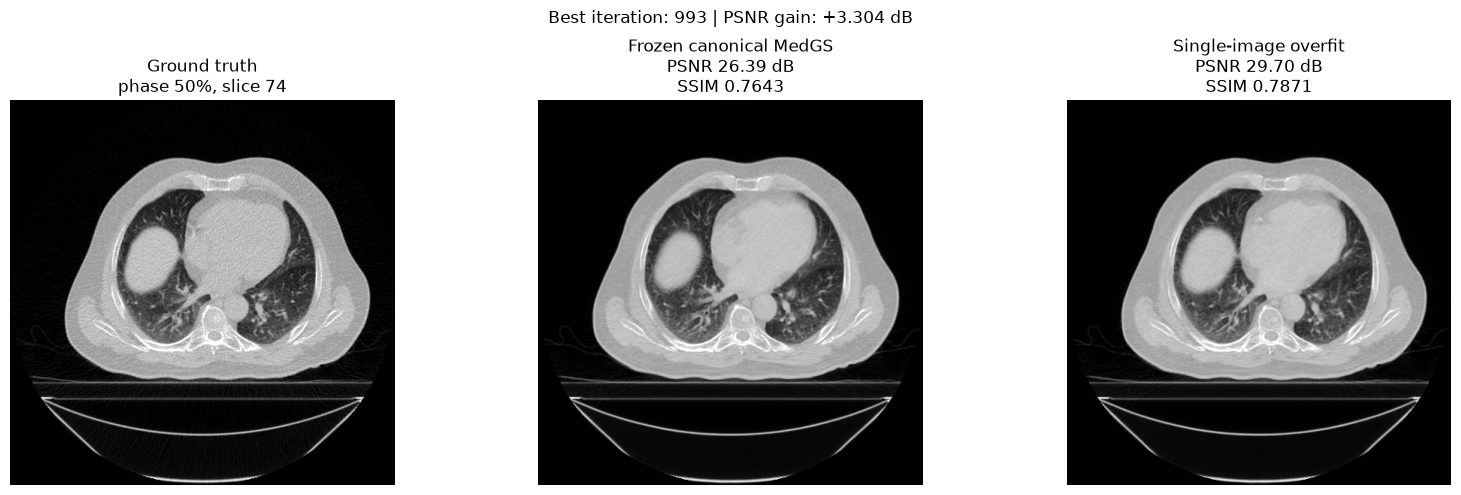

Single-pair overfit completed.
Target: phase 50%, slice 74
Best iteration: 993
Baseline PSNR / SSIM: 26.3931 / 0.764325
Overfit PSNR / SSIM: 29.6975 / 0.787091
PSNR gain: +3.3044 dB
SSIM gain: +0.022766
Mean |delta x|: 0.00082652
Mean |delta z|: 0.00133774
Mean / P95 |delta m| in slices: 0.6882 / 2.0906
Elapsed time: 3.00 minutes
Configuration saved to: /home/jovyan/shared/mtm_medgs_stack/results/phase_conditioned_medgs4d_overfit/patient_117_HM10395__phase_50__slice_074__iter1000/overfit_config.json
History saved to: /home/jovyan/shared/mtm_medgs_stack/results/phase_conditioned_medgs4d_overfit/patient_117_HM10395__phase_50__slice_074__iter1000/overfit_history.csv
Best checkpoint saved to: /home/jovyan/shared/mtm_medgs_stack/results/phase_conditioned_medgs4d_overfit/patient_117_HM10395__phase_50__slice_074__iter1000/overfit_best_checkpoint.pth
Comparison image saved to: /home/jovyan/shared/mtm_medgs_stack/results/phase_conditioned_medgs4d_overfit/patient_117_HM10395__phase_50__slice_074

In [70]:
# Overfit one phase/slice pair to test deformation capacity and optimization.
# Train a fresh local MLP on phase 50%, slice 74 without regularization.
#
# Saves configuration, history, best checkpoint, and comparison image.

import copy
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
from torch import nn
from torch.utils.checkpoint import checkpoint

from gaussian_renderer import render as medgs_render
from utils.loss_utils import l1_loss, ssim

warnings.filterwarnings(
    "ignore",
    message=(
        r".*torch\.cpu\.amp\.autocast"
        r".*deprecated.*"
    ),
    category=FutureWarning,
    module=r"torch\.utils\.checkpoint",
)

OVERFIT_PHASE_PERCENT = 50
OVERFIT_RESPIRATORY_TIME = 0.5

OVERFIT_CANONICAL_PHASE_PERCENT = 20
OVERFIT_CANONICAL_RESPIRATORY_TIME = 0.2

OVERFIT_SLICE_INDEX = 74
OVERFIT_ITERATIONS = 1000
OVERFIT_LEARNING_RATE = 5e-4

OVERFIT_PHASE_ENCODING_FREQUENCIES = 2
OVERFIT_MLP_HIDDEN_DIM = 128
OVERFIT_MLP_HIDDEN_LAYERS = 3
OVERFIT_MLP_CHUNK_SIZE = 131_072

OVERFIT_LOG_EVERY = 100
OVERFIT_SEED = 42

OVERFIT_HU_WINDOW_LOW = -1000.0
OVERFIT_HU_WINDOW_HIGH = 400.0

OVERFIT_RAW_VOLUME_PATH = Path(
    "/home/jovyan/shared/mtm_medgs_stack/results/"
    "prepared_4d_patients/117_HM10395/"
    "study_831212264180/volumes/raw/phase_50.npy"
)

OVERFIT_RUN_ROOT = Path(
    "/home/jovyan/shared/mtm_medgs_stack/results/"
    "phase_conditioned_medgs4d_overfit/"
    "patient_117_HM10395"
    "__phase_50"
    "__slice_074"
    "__iter1000"
)

OVERFIT_RUN_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

OVERFIT_CONFIG_PATH = (
        OVERFIT_RUN_ROOT
        / "overfit_config.json"
)

OVERFIT_HISTORY_PATH = (
        OVERFIT_RUN_ROOT
        / "overfit_history.csv"
)

OVERFIT_CHECKPOINT_PATH = (
        OVERFIT_RUN_ROOT
        / "overfit_best_checkpoint.pth"
)

OVERFIT_COMPARISON_PATH = (
        OVERFIT_RUN_ROOT
        / "overfit_comparison.png"
)

assert OVERFIT_RAW_VOLUME_PATH.is_file()

assert len(canonical_cameras) == 147

assert 0 <= OVERFIT_SLICE_INDEX < len(
    canonical_cameras
)

torch.manual_seed(
    OVERFIT_SEED
)

torch.cuda.manual_seed_all(
    OVERFIT_SEED
)

overfit_canonical_xyz = (
    canonical_gaussians
    .get_xyz
    .detach()
    .clone()
)

overfit_canonical_xz = (
    overfit_canonical_xyz[
        :,
        [0, -1],
    ]
)

overfit_canonical_m_logits = (
    canonical_gaussians
    .m
    .detach()
    .clone()
)

overfit_canonical_m = (
    canonical_gaussians
    .get_m
    .detach()
    .clone()
)

overfit_xz_mean = (
    overfit_canonical_xz.mean(
        dim=0,
        keepdim=True,
    )
)

overfit_xz_scale = (
    overfit_canonical_xz.std(
        dim=0,
        keepdim=True,
        unbiased=False,
    )
    .clamp_min(1e-6)
)

overfit_m_mean = (
    overfit_canonical_m.mean(
        dim=0,
        keepdim=True,
    )
)

overfit_m_scale = (
    overfit_canonical_m.std(
        dim=0,
        keepdim=True,
        unbiased=False,
    )
    .clamp_min(1e-6)
)

overfit_gaussian_inputs = torch.cat(
    [
        (
                overfit_canonical_xz
                - overfit_xz_mean
        )
        / overfit_xz_scale,
        (
                overfit_canonical_m
                - overfit_m_mean
        )
        / overfit_m_scale,
    ],
    dim=-1,
).detach()


def overfit_encode_phase(
        respiratory_time: float,
) -> torch.Tensor:
    """Encode one respiratory phase cyclically."""

    tau = torch.tensor(
        respiratory_time,
        device=overfit_canonical_xyz.device,
        dtype=overfit_canonical_xyz.dtype,
    )

    frequencies = (
            2.0
            ** torch.arange(
        OVERFIT_PHASE_ENCODING_FREQUENCIES,
        device=overfit_canonical_xyz.device,
        dtype=overfit_canonical_xyz.dtype,
    )
    )

    angles = (
            2.0
            * torch.pi
            * torch.remainder(
        tau,
        1.0,
    )
            * frequencies
    )

    return torch.stack(
        [
            torch.sin(angles),
            torch.cos(angles),
        ],
        dim=-1,
    ).flatten()


OVERFIT_MLP_INPUT_DIM = (
        overfit_gaussian_inputs.shape[1]
        + overfit_encode_phase(
    OVERFIT_RESPIRATORY_TIME
).numel()
)


class OverfitDeformationMLP(nn.Module):
    """Predict x, z, and m-logit residuals."""

    def __init__(self) -> None:
        super().__init__()

        layers = []
        current_dim = OVERFIT_MLP_INPUT_DIM

        for _ in range(
                OVERFIT_MLP_HIDDEN_LAYERS
        ):
            layers.extend(
                [
                    nn.Linear(
                        current_dim,
                        OVERFIT_MLP_HIDDEN_DIM,
                    ),
                    nn.SiLU(),
                ]
            )

            current_dim = (
                OVERFIT_MLP_HIDDEN_DIM
            )

        self.backbone = nn.Sequential(
            *layers
        )

        self.output_layer = nn.Linear(
            current_dim,
            3,
        )

        nn.init.zeros_(
            self.output_layer.weight
        )

        nn.init.zeros_(
            self.output_layer.bias
        )

    def forward(
            self,
            inputs: torch.Tensor,
    ) -> torch.Tensor:
        return self.output_layer(
            self.backbone(
                inputs
            )
        )


overfit_mlp = (
    OverfitDeformationMLP()
    .to(
        device=overfit_canonical_xyz.device,
        dtype=overfit_canonical_xyz.dtype,
    )
)


def overfit_build_mlp_inputs(
        gaussian_inputs: torch.Tensor,
        respiratory_time: float,
) -> torch.Tensor:
    """Append one phase encoding to Gaussian inputs."""

    phase_encoding = (
        overfit_encode_phase(
            respiratory_time
        )
    )

    phase_features = (
        phase_encoding
        .unsqueeze(0)
        .expand(
            gaussian_inputs.shape[0],
            -1,
        )
    )

    return torch.cat(
        [
            gaussian_inputs,
            phase_features,
        ],
        dim=-1,
    )


def overfit_predict_relative_deformation(
        respiratory_time: float,
        use_checkpointing: bool,
) -> torch.Tensor:
    """Predict deformation relative to phase 20%."""

    output_chunks = []

    for start in range(
            0,
            overfit_gaussian_inputs.shape[0],
            OVERFIT_MLP_CHUNK_SIZE,
    ):
        end = min(
            start
            + OVERFIT_MLP_CHUNK_SIZE,
            overfit_gaussian_inputs.shape[0],
        )

        spatial_chunk = (
            overfit_gaussian_inputs[
                start:end
            ]
        )

        selected_inputs = (
            overfit_build_mlp_inputs(
                spatial_chunk,
                respiratory_time,
            )
        )

        canonical_inputs = (
            overfit_build_mlp_inputs(
                spatial_chunk,
                OVERFIT_CANONICAL_RESPIRATORY_TIME,
            )
        )

        joint_inputs = torch.cat(
            [
                selected_inputs,
                canonical_inputs,
            ],
            dim=0,
        )

        if use_checkpointing:
            joint_outputs = checkpoint(
                overfit_mlp,
                joint_inputs,
                use_reentrant=False,
            )
        else:
            joint_outputs = overfit_mlp(
                joint_inputs
            )

        chunk_count = (
            spatial_chunk.shape[0]
        )

        output_chunks.append(
            joint_outputs[
                :chunk_count
            ]
            - joint_outputs[
                chunk_count:
            ]
        )

    return torch.cat(
        output_chunks,
        dim=0,
    )


class OverfitGaussianView:
    """Override dynamic xyz and m while forwarding fixed parameters."""

    def __init__(
            self,
            dynamic_xyz: torch.Tensor,
            dynamic_m: torch.Tensor,
    ) -> None:
        self._dynamic_xyz = dynamic_xyz
        self._dynamic_m = dynamic_m

    @property
    def get_xyz(self) -> torch.Tensor:
        return self._dynamic_xyz

    @property
    def get_m(self) -> torch.Tensor:
        return self._dynamic_m

    def __getattr__(
            self,
            name: str,
    ):
        return getattr(
            canonical_gaussians,
            name,
        )


def overfit_build_gaussian_view(
        use_checkpointing: bool,
) -> tuple[
    OverfitGaussianView,
    dict[str, torch.Tensor],
]:
    """Build the deformed Gaussian representation."""

    deformation = (
        overfit_predict_relative_deformation(
            respiratory_time=(
                OVERFIT_RESPIRATORY_TIME
            ),
            use_checkpointing=(
                use_checkpointing
            ),
        )
    )

    delta_xz = deformation[:, :2]
    delta_m_logit = deformation[:, 2:3]

    dynamic_xz = (
            overfit_canonical_xz
            + delta_xz
    )

    dynamic_m = torch.sigmoid(
        overfit_canonical_m_logits
        + delta_m_logit
    )

    dynamic_xyz = torch.stack(
        [
            dynamic_xz[:, 0],
            overfit_canonical_xyz[:, 1],
            dynamic_xz[:, 1],
        ],
        dim=-1,
    )

    state = {
        "delta_xz": delta_xz,
        "delta_m_logit": (
            delta_m_logit
        ),
        "delta_m": (
                dynamic_m
                - overfit_canonical_m
        ),
        "dynamic_xyz": dynamic_xyz,
        "dynamic_m": dynamic_m,
    }

    return (
        OverfitGaussianView(
            dynamic_xyz=dynamic_xyz,
            dynamic_m=dynamic_m,
        ),
        state,
    )


def overfit_preprocess_ct_slice(
        raw_slice: np.ndarray,
) -> np.ndarray:
    """Apply the verified CT window and uint8 rounding."""

    normalized = np.clip(
        (
                raw_slice.astype(
                    np.float32
                )
                - OVERFIT_HU_WINDOW_LOW
        )
        / (
                OVERFIT_HU_WINDOW_HIGH
                - OVERFIT_HU_WINDOW_LOW
        ),
        0.0,
        1.0,
    )

    return (
            np.rint(
                normalized * 255.0
            )
            .clip(
                0.0,
                255.0,
            )
            .astype(
                np.uint8
            )
            .astype(
                np.float32
            )
            / 255.0
    )


overfit_raw_volume = np.load(
    OVERFIT_RAW_VOLUME_PATH,
    mmap_mode="r",
)

overfit_raw_slice = np.array(
    overfit_raw_volume[
        OVERFIT_SLICE_INDEX
    ],
    dtype=np.float32,
    copy=True,
)

overfit_target_array = (
    overfit_preprocess_ct_slice(
        overfit_raw_slice
    )
)

overfit_target = (
    torch.from_numpy(
        np.ascontiguousarray(
            overfit_target_array
        )
    )
    .to(
        device=overfit_canonical_xyz.device,
        dtype=overfit_canonical_xyz.dtype,
    )
    .unsqueeze(0)
    .repeat(
        3,
        1,
        1,
    )
)

overfit_camera = canonical_cameras[
    OVERFIT_SLICE_INDEX
]


def overfit_metrics(
        rendered_image: torch.Tensor,
) -> dict[str, float]:
    """Calculate metrics against the fixed target."""

    difference = (
            rendered_image
            - overfit_target
    )

    l1_value = (
        difference.abs().mean()
    )

    mse_value = (
        difference.square().mean()
    )

    psnr_value = (
            -10.0
            * torch.log10(
        mse_value.clamp_min(
            1e-12
        )
    )
    )

    ssim_value = ssim(
        rendered_image.unsqueeze(0),
        overfit_target.unsqueeze(0),
    )

    return {
        "L1": float(
            l1_value.item()
        ),
        "PSNR": float(
            psnr_value.item()
        ),
        "SSIM": float(
            ssim_value.item()
        ),
    }


with torch.no_grad():
    overfit_baseline_result = (
        medgs_render(
            overfit_camera,
            canonical_gaussians,
            canonical_pipeline,
            canonical_background,
        )
    )

    overfit_baseline_image = (
        overfit_baseline_result[
            "render"
        ]
        .detach()
        .clone()
    )

overfit_baseline_metrics = (
    overfit_metrics(
        overfit_baseline_image
    )
)

overfit_optimizer = torch.optim.Adam(
    overfit_mlp.parameters(),
    lr=OVERFIT_LEARNING_RATE,
)

overfit_config = {
    "phase_percent": (
        OVERFIT_PHASE_PERCENT
    ),
    "canonical_phase_percent": (
        OVERFIT_CANONICAL_PHASE_PERCENT
    ),
    "slice_index": (
        OVERFIT_SLICE_INDEX
    ),
    "iterations": (
        OVERFIT_ITERATIONS
    ),
    "learning_rate": (
        OVERFIT_LEARNING_RATE
    ),
    "hidden_dim": (
        OVERFIT_MLP_HIDDEN_DIM
    ),
    "hidden_layers": (
        OVERFIT_MLP_HIDDEN_LAYERS
    ),
    "phase_encoding_frequencies": (
        OVERFIT_PHASE_ENCODING_FREQUENCIES
    ),
    "loss": (
        "2.0 * L1 + 0.25 * (1 - SSIM)"
    ),
    "regularization": None,
    "raw_volume_path": str(
        OVERFIT_RAW_VOLUME_PATH
    ),
    "output_directory": str(
        OVERFIT_RUN_ROOT
    ),
}

OVERFIT_CONFIG_PATH.write_text(
    json.dumps(
        overfit_config,
        indent=2,
    ),
    encoding="utf-8",
)

overfit_history_rows = []

overfit_best_loss = float("inf")
overfit_best_iteration = 0
overfit_best_state_dict = None

overfit_mlp.train()

torch.cuda.reset_peak_memory_stats()

overfit_start_time = (
    time.perf_counter()
)

for iteration in range(
        1,
        OVERFIT_ITERATIONS + 1,
):
    overfit_optimizer.zero_grad(
        set_to_none=True
    )

    gaussian_view, deformation_state = (
        overfit_build_gaussian_view(
            use_checkpointing=True
        )
    )

    render_result = medgs_render(
        overfit_camera,
        gaussian_view,
        canonical_pipeline,
        canonical_background,
        train=True,
        iter=iteration,
    )

    rendered_image = (
        render_result["render"]
    )

    l1_value = l1_loss(
        rendered_image.unsqueeze(0),
        overfit_target.unsqueeze(0),
    )

    ssim_value = ssim(
        rendered_image.unsqueeze(0),
        overfit_target.unsqueeze(0),
    )

    total_loss = (
            2.0 * l1_value
            + 0.25
            * (
                    1.0 - ssim_value
            )
    )

    current_loss = float(
        total_loss.detach().item()
    )

    if current_loss < overfit_best_loss:
        overfit_best_loss = current_loss
        overfit_best_iteration = iteration

        overfit_best_state_dict = (
            copy.deepcopy(
                overfit_mlp.state_dict()
            )
        )

    total_loss.backward()

    gradient_norm = float(
        torch.nn.utils.clip_grad_norm_(
            overfit_mlp.parameters(),
            max_norm=10.0,
        ).item()
    )

    overfit_optimizer.step()

    current_metrics = overfit_metrics(
        rendered_image.detach()
    )

    elapsed_seconds = (
            time.perf_counter()
            - overfit_start_time
    )

    overfit_history_rows.append(
        {
            "Iteration": iteration,
            "TotalLoss": current_loss,
            "L1": current_metrics["L1"],
            "PSNR": current_metrics["PSNR"],
            "SSIM": current_metrics["SSIM"],
            "GradientNorm": gradient_norm,
            "ElapsedSeconds": (
                elapsed_seconds
            ),
            "PeakGpuMemoryGB": (
                    torch.cuda
                    .max_memory_allocated()
                    / 1024 ** 3
            ),
        }
    )

    if (
            iteration % OVERFIT_LOG_EVERY
            == 0
            or iteration == 1
    ):
        print(
            f"Iteration "
            f"{iteration:04d}/"
            f"{OVERFIT_ITERATIONS:04d} | "
            f"loss={current_loss:.6f} | "
            f"PSNR="
            f"{current_metrics['PSNR']:.3f} | "
            f"SSIM="
            f"{current_metrics['SSIM']:.5f} | "
            f"grad={gradient_norm:.3e}"
        )

        pd.DataFrame(
            overfit_history_rows
        ).to_csv(
            OVERFIT_HISTORY_PATH,
            index=False,
        )

    del gaussian_view
    del deformation_state
    del render_result
    del rendered_image
    del total_loss
    del l1_value
    del ssim_value

pd.DataFrame(
    overfit_history_rows
).to_csv(
    OVERFIT_HISTORY_PATH,
    index=False,
)

overfit_mlp.load_state_dict(
    overfit_best_state_dict
)

overfit_mlp.eval()

torch.save(
    {
        "iteration": (
            overfit_best_iteration
        ),
        "model_state_dict": (
            overfit_mlp.state_dict()
        ),
        "optimizer_state_dict": (
            overfit_optimizer.state_dict()
        ),
        "config": overfit_config,
        "best_loss": overfit_best_loss,
    },
    OVERFIT_CHECKPOINT_PATH,
)

with torch.no_grad():
    best_gaussian_view, best_state = (
        overfit_build_gaussian_view(
            use_checkpointing=False
        )
    )

    best_render_result = medgs_render(
        overfit_camera,
        best_gaussian_view,
        canonical_pipeline,
        canonical_background,
    )

    overfit_best_image = (
        best_render_result[
            "render"
        ]
        .detach()
        .clone()
    )

overfit_best_metrics = (
    overfit_metrics(
        overfit_best_image
    )
)

delta_m_slices = (
        best_state["delta_m"]
        * len(canonical_cameras)
)

mean_abs_delta_x = float(
    best_state[
        "delta_xz"
    ][:, 0]
    .abs()
    .mean()
    .item()
)

mean_abs_delta_z = float(
    best_state[
        "delta_xz"
    ][:, 1]
    .abs()
    .mean()
    .item()
)

mean_abs_delta_m_slices = float(
    delta_m_slices
    .abs()
    .mean()
    .item()
)

p95_abs_delta_m_slices = float(
    torch.quantile(
        delta_m_slices
        .abs()
        .flatten(),
        0.95,
    ).item()
)

figure, axes = plt.subplots(
    1,
    3,
    figsize=(16, 5),
)

axes[0].imshow(
    overfit_target[0]
    .detach()
    .cpu()
    .numpy(),
    cmap="gray",
    vmin=0.0,
    vmax=1.0,
)

axes[0].set_title(
    "Ground truth\n"
    "phase 50%, slice 74"
)

axes[1].imshow(
    overfit_baseline_image[0]
    .detach()
    .cpu()
    .numpy(),
    cmap="gray",
    vmin=0.0,
    vmax=1.0,
)

axes[1].set_title(
    "Frozen canonical MedGS\n"
    f"PSNR "
    f"{overfit_baseline_metrics['PSNR']:.2f} dB\n"
    f"SSIM "
    f"{overfit_baseline_metrics['SSIM']:.4f}"
)

axes[2].imshow(
    overfit_best_image[0]
    .detach()
    .cpu()
    .numpy(),
    cmap="gray",
    vmin=0.0,
    vmax=1.0,
)

axes[2].set_title(
    "Single-image overfit\n"
    f"PSNR "
    f"{overfit_best_metrics['PSNR']:.2f} dB\n"
    f"SSIM "
    f"{overfit_best_metrics['SSIM']:.4f}"
)

for axis in axes:
    axis.axis("off")

figure.suptitle(
    f"Best iteration: "
    f"{overfit_best_iteration} | "
    f"PSNR gain: "
    f"{overfit_best_metrics['PSNR'] - overfit_baseline_metrics['PSNR']:+.3f} dB"
)

figure.tight_layout()

figure.savefig(
    OVERFIT_COMPARISON_PATH,
    dpi=180,
    bbox_inches="tight",
)

plt.show()

overfit_elapsed_minutes = (
                                  time.perf_counter()
                                  - overfit_start_time
                          ) / 60.0

print("Single-pair overfit completed.")

print(
    f"Target: phase "
    f"{OVERFIT_PHASE_PERCENT}%, "
    f"slice {OVERFIT_SLICE_INDEX}"
)

print(
    f"Best iteration: "
    f"{overfit_best_iteration}"
)

print(
    "Baseline PSNR / SSIM: "
    f"{overfit_baseline_metrics['PSNR']:.4f} / "
    f"{overfit_baseline_metrics['SSIM']:.6f}"
)

print(
    "Overfit PSNR / SSIM: "
    f"{overfit_best_metrics['PSNR']:.4f} / "
    f"{overfit_best_metrics['SSIM']:.6f}"
)

print(
    f"PSNR gain: "
    f"{overfit_best_metrics['PSNR'] - overfit_baseline_metrics['PSNR']:+.4f} dB"
)

print(
    f"SSIM gain: "
    f"{overfit_best_metrics['SSIM'] - overfit_baseline_metrics['SSIM']:+.6f}"
)

print(
    f"Mean |delta x|: "
    f"{mean_abs_delta_x:.8f}"
)

print(
    f"Mean |delta z|: "
    f"{mean_abs_delta_z:.8f}"
)

print(
    "Mean / P95 |delta m| in slices: "
    f"{mean_abs_delta_m_slices:.4f} / "
    f"{p95_abs_delta_m_slices:.4f}"
)

print(
    f"Elapsed time: "
    f"{overfit_elapsed_minutes:.2f} minutes"
)

print(
    f"Configuration saved to: "
    f"{OVERFIT_CONFIG_PATH}"
)

print(
    f"History saved to: "
    f"{OVERFIT_HISTORY_PATH}"
)

print(
    f"Best checkpoint saved to: "
    f"{OVERFIT_CHECKPOINT_PATH}"
)

print(
    f"Comparison image saved to: "
    f"{OVERFIT_COMPARISON_PATH}"
)

torch.cuda.empty_cache()

## Smoke test / pilot

In [43]:
# Configure the phase-conditioned MedGS4D experiment.
#
# This cell selects the raw MedGS model trained on respiratory phase 20%
# as the frozen canonical representation. It defines the respiratory phases,
# deformation-network architecture, optimization parameters, regularization
# weights, training length, checkpoint frequency, and output directories.
#
# Short and full training runs use separate output paths, so they cannot
# overwrite the canonical model or each other.

DYNAMIC_CANONICAL_PHASE_PERCENT = 20.0
DYNAMIC_PHASE_PERCENTS = tuple(
    float(phase)
    for phase in range(0, 100, 10)
)

CANONICAL_MODEL_ITERATION = 30_000

# Current short run.
# DYNAMIC_RUN_LABEL = "smoke"
DYNAMIC_RUN_LABEL = "pilot"
DYNAMIC_ITERATIONS = 5000
DYNAMIC_BATCH_SIZE = 1

# Overnight run:
# DYNAMIC_RUN_LABEL = "full"
# DYNAMIC_ITERATIONS = 30_000
# DYNAMIC_BATCH_SIZE = 3

DYNAMIC_PHASE_ENCODING_FREQUENCIES = 2

DYNAMIC_MLP_HIDDEN_DIM = 128
DYNAMIC_MLP_HIDDEN_LAYERS = 3

DYNAMIC_LEARNING_RATE = 1e-4

DYNAMIC_DEFORMATION_MAGNITUDE_WEIGHT = 1e-4
DYNAMIC_TEMPORAL_SMOOTHNESS_WEIGHT = 1e-3

DYNAMIC_LOG_EVERY = 25
DYNAMIC_CHECKPOINT_EVERY = 250

DYNAMIC_SEED = 42

RUN_DYNAMIC_TRAINING = True
REUSE_COMPLETED_DYNAMIC_MODEL = True

study_tag = str(STUDY_INSTANCE_UID)[-12:]
dynamic_canonical_phase_tag = phase_tag(
    DYNAMIC_CANONICAL_PHASE_PERCENT
)

canonical_raw_run_root = (
        RESULTS_ROOT
        / "canonical_medgs"
        / (
            f"patient_{PATIENT_ID}"
            f"__study_{study_tag}"
            f"__phase_{dynamic_canonical_phase_tag}"
            f"__raw"
            f"__poly{POLY_DEGREE}"
            f"__iter{CANONICAL_MODEL_ITERATION}"
        )
)

canonical_model_root = (
        canonical_raw_run_root
        / "model"
)

canonical_checkpoint_path = (
        canonical_model_root
        / f"chkpnt{CANONICAL_MODEL_ITERATION}.pth"
)

canonical_frame_manifest_path = (
        canonical_raw_run_root
        / "frame_manifest.csv"
)

assert canonical_checkpoint_path.is_file()
assert canonical_frame_manifest_path.is_file()

DYNAMIC_RESULTS_ROOT = (
        RESULTS_ROOT
        / "phase_conditioned_medgs4d"
)

dynamic_run_name = (
    f"patient_{PATIENT_ID}"
    f"__study_{study_tag}"
    f"__canonical_phase_{dynamic_canonical_phase_tag}_raw"
    f"__all_phases"
    f"__deform_xz_m"
    f"__{DYNAMIC_RUN_LABEL}"
    f"__iter{DYNAMIC_ITERATIONS}"
)

dynamic_run_root = (
        DYNAMIC_RESULTS_ROOT
        / dynamic_run_name
)

dynamic_checkpoint_root = (
        dynamic_run_root
        / "checkpoints"
)

dynamic_render_root = (
        dynamic_run_root
        / "renders"
)

dynamic_training_log_path = (
        dynamic_run_root
        / "training_log.csv"
)

dynamic_config_path = (
        dynamic_run_root
        / "run.json"
)

dynamic_run_root.mkdir(
    parents=True,
    exist_ok=True,
)

dynamic_checkpoint_root.mkdir(
    parents=True,
    exist_ok=True,
)

print("Phase-conditioned MedGS4D configuration")
print(f"Canonical checkpoint: {canonical_checkpoint_path}")
print(f"Training phases: {DYNAMIC_PHASE_PERCENTS}")
print(f"Dynamic iterations: {DYNAMIC_ITERATIONS}")
print(f"Batch size: {DYNAMIC_BATCH_SIZE}")
print(f"Dynamic run: {dynamic_run_root}")

Phase-conditioned MedGS4D configuration
Canonical checkpoint: /home/jovyan/shared/mtm_medgs_stack/results/canonical_medgs/patient_117_HM10395__study_831212264180__phase_20__raw__poly2__iter30000/model/chkpnt30000.pth
Training phases: (0.0, 10.0, 20.0, 30.0, 40.0, 50.0, 60.0, 70.0, 80.0, 90.0)
Dynamic iterations: 500
Batch size: 1
Dynamic run: /home/jovyan/shared/mtm_medgs_stack/results/phase_conditioned_medgs4d/patient_117_HM10395__study_831212264180__canonical_phase_20_raw__all_phases__deform_xz_m__smoke__iter500


In [44]:
# Build a common phase-by-slice index for dynamic MedGS4D training.
#
# Each row identifies one raw CT target using two independent variables:
# respiratory phase and axial slice position. The respiratory phase controls
# Gaussian deformation, while the slice index is mapped to the corresponding
# camera from the canonical MedGS model.
#
# The cell verifies that all ten phases contain the same number of slices,
# use compatible slice coordinates, and have their raw volume files available.
# The resulting index and phase summary are saved with the dynamic experiment.

prepared_study_root = (
        PREPARED_4D_ROOT
        / PATIENT_ID
        / f"study_{study_tag}"
)

prepared_phase_manifest_path = (
        prepared_study_root
        / "phase_slice_manifest.csv"
)

prepared_phase_manifest_df = pd.read_csv(
    prepared_phase_manifest_path
)

canonical_frame_manifest_df = pd.read_csv(
    canonical_frame_manifest_path
)

dynamic_phase_index_df = (
    prepared_phase_manifest_df.loc[
        prepared_phase_manifest_df[
            "PhasePercent"
        ].astype(float).isin(
            DYNAMIC_PHASE_PERCENTS
        ),
        [
            "PhasePercent",
            "SliceIndex",
            "SliceCoordinate",
        ],
    ]
    .copy()
)

dynamic_phase_index_df["PhasePercent"] = (
    dynamic_phase_index_df[
        "PhasePercent"
    ].astype(float)
)

dynamic_phase_index_df["SliceIndex"] = (
    dynamic_phase_index_df[
        "SliceIndex"
    ].astype(int)
)

dynamic_phase_index_df["SliceCoordinate"] = (
    dynamic_phase_index_df[
        "SliceCoordinate"
    ].astype(float)
)

dynamic_phase_index_df["RespiratoryTime"] = (
        dynamic_phase_index_df["PhasePercent"]
        / 100.0
)

phase_index_by_percent = {
    phase_percent: phase_index
    for phase_index, phase_percent in enumerate(
        DYNAMIC_PHASE_PERCENTS
    )
}

dynamic_phase_index_df["PhaseIndex"] = (
    dynamic_phase_index_df[
        "PhasePercent"
    ].map(phase_index_by_percent)
)

canonical_camera_df = (
    canonical_frame_manifest_df[
        [
            "FrameIndex",
            "SliceIndex",
            "SliceCoordinate",
        ]
    ]
    .rename(
        columns={
            "FrameIndex": "CameraIndex",
            "SliceCoordinate": (
                "CanonicalSliceCoordinate"
            ),
        }
    )
)

canonical_camera_df["SliceIndex"] = (
    canonical_camera_df[
        "SliceIndex"
    ].astype(int)
)

dynamic_phase_index_df = (
    dynamic_phase_index_df.merge(
        canonical_camera_df,
        on="SliceIndex",
        how="left",
        validate="many_to_one",
    )
)

dynamic_phase_index_df["RawVolumePath"] = (
    dynamic_phase_index_df[
        "PhasePercent"
    ].map(
        lambda phase_percent: str(
            prepared_study_root
            / "volumes"
            / "raw"
            / (
                f"phase_"
                f"{phase_tag(phase_percent)}"
                f".npy"
            )
        )
    )
)

dynamic_phase_index_df["Split"] = "train"

dynamic_phase_index_df = (
    dynamic_phase_index_df.sort_values(
        [
            "PhasePercent",
            "SliceIndex",
        ]
    )
    .reset_index(drop=True)
)

phase_counts = (
    dynamic_phase_index_df.groupby(
        "PhasePercent"
    )
    .size()
)

expected_slices = len(
    canonical_frame_manifest_df
)

assert tuple(phase_counts.index) == (
    DYNAMIC_PHASE_PERCENTS
)

assert phase_counts.eq(
    expected_slices
).all()

assert dynamic_phase_index_df[
    "CameraIndex"
].notna().all()

assert np.allclose(
    dynamic_phase_index_df[
        "SliceCoordinate"
    ],
    dynamic_phase_index_df[
        "CanonicalSliceCoordinate"
    ],
    atol=1e-3,
)

assert dynamic_phase_index_df[
    "RawVolumePath"
].map(
    lambda path: Path(path).is_file()
).all()

for phase_percent in DYNAMIC_PHASE_PERCENTS:
    phase_rows = (
        dynamic_phase_index_df.loc[
            dynamic_phase_index_df[
                "PhasePercent"
            ]
            == phase_percent
            ]
        .sort_values("SliceIndex")
    )

    phase_volume = np.load(
        phase_rows[
            "RawVolumePath"
        ].iloc[0],
        mmap_mode="r",
    )

    assert phase_volume.shape[0] == expected_slices

dynamic_phase_summary_df = (
    dynamic_phase_index_df.groupby(
        [
            "PhaseIndex",
            "PhasePercent",
            "RespiratoryTime",
            "Split",
        ],
        as_index=False,
        sort=True,
    )
    .agg(
        Slices=("SliceIndex", "count"),
        FirstSliceCoordinate=(
            "SliceCoordinate",
            "min",
        ),
        LastSliceCoordinate=(
            "SliceCoordinate",
            "max",
        ),
        RawVolumePath=(
            "RawVolumePath",
            "first",
        ),
    )
)

dynamic_phase_index_path = (
        dynamic_run_root
        / "phase_slice_index.csv"
)

dynamic_phase_summary_path = (
        dynamic_run_root
        / "phase_summary.csv"
)

dynamic_phase_index_df.to_csv(
    dynamic_phase_index_path,
    index=False,
)

dynamic_phase_summary_df.to_csv(
    dynamic_phase_summary_path,
    index=False,
)

print(
    f"Dynamic index created: "
    f"{len(dynamic_phase_index_df)} rows, "
    f"{len(DYNAMIC_PHASE_PERCENTS)} phases, "
    f"{expected_slices} slices per phase."
)

print(
    f"Index saved to: "
    f"{dynamic_phase_index_path}"
)

display(dynamic_phase_summary_df)
display(dynamic_phase_index_df.head())

Dynamic index created: 1470 rows, 10 phases, 147 slices per phase.
Index saved to: /home/jovyan/shared/mtm_medgs_stack/results/phase_conditioned_medgs4d/patient_117_HM10395__study_831212264180__canonical_phase_20_raw__all_phases__deform_xz_m__smoke__iter500/phase_slice_index.csv


,PhaseIndex,PhasePercent,RespiratoryTime,Split,Slices,FirstSliceCoordinate,LastSliceCoordinate,RawVolumePath
0,0,0.0,0.0,train,147,-266.2,171.8,/home/jovyan/shared/mtm_medgs_stack/results/prepared_4d_patients/117_HM10395/study_831212264180/volumes/raw/phase_0.npy
1,1,10.0,0.1,train,147,-266.2,171.8,/home/jovyan/shared/mtm_medgs_stack/results/prepared_4d_patients/117_HM10395/study_831212264180/volumes/raw/phase_10...
2,2,20.0,0.2,train,147,-266.2,171.8,/home/jovyan/shared/mtm_medgs_stack/results/prepared_4d_patients/117_HM10395/study_831212264180/volumes/raw/phase_20...
3,3,30.0,0.3,train,147,-266.2,171.8,/home/jovyan/shared/mtm_medgs_stack/results/prepared_4d_patients/117_HM10395/study_831212264180/volumes/raw/phase_30...
4,4,40.0,0.4,train,147,-266.2,171.8,/home/jovyan/shared/mtm_medgs_stack/results/prepared_4d_patients/117_HM10395/study_831212264180/volumes/raw/phase_40...
5,5,50.0,0.5,train,147,-266.2,171.8,/home/jovyan/shared/mtm_medgs_stack/results/prepared_4d_patients/117_HM10395/study_831212264180/volumes/raw/phase_50...
6,6,60.0,0.6,train,147,-266.2,171.8,/home/jovyan/shared/mtm_medgs_stack/results/prepared_4d_patients/117_HM10395/study_831212264180/volumes/raw/phase_60...
7,7,70.0,0.7,train,147,-266.2,171.8,/home/jovyan/shared/mtm_medgs_stack/results/prepared_4d_patients/117_HM10395/study_831212264180/volumes/raw/phase_70...
8,8,80.0,0.8,train,147,-266.2,171.8,/home/jovyan/shared/mtm_medgs_stack/results/prepared_4d_patients/117_HM10395/study_831212264180/volumes/raw/phase_80...
9,9,90.0,0.9,train,147,-266.2,171.8,/home/jovyan/shared/mtm_medgs_stack/results/prepared_4d_patients/117_HM10395/study_831212264180/volumes/raw/phase_90...


,PhasePercent,SliceIndex,SliceCoordinate,RespiratoryTime,PhaseIndex,CameraIndex,CanonicalSliceCoordinate,RawVolumePath,Split
0,0.0,0,-266.2,0.0,0,0,-266.2,/home/jovyan/shared/mtm_medgs_stack/results/prepared_4d_patients/117_HM10395/study_831212264180/volumes/raw/phase_0.npy,train
1,0.0,1,-263.2,0.0,0,1,-263.2,/home/jovyan/shared/mtm_medgs_stack/results/prepared_4d_patients/117_HM10395/study_831212264180/volumes/raw/phase_0.npy,train
2,0.0,2,-260.2,0.0,0,2,-260.2,/home/jovyan/shared/mtm_medgs_stack/results/prepared_4d_patients/117_HM10395/study_831212264180/volumes/raw/phase_0.npy,train
3,0.0,3,-257.2,0.0,0,3,-257.2,/home/jovyan/shared/mtm_medgs_stack/results/prepared_4d_patients/117_HM10395/study_831212264180/volumes/raw/phase_0.npy,train
4,0.0,4,-254.2,0.0,0,4,-254.2,/home/jovyan/shared/mtm_medgs_stack/results/prepared_4d_patients/117_HM10395/study_831212264180/volumes/raw/phase_0.npy,train


In [45]:
# Load and freeze the raw phase-20 canonical MedGS model.
# Keep immutable xyz and slice-axis centers as the reference geometry
# for phase-dependent residual deformation.
#
# Reads the canonical checkpoint and camera configuration.
# Keeps the restored model in memory and writes no new files.


from argparse import Namespace

if str(MEDGS_REPOSITORY) not in sys.path:
    sys.path.insert(
        0,
        str(MEDGS_REPOSITORY),
    )

from models import gaussianModel
from scene import Scene

canonical_cfg_path = (
        canonical_model_root
        / "cfg_args"
)

canonical_cfg_text = canonical_cfg_path.read_text(
    encoding="utf-8"
)

canonical_dataset_args = eval(
    canonical_cfg_text,
    {
        "Namespace": Namespace,
        "__builtins__": {},
    },
)

canonical_dataset_root = (
        canonical_raw_run_root
        / "dataset"
)

canonical_dataset_args.source_path = str(
    canonical_dataset_root
)

canonical_dataset_args.model_path = str(
    canonical_model_root
)

canonical_dataset_args.gs_type = "gs"
canonical_dataset_args.camera = CAMERA
canonical_dataset_args.poly_degree = POLY_DEGREE
canonical_dataset_args.data_device = "cuda"

canonical_frame_count = len(
    list(
        (
                canonical_dataset_root
                / "original"
        ).glob("*.png")
    )
)

assert canonical_frame_count == len(
    canonical_frame_manifest_df
)

(
    canonical_model_state,
    canonical_loaded_iteration,
) = torch.load(
    canonical_checkpoint_path,
    map_location="cuda",
)

assert int(canonical_loaded_iteration) == (
    CANONICAL_MODEL_ITERATION
)

canonical_gaussians = gaussianModel["gs"](
    canonical_dataset_args.sh_degree,
    canonical_dataset_args.poly_degree,
    canonical_frame_count,
    use_dff=False,
)

canonical_scene = Scene(
    canonical_dataset_args,
    canonical_gaussians,
    load_iteration=canonical_loaded_iteration,
    shuffle=False,
)

canonical_gaussians.restore(
    canonical_model_state,
    training_args=None,
    load_optimizer=False,
)

canonical_cameras = (
    canonical_scene.getTestCameras()
)

assert len(canonical_cameras) == (
    canonical_frame_count
)

canonical_parameter_names = (
    "_xyz",
    "_features_dc",
    "_features_rest",
    "_scaling",
    "_rotation",
    "_opacity",
    "m",
    "sigma",
    "_w1",
    "time_func",
)

for parameter_name in canonical_parameter_names:
    parameter = getattr(
        canonical_gaussians,
        parameter_name,
    )

    if isinstance(parameter, torch.Tensor):
        parameter.requires_grad_(False)

canonical_gaussians.optimizer = None

canonical_xyz = (
    canonical_gaussians
    .get_xyz
    .detach()
    .clone()
)

canonical_m_logits = (
    canonical_gaussians
    .m
    .detach()
    .clone()
)

canonical_m = (
    canonical_gaussians
    .get_m
    .detach()
    .clone()
)

canonical_pipeline = Namespace(
    convert_SHs_python=getattr(
        canonical_dataset_args,
        "convert_SHs_python",
        False,
    ),
    compute_cov3D_python=getattr(
        canonical_dataset_args,
        "compute_cov3D_python",
        False,
    ),
    debug=False,
    antialiasing=getattr(
        canonical_dataset_args,
        "antialiasing",
        False,
    ),
)

canonical_background = torch.tensor(
    (
        [1.0, 1.0, 1.0]
        if canonical_dataset_args.white_background
        else [0.0, 0.0, 0.0]
    ),
    dtype=torch.float32,
    device="cuda",
)

canonical_trainable_tensors = [
    parameter_name
    for parameter_name in canonical_parameter_names
    if (
            isinstance(
                getattr(
                    canonical_gaussians,
                    parameter_name,
                ),
                torch.Tensor,
            )
            and getattr(
        canonical_gaussians,
        parameter_name,
    ).requires_grad
    )
]

assert not canonical_trainable_tensors
assert canonical_xyz.shape[0] == (
    canonical_m.shape[0]
)

print("Canonical raw MedGS model loaded and frozen.")
print(
    f"Checkpoint iteration: "
    f"{canonical_loaded_iteration}"
)
print(
    f"Canonical Gaussians: "
    f"{canonical_xyz.shape[0]:,}"
)
print(
    f"Canonical cameras: "
    f"{len(canonical_cameras)}"
)
print(
    f"xyz shape: "
    f"{tuple(canonical_xyz.shape)}"
)
print(
    f"m shape: "
    f"{tuple(canonical_m.shape)}"
)
print(
    f"Polynomial weights shape: "
    f"{tuple(canonical_gaussians._w1.shape)}"
)
print(
    "Trainable canonical tensors: "
    f"{canonical_trainable_tensors}"
)

/tmp/ipykernel_7670/2883460704.py:71: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ) = torch.load(


Distance: 1.0
Loading trained model at iteration 30000
Creating Training Transforms
Creating Test Transforms
AAAAA radius 1.1
AAAAA translate [-0. -0. -0.] center [0. 0. 0.]
Generating random point cloud (100000)...
Loading Training Cameras
Loading Test Cameras
Canonical raw MedGS model loaded and frozen.
Checkpoint iteration: 30000
Canonical Gaussians: 1,410,016
Canonical cameras: 147
xyz shape: (1410016, 3)
m shape: (1410016, 1)
Polynomial weights shape: (1410016, 4)
Trainable canonical tensors: []


In [47]:
# Normalize the canonical x, z, and activated m coordinates used by MedGS.
# Encode the respiratory phase with cyclic sine/cosine features.
#
# Writes deformation_input_normalization.json with the input statistics.

canonical_xz = (
    canonical_xyz[:, [0, -1]]
    .detach()
    .clone()
)

canonical_xz_mean = canonical_xz.mean(
    dim=0,
    keepdim=True,
)

canonical_xz_scale = canonical_xz.std(
    dim=0,
    keepdim=True,
    unbiased=False,
).clamp_min(1e-6)

canonical_m_mean = canonical_m.mean(
    dim=0,
    keepdim=True,
)

canonical_m_scale = canonical_m.std(
    dim=0,
    keepdim=True,
    unbiased=False,
).clamp_min(1e-6)

canonical_xz_normalized = (
                                  canonical_xz - canonical_xz_mean
                          ) / canonical_xz_scale

canonical_m_normalized = (
                                 canonical_m - canonical_m_mean
                         ) / canonical_m_scale

canonical_deformation_inputs = torch.cat(
    [
        canonical_xz_normalized,
        canonical_m_normalized,
    ],
    dim=-1,
).detach()


def encode_respiratory_phase(
        respiratory_time: float | torch.Tensor,
) -> torch.Tensor:
    """Encode normalized respiratory phase with cyclic features."""

    tau = torch.as_tensor(
        respiratory_time,
        dtype=canonical_xyz.dtype,
        device=canonical_xyz.device,
    )

    tau = torch.remainder(
        tau,
        1.0,
    )

    frequencies = 2.0 ** torch.arange(
        DYNAMIC_PHASE_ENCODING_FREQUENCIES,
        dtype=canonical_xyz.dtype,
        device=canonical_xyz.device,
    )

    angles = (
            2.0
            * torch.pi
            * tau.unsqueeze(-1)
            * frequencies
    )

    return torch.stack(
        [
            torch.sin(angles),
            torch.cos(angles),
        ],
        dim=-1,
    ).flatten(
        start_dim=-2,
    )


phase_encoding_rows = []

for phase_percent in DYNAMIC_PHASE_PERCENTS:
    respiratory_time = phase_percent / 100.0

    encoding = encode_respiratory_phase(
        respiratory_time
    )

    phase_encoding_rows.append(
        {
            "PhasePercent": phase_percent,
            "RespiratoryTime": respiratory_time,
            **{
                f"Encoding_{index}": value
                for index, value in enumerate(
                    encoding.detach().cpu().tolist()
                )
            },
        }
    )

phase_encoding_df = pd.DataFrame(
    phase_encoding_rows
)

encoding_at_zero = encode_respiratory_phase(
    0.0
)

encoding_at_cycle_end = encode_respiratory_phase(
    1.0
)

canonical_phase_encoding = (
    encode_respiratory_phase(
        DYNAMIC_CANONICAL_PHASE_PERCENT
        / 100.0
    )
)

assert torch.allclose(
    encoding_at_zero,
    encoding_at_cycle_end,
    atol=1e-6,
)

assert torch.isfinite(
    canonical_deformation_inputs
).all()

assert canonical_deformation_inputs.shape == (
    canonical_xyz.shape[0],
    3,
)

normalization_config = {
    "canonical_phase_percent": (
        DYNAMIC_CANONICAL_PHASE_PERCENT
    ),
    "gaussian_input_coordinates": [
        "x",
        "z",
        "m",
    ],
    "phase_encoding_frequencies": (
        DYNAMIC_PHASE_ENCODING_FREQUENCIES
    ),
    "phase_encoding_dimension": int(
        canonical_phase_encoding.numel()
    ),
    "gaussian_input_dimension": int(
        canonical_deformation_inputs.shape[1]
    ),
    "mlp_input_dimension": int(
        canonical_deformation_inputs.shape[1]
        + canonical_phase_encoding.numel()
    ),
    "gaussian_count": int(
        canonical_deformation_inputs.shape[0]
    ),
    "xz_mean": (
        canonical_xz_mean
        .squeeze(0)
        .detach()
        .cpu()
        .tolist()
    ),
    "xz_scale": (
        canonical_xz_scale
        .squeeze(0)
        .detach()
        .cpu()
        .tolist()
    ),
    "m_mean": float(
        canonical_m_mean.item()
    ),
    "m_scale": float(
        canonical_m_scale.item()
    ),
}

normalization_config_path = (
        dynamic_run_root
        / "deformation_input_normalization.json"
)

normalization_config_path.write_text(
    json.dumps(
        normalization_config,
        indent=2,
    ),
    encoding="utf-8",
)

print("Canonical deformation inputs prepared.")
print(
    f"Gaussians: "
    f"{canonical_deformation_inputs.shape[0]:,}"
)
print(
    f"Gaussian input shape: "
    f"{tuple(canonical_deformation_inputs.shape)}"
)
print(
    f"Phase encoding dimension: "
    f"{canonical_phase_encoding.numel()}"
)
print(
    f"Total MLP input dimension: "
    f"{canonical_deformation_inputs.shape[1] + canonical_phase_encoding.numel()}"
)
print(
    f"Normalization saved to: "
    f"{normalization_config_path}"
)

display(phase_encoding_df)

Canonical deformation inputs prepared.
Gaussians: 1,410,016
Gaussian input shape: (1410016, 3)
Phase encoding dimension: 4
Total MLP input dimension: 7
Normalization saved to: /home/jovyan/shared/mtm_medgs_stack/results/phase_conditioned_medgs4d/patient_117_HM10395__study_831212264180__canonical_phase_20_raw__all_phases__deform_xz_m__smoke__iter500/deformation_input_normalization.json


,PhasePercent,RespiratoryTime,Encoding_0,Encoding_1,Encoding_2,Encoding_3
0,0.0,0.0,0.000000e+00,1.000000,0.000000e+00,1.000000
1,10.0,0.1,5.877852e-01,0.809017,9.510565e-01,0.309017
2,20.0,0.2,9.510565e-01,0.309017,5.877852e-01,-0.809017
3,30.0,0.3,9.510565e-01,-0.309017,-5.877855e-01,-0.809017
4,40.0,0.4,5.877852e-01,-0.809017,-9.510565e-01,0.309017
5,50.0,0.5,-8.742278e-08,-1.000000,1.748456e-07,1.000000
6,60.0,0.6,-5.877855e-01,-0.809017,9.510567e-01,0.309016
7,70.0,0.7,-9.510565e-01,-0.309017,5.877855e-01,-0.809017
8,80.0,0.8,-9.510565e-01,0.309017,-5.877855e-01,-0.809017
9,90.0,0.9,-5.877853e-01,0.809017,-9.510566e-01,0.309017


### Forward and backward flow

The canonical raw MedGS model remains frozen. For a selected respiratory phase `tau`, the deformation MLP predicts residual changes relative to the canonical phase 20%.

```text
canonical x, z, m
        │
        └── stop-gradient
                │
                ▼
      deformation MLP(x, z, m, tau)
                │
                ▼
       Delta x, Delta z, Delta m-logit
                │
                ▼
       temporary phase-dependent Gaussians
                │
                ▼
      MedGS polynomial and visibility model
                │
                ▼
      differentiable Gaussian rasterizer
                │
                ▼
         reconstructed CT slice

In [48]:
# Define the shared phase-conditioned deformation MLP.
# Combine normalized x, z, m coordinates with cyclic phase features and
# predict residual x, z, and m-logit offsets for every canonical Gaussian.
#
# Initializes zero deformation, keeps the network in GPU memory,
# and writes no files.

from torch import nn

DYNAMIC_GAUSSIAN_INPUT_DIM = int(
    canonical_deformation_inputs.shape[1]
)

DYNAMIC_PHASE_INPUT_DIM = int(
    canonical_phase_encoding.numel()
)

DYNAMIC_MLP_INPUT_DIM = (
        DYNAMIC_GAUSSIAN_INPUT_DIM
        + DYNAMIC_PHASE_INPUT_DIM
)

DYNAMIC_MLP_OUTPUT_DIM = 3

DYNAMIC_OUTPUT_NAMES = (
    "delta_x",
    "delta_z",
    "delta_m_logit",
)


class PhaseConditionedDeformationMLP(nn.Module):
    """Predict phase-dependent residuals for canonical MedGS Gaussians."""

    def __init__(
            self,
            input_dim: int,
            hidden_dim: int,
            hidden_layers: int,
            output_dim: int,
    ) -> None:
        super().__init__()

        layers = []

        current_dim = input_dim

        for _ in range(hidden_layers):
            layers.extend(
                [
                    nn.Linear(
                        current_dim,
                        hidden_dim,
                    ),
                    nn.SiLU(),
                ]
            )

            current_dim = hidden_dim

        self.backbone = nn.Sequential(
            *layers
        )

        self.output_layer = nn.Linear(
            current_dim,
            output_dim,
        )

        nn.init.zeros_(
            self.output_layer.weight
        )

        nn.init.zeros_(
            self.output_layer.bias
        )

    def forward(
            self,
            inputs: torch.Tensor,
    ) -> torch.Tensor:
        hidden = self.backbone(
            inputs
        )

        return self.output_layer(
            hidden
        )


def build_deformation_mlp_inputs(
        gaussian_inputs: torch.Tensor,
        respiratory_time: float | torch.Tensor,
) -> torch.Tensor:
    """Combine per-Gaussian coordinates with one respiratory encoding."""

    phase_encoding = encode_respiratory_phase(
        respiratory_time
    )

    phase_features = phase_encoding.unsqueeze(
        0
    ).expand(
        gaussian_inputs.shape[0],
        -1,
    )

    return torch.cat(
        [
            gaussian_inputs,
            phase_features,
        ],
        dim=-1,
    )


torch.manual_seed(
    DYNAMIC_SEED
)

torch.cuda.manual_seed_all(
    DYNAMIC_SEED
)

deformation_mlp = (
    PhaseConditionedDeformationMLP(
        input_dim=DYNAMIC_MLP_INPUT_DIM,
        hidden_dim=DYNAMIC_MLP_HIDDEN_DIM,
        hidden_layers=DYNAMIC_MLP_HIDDEN_LAYERS,
        output_dim=DYNAMIC_MLP_OUTPUT_DIM,
    )
    .to(
        device=canonical_xyz.device,
        dtype=canonical_xyz.dtype,
    )
)

deformation_parameter_count = sum(
    parameter.numel()
    for parameter in deformation_mlp.parameters()
)

deformation_trainable_parameter_count = sum(
    parameter.numel()
    for parameter in deformation_mlp.parameters()
    if parameter.requires_grad
)

sample_gaussian_count = min(
    4096,
    canonical_deformation_inputs.shape[0],
)

sample_mlp_inputs = build_deformation_mlp_inputs(
    canonical_deformation_inputs[
        :sample_gaussian_count
    ],
    respiratory_time=0.5,
)

with torch.no_grad():
    initial_sample_output = deformation_mlp(
        sample_mlp_inputs
    )

assert sample_mlp_inputs.shape == (
    sample_gaussian_count,
    DYNAMIC_MLP_INPUT_DIM,
)

assert initial_sample_output.shape == (
    sample_gaussian_count,
    DYNAMIC_MLP_OUTPUT_DIM,
)

assert torch.count_nonzero(
    initial_sample_output
).item() == 0

print("Phase-conditioned deformation MLP created.")
print(
    f"Architecture: "
    f"{DYNAMIC_MLP_INPUT_DIM} inputs, "
    f"{DYNAMIC_MLP_HIDDEN_LAYERS} hidden layers, "
    f"{DYNAMIC_MLP_HIDDEN_DIM} hidden units, "
    f"{DYNAMIC_MLP_OUTPUT_DIM} outputs"
)
print(
    f"Output fields: "
    f"{DYNAMIC_OUTPUT_NAMES}"
)
print(
    f"Trainable parameters: "
    f"{deformation_trainable_parameter_count:,}"
)
print(
    f"Initial maximum absolute output: "
    f"{initial_sample_output.abs().max().item():.6f}"
)

Phase-conditioned deformation MLP created.
Architecture: 7 inputs, 3 hidden layers, 128 hidden units, 3 outputs
Output fields: ('delta_x', 'delta_z', 'delta_m_logit')
Trainable parameters: 34,435
Initial maximum absolute output: 0.000000


In [50]:
# Convert MLP predictions into phase-relative Gaussian parameters.
# Subtract the phase-20 prediction to guarantee zero canonical deformation,
# then build temporary x/z positions and sigmoid-activated m centers.
#
# Uses chunked checkpointed MLP evaluation, keeps results in memory,
# and writes no files.

from torch.utils.checkpoint import checkpoint

DYNAMIC_CANONICAL_RESPIRATORY_TIME = (
        DYNAMIC_CANONICAL_PHASE_PERCENT
        / 100.0
)

DYNAMIC_MLP_CHUNK_SIZE = 131_072


def predict_relative_deformation(
        respiratory_time: float | torch.Tensor,
        gaussian_inputs: torch.Tensor,
        chunk_size: int = DYNAMIC_MLP_CHUNK_SIZE,
) -> torch.Tensor:
    """Predict deformation relative to the canonical respiratory phase."""

    deformation_chunks = []

    for start in range(
            0,
            gaussian_inputs.shape[0],
            chunk_size,
    ):
        end = min(
            start + chunk_size,
            gaussian_inputs.shape[0],
        )

        spatial_chunk = gaussian_inputs[start:end]

        phase_inputs = build_deformation_mlp_inputs(
            spatial_chunk,
            respiratory_time,
        )

        canonical_phase_inputs = (
            build_deformation_mlp_inputs(
                spatial_chunk,
                DYNAMIC_CANONICAL_RESPIRATORY_TIME,
            )
        )

        joint_inputs = torch.cat(
            [
                phase_inputs,
                canonical_phase_inputs,
            ],
            dim=0,
        )

        joint_outputs = checkpoint(
            deformation_mlp,
            joint_inputs,
            use_reentrant=False,
        )

        current_count = spatial_chunk.shape[0]

        phase_outputs = joint_outputs[
            :current_count
        ]

        canonical_phase_outputs = joint_outputs[
            current_count:
        ]

        deformation_chunks.append(
            phase_outputs
            - canonical_phase_outputs
        )

    return torch.cat(
        deformation_chunks,
        dim=0,
    )


def build_phase_deformed_state(
        respiratory_time: float | torch.Tensor,
        gaussian_count: int | None = None,
) -> dict[str, torch.Tensor]:
    """Build temporary phase-dependent x, z, and m parameters."""

    if gaussian_count is None:
        gaussian_count = (
            canonical_deformation_inputs.shape[0]
        )

    gaussian_inputs = (
        canonical_deformation_inputs[
            :gaussian_count
        ]
    )

    deformation = predict_relative_deformation(
        respiratory_time,
        gaussian_inputs,
    )

    delta_xz = deformation[:, :2]
    delta_m_logit = deformation[:, 2:3]

    canonical_xz_subset = (
        canonical_xz[
            :gaussian_count
        ]
    )

    canonical_m_logits_subset = (
        canonical_m_logits[
            :gaussian_count
        ]
    )

    canonical_m_subset = (
        canonical_m[
            :gaussian_count
        ]
    )

    dynamic_xz = (
            canonical_xz_subset
            + delta_xz
    )

    dynamic_m_logits = (
            canonical_m_logits_subset
            + delta_m_logit
    )

    dynamic_m = torch.sigmoid(
        dynamic_m_logits
    )

    delta_m = (
            dynamic_m
            - canonical_m_subset
    )

    return {
        "dynamic_xz": dynamic_xz,
        "dynamic_m": dynamic_m,
        "dynamic_m_logits": dynamic_m_logits,
        "delta_xz": delta_xz,
        "delta_m": delta_m,
        "delta_m_logit": delta_m_logit,
    }


test_gaussian_count = min(
    4096,
    canonical_deformation_inputs.shape[0],
)

canonical_test_state = (
    build_phase_deformed_state(
        DYNAMIC_CANONICAL_RESPIRATORY_TIME,
        gaussian_count=test_gaussian_count,
    )
)

phase_50_test_state = (
    build_phase_deformed_state(
        0.5,
        gaussian_count=test_gaussian_count,
    )
)

assert canonical_test_state[
           "dynamic_xz"
       ].shape == (
           test_gaussian_count,
           2,
       )

assert canonical_test_state[
           "dynamic_m"
       ].shape == (
           test_gaussian_count,
           1,
       )

assert torch.count_nonzero(
    canonical_test_state["delta_xz"]
).item() == 0

assert torch.count_nonzero(
    canonical_test_state["delta_m_logit"]
).item() == 0

assert torch.all(
    canonical_test_state["dynamic_m"] > 0.0
)

assert torch.all(
    canonical_test_state["dynamic_m"] < 1.0
)

print(
    "Phase-dependent Gaussian state "
    "functions prepared."
)

print(
    f"Test Gaussians: "
    f"{test_gaussian_count:,}"
)

print(
    "Canonical phase maximum |delta xz|: "
    f"{canonical_test_state['delta_xz'].abs().max().item():.6f}"
)

print(
    "Canonical phase maximum |delta m-logit|: "
    f"{canonical_test_state['delta_m_logit'].abs().max().item():.6f}"
)

print(
    "Phase 50% initial maximum |delta xz|: "
    f"{phase_50_test_state['delta_xz'].abs().max().item():.6f}"
)

print(
    "Phase 50% initial maximum |delta m-logit|: "
    f"{phase_50_test_state['delta_m_logit'].abs().max().item():.6f}"
)

Phase-dependent Gaussian state functions prepared.
Test Gaussians: 4,096
Canonical phase maximum |delta xz|: 0.000000
Canonical phase maximum |delta m-logit|: 0.000000
Phase 50% initial maximum |delta xz|: 0.000000
Phase 50% initial maximum |delta m-logit|: 0.000000


### Phase-conditioned deformation

The frozen raw MedGS model trained at respiratory phase 20% provides the canonical Gaussian parameters.

For each Gaussian, the deformation MLP receives the normalized canonical coordinates `x`, `z`, and `m`, together with a cyclic encoding of respiratory phase `tau`. It predicts:

- `Delta x`;
- `Delta z`;
- `Delta m_logit`.

The deformation is defined relative to the canonical phase:

$$
\Delta_i(\tau)
=
f_\phi(q_i,\gamma(\tau))
-
f_\phi(q_i,\gamma(0.2)).
$$

Therefore:

$$
\Delta_i(0.2)=0.
$$

The temporary phase-dependent parameters are:

$$
x_i(\tau)=x_i^c+\Delta x_i(\tau),
$$

$$
z_i(\tau)=z_i^c+\Delta z_i(\tau),
$$

$$
m_i(\tau)
=
\operatorname{sigmoid}
\left(
\ell_{m,i}^c+\Delta\ell_{m,i}(\tau)
\right).
$$

The forward and backward flow is:

```text
frozen canonical x, z, m
          ↓ stop-gradient
deformation MLP conditioned on tau
          ↓
temporary x(tau), z(tau), m(tau)
          ↓
MedGS polynomial and visibility calculations
          ↓
differentiable Gaussian rasterizer
          ↓
reconstructed CT slice and image loss
          ↓
gradient updates only the deformation MLP
```


In [51]:
# Connect phase-dependent x, z, and m values to the existing MedGS renderer.
# A lightweight proxy overrides only get_xyz and get_m while forwarding all
# remaining Gaussian parameters to the frozen canonical model.
#
# Verifies the integration on one canonical-phase slice and writes no files.

from gaussian_renderer import render as medgs_render


class PhaseDeformedGaussianView:
    """Expose temporary geometry while forwarding fixed Gaussian parameters."""

    def __init__(
            self,
            canonical_model,
            dynamic_xyz: torch.Tensor,
            dynamic_m: torch.Tensor,
    ) -> None:
        self._canonical_model = canonical_model
        self._dynamic_xyz = dynamic_xyz
        self._dynamic_m = dynamic_m

    @property
    def get_xyz(self) -> torch.Tensor:
        return self._dynamic_xyz

    @property
    def get_m(self) -> torch.Tensor:
        return self._dynamic_m

    def __getattr__(self, name):
        return getattr(
            self._canonical_model,
            name,
        )


def build_phase_deformed_gaussian_view(
        respiratory_time: float | torch.Tensor,
) -> tuple[
    PhaseDeformedGaussianView,
    dict[str, torch.Tensor],
]:
    """Build a temporary Gaussian view for one respiratory phase."""

    deformed_state = build_phase_deformed_state(
        respiratory_time=respiratory_time,
    )

    dynamic_xz = deformed_state[
        "dynamic_xz"
    ]

    dynamic_xyz = torch.stack(
        [
            dynamic_xz[:, 0],
            canonical_xyz[:, 1],
            dynamic_xz[:, 1],
        ],
        dim=-1,
    )

    deformed_view = PhaseDeformedGaussianView(
        canonical_model=canonical_gaussians,
        dynamic_xyz=dynamic_xyz,
        dynamic_m=deformed_state["dynamic_m"],
    )

    deformed_state["dynamic_xyz"] = dynamic_xyz

    return (
        deformed_view,
        deformed_state,
    )


def render_phase_deformed_slice(
        viewpoint_camera,
        respiratory_time: float | torch.Tensor,
        **render_kwargs,
) -> tuple[
    dict[str, torch.Tensor],
    dict[str, torch.Tensor],
]:
    """Render one CT slice using phase-dependent Gaussian geometry."""

    deformed_view, deformed_state = (
        build_phase_deformed_gaussian_view(
            respiratory_time=respiratory_time,
        )
    )

    render_result = medgs_render(
        viewpoint_camera,
        deformed_view,
        canonical_pipeline,
        canonical_background,
        **render_kwargs,
    )

    return (
        render_result,
        deformed_state,
    )


test_camera_index = (
        len(canonical_cameras)
        // 2
)

test_camera = canonical_cameras[
    test_camera_index
]

with torch.no_grad():
    canonical_render_result = medgs_render(
        test_camera,
        canonical_gaussians,
        canonical_pipeline,
        canonical_background,
    )

    deformed_render_result, deformed_test_state = (
        render_phase_deformed_slice(
            viewpoint_camera=test_camera,
            respiratory_time=(
                DYNAMIC_CANONICAL_RESPIRATORY_TIME
            ),
        )
    )

canonical_test_image = (
    canonical_render_result["render"]
)

deformed_test_image = (
    deformed_render_result["render"]
)

canonical_render_max_error = (
    canonical_test_image
    .sub(deformed_test_image)
    .abs()
    .max()
    .item()
)

canonical_render_mean_error = (
    canonical_test_image
    .sub(deformed_test_image)
    .abs()
    .mean()
    .item()
)

assert deformed_test_state[
           "dynamic_xyz"
       ].shape == canonical_xyz.shape

assert deformed_test_state[
           "dynamic_m"
       ].shape == canonical_m.shape

assert torch.allclose(
    canonical_test_image,
    deformed_test_image,
    atol=1e-6,
    rtol=1e-5,
)

print(
    "Phase-dependent Gaussian view connected "
    "to the MedGS renderer."
)

print(
    f"Test camera index: "
    f"{test_camera_index}"
)

print(
    f"Rendered image shape: "
    f"{tuple(deformed_test_image.shape)}"
)

print(
    "Canonical render maximum absolute error: "
    f"{canonical_render_max_error:.8f}"
)

print(
    "Canonical render mean absolute error: "
    f"{canonical_render_mean_error:.8f}"
)

del canonical_render_result
del deformed_render_result
del deformed_test_state
del canonical_test_image
del deformed_test_image

torch.cuda.empty_cache()

Phase-dependent Gaussian view connected to the MedGS renderer.
Test camera index: 73
Rendered image shape: (3, 512, 512)
Canonical render maximum absolute error: 0.00000000
Canonical render mean absolute error: 0.00000000


### Canonical anchoring and gradient test

The deformation is defined relative to the canonical respiratory phase 20%:

$$
\Delta_i(\tau)
=
f_\phi(q_i,\gamma(\tau))
-
f_\phi(q_i,\gamma(0.2)).
$$

At the canonical phase, both terms are identical:

$$
\Delta_i(0.2)
=
f_\phi(q_i,\gamma(0.2))
-
f_\phi(q_i,\gamma(0.2))
=
0.
$$

Therefore, phase 20% remains exactly undeformed even after training. Other phases may acquire positive or negative residuals.

The optimizer updates only the deformation MLP. The frozen canonical MedGS parameters are not included in Adam.

The image loss is:

$$
L_{\mathrm{image}}
=
2L_1
+
0.25(1-\mathrm{SSIM}).
$$

A small deformation-magnitude penalty discourages unnecessarily large motion:

$$
L
=
L_{\mathrm{image}}
+
\lambda_{\mathrm{mag}}L_{\mathrm{mag}}.
$$

The gradient test performs one forward and backward pass through the renderer and the deformation MLP, but it does not call `optimizer.step()`. It only verifies that the image loss produces a nonzero gradient for the MLP output layer.


In [53]:
# Prepare the optimizer, image loss, and deformation regularization.
# Run one backward pass through the renderer and deformation MLP to verify
# gradient flow without changing any model parameters.
#
# Writes no files and performs no optimizer step.


DYNAMIC_MAGNITUDE_WEIGHT = 1e-4
DYNAMIC_SMOOTHNESS_WEIGHT = 1e-3

deformation_optimizer = torch.optim.Adam(
    deformation_mlp.parameters(),
    lr=DYNAMIC_LEARNING_RATE,
)


def compute_dynamic_image_loss(
        rendered_image: torch.Tensor,
        target_image: torch.Tensor,
) -> dict[str, torch.Tensor]:
    """Compute the dynamic reconstruction image loss."""

    if rendered_image.ndim == 3:
        rendered_batch = rendered_image.unsqueeze(0)
    else:
        rendered_batch = rendered_image

    if target_image.ndim == 3:
        target_batch = target_image.unsqueeze(0)
    else:
        target_batch = target_image

    l1 = l1_loss(
        rendered_batch,
        target_batch,
    )

    ssim_loss = (
            1.0
            - ssim(
        rendered_batch,
        target_batch,
    )
    )

    image_loss = (
            2.0 * l1
            + 0.25 * ssim_loss
    )

    return {
        "image_loss": image_loss,
        "l1": l1,
        "ssim_loss": ssim_loss,
    }


def normalized_deformation(
        deformed_state: dict[str, torch.Tensor],
) -> torch.Tensor:
    """Express x, z, and effective m displacement in normalized units."""

    normalized_delta_xz = (
            deformed_state["delta_xz"]
            / canonical_xz_scale
    )

    normalized_delta_m = (
            deformed_state["delta_m"]
            / canonical_m_scale
    )

    return torch.cat(
        [
            normalized_delta_xz,
            normalized_delta_m,
        ],
        dim=-1,
    )


def compute_deformation_magnitude_loss(
        deformed_state: dict[str, torch.Tensor],
) -> torch.Tensor:
    """Penalize large respiratory deformations."""

    deformation = normalized_deformation(
        deformed_state
    )

    return deformation.square().mean()


def compute_temporal_smoothness_loss(
        first_state: dict[str, torch.Tensor],
        second_state: dict[str, torch.Tensor],
) -> torch.Tensor:
    """Penalize deformation changes between neighboring phases."""

    first_deformation = normalized_deformation(
        first_state
    )

    second_deformation = normalized_deformation(
        second_state
    )

    return (
            first_deformation
            - second_deformation
    ).square().mean()


deformation_mlp.train()

deformation_optimizer.zero_grad(
    set_to_none=True
)

gradient_test_render_result, gradient_test_state = (
    render_phase_deformed_slice(
        viewpoint_camera=test_camera,
        respiratory_time=0.5,
        train=True,
        iter=0,
    )
)

gradient_test_rendered = (
    gradient_test_render_result["render"]
)

gradient_test_target = (
    test_camera
    .get_image(
        canonical_background,
        False,
    )
    .to(
        device=canonical_xyz.device,
        dtype=canonical_xyz.dtype,
    )
    .detach()
)

gradient_test_losses = compute_dynamic_image_loss(
    rendered_image=gradient_test_rendered,
    target_image=gradient_test_target,
)

gradient_test_magnitude_loss = (
    compute_deformation_magnitude_loss(
        gradient_test_state
    )
)

gradient_test_total_loss = (
        gradient_test_losses["image_loss"]
        + DYNAMIC_MAGNITUDE_WEIGHT
        * gradient_test_magnitude_loss
)

gradient_test_total_loss.backward()

output_weight_gradient = (
    deformation_mlp
    .output_layer
    .weight
    .grad
)

output_bias_gradient = (
    deformation_mlp
    .output_layer
    .bias
    .grad
)

first_hidden_weight_gradient = (
    deformation_mlp
    .backbone[0]
    .weight
    .grad
)

output_weight_gradient_norm = (
    0.0
    if output_weight_gradient is None
    else output_weight_gradient.norm().item()
)

output_bias_gradient_norm = (
    0.0
    if output_bias_gradient is None
    else output_bias_gradient.norm().item()
)

first_hidden_gradient_norm = (
    0.0
    if first_hidden_weight_gradient is None
    else first_hidden_weight_gradient.norm().item()
)

assert torch.isfinite(
    gradient_test_total_loss
).item()

assert output_weight_gradient_norm > 0.0

print("Dynamic training losses and optimizer prepared.")

print(
    f"Optimizer: Adam, "
    f"learning rate: {DYNAMIC_LEARNING_RATE:.2e}"
)

print(
    f"Gradient-test image loss: "
    f"{gradient_test_losses['image_loss'].item():.8f}"
)

print(
    f"Gradient-test L1: "
    f"{gradient_test_losses['l1'].item():.8f}"
)

print(
    f"Gradient-test SSIM loss: "
    f"{gradient_test_losses['ssim_loss'].item():.8f}"
)

print(
    f"Initial deformation magnitude loss: "
    f"{gradient_test_magnitude_loss.item():.8f}"
)

print(
    f"Output-layer weight gradient norm: "
    f"{output_weight_gradient_norm:.8e}"
)

print(
    f"Output-layer bias gradient norm: "
    f"{output_bias_gradient_norm:.8e}"
)

print(
    f"First hidden-layer gradient norm: "
    f"{first_hidden_gradient_norm:.8e}"
)

print("No optimizer step was performed.")

deformation_optimizer.zero_grad(
    set_to_none=True
)

deformation_mlp.eval()

del gradient_test_render_result
del gradient_test_state
del gradient_test_rendered
del gradient_test_target
del gradient_test_losses
del gradient_test_magnitude_loss
del gradient_test_total_loss

torch.cuda.empty_cache()

Dynamic training losses and optimizer prepared.
Optimizer: Adam, learning rate: 1.00e-04
Gradient-test image loss: 0.03955271
Gradient-test L1: 0.01189460
Gradient-test SSIM loss: 0.06305408
Initial deformation magnitude loss: 0.00000000
Output-layer weight gradient norm: 7.83986926e-01
Output-layer bias gradient norm: 5.18185050e-10
First hidden-layer gradient norm: 0.00000000e+00
No optimizer step was performed.


/home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/lib/python3.11/site-packages/torch/utils/checkpoint.py:1399: FutureWarning: `torch.cpu.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cpu', args...)` instead.
  with device_autocast_ctx, torch.cpu.amp.autocast(**cpu_autocast_kwargs), recompute_context:  # type: ignore[attr-defined]


In [56]:
# Inspect raw volume values and locate the prepared slice images used by MedGS.
# Compare the NumPy representation with the canonical camera target before
# choosing the exact target-loading and normalization procedure.
#
# Writes no files.

from pathlib import Path

print("Phase index columns:")
for column in dynamic_phase_index_df.columns:
    print(f"  {column}")

print("\nPath-like columns and example values:")

path_like_columns = [
    column
    for column in dynamic_phase_index_df.columns
    if (
            "path" in column.lower()
            or "file" in column.lower()
            or "volume" in column.lower()
            or "image" in column.lower()
    )
]

for column in path_like_columns:
    non_null_values = (
        dynamic_phase_index_df[column]
        .dropna()
        .astype(str)
    )

    if len(non_null_values) == 0:
        continue

    example_path = Path(
        non_null_values.iloc[0]
    )

    image_suffix_count = sum(
        Path(value).suffix.lower()
        in {
            ".png",
            ".jpg",
            ".jpeg",
            ".tif",
            ".tiff",
            ".bmp",
        }
        for value in non_null_values
    )

    print(
        f"  {column}: "
        f"example={example_path}, "
        f"suffix={example_path.suffix}, "
        f"existing={example_path.exists()}, "
        f"image paths={image_suffix_count:,}"
    )

phase_20_rows = dynamic_phase_index_df.loc[
    dynamic_phase_index_df[
        "PhasePercent"
    ].eq(
        DYNAMIC_CANONICAL_PHASE_PERCENT
    )
]

raw_volume_columns = [
    column
    for column in path_like_columns
    if phase_20_rows[
        column
    ].astype(str).str.endswith(
        ".npy"
    ).all()
]

print("\nNumPy volume columns:")
for column in raw_volume_columns:
    print(f"  {column}")

phase_20_volume_path = Path(
    phase_20_rows[
        raw_volume_columns[0]
    ].iloc[0]
)

phase_20_volume = np.load(
    phase_20_volume_path,
    mmap_mode="r",
)

diagnostic_slice_index = (
        len(canonical_cameras)
        // 2
)

phase_20_slice = np.asarray(
    phase_20_volume[
        diagnostic_slice_index
    ]
)

phase_20_percentiles = np.percentile(
    phase_20_slice,
    [
        0,
        1,
        5,
        50,
        95,
        99,
        100,
    ],
)

canonical_camera_target = (
    canonical_cameras[
        diagnostic_slice_index
    ]
    .get_image(
        canonical_background,
        False,
    )
    .detach()
    .cpu()
)

print("\nRaw phase-20 volume:")
print(
    f"  path: {phase_20_volume_path}"
)
print(
    f"  shape: {phase_20_volume.shape}"
)
print(
    f"  dtype: {phase_20_volume.dtype}"
)
print(
    f"  volume minimum: "
    f"{float(np.min(phase_20_volume)):.6f}"
)
print(
    f"  volume maximum: "
    f"{float(np.max(phase_20_volume)):.6f}"
)

print(
    f"\nRaw slice {diagnostic_slice_index}:"
)
print(
    f"  shape: {phase_20_slice.shape}"
)
print(
    f"  minimum: "
    f"{float(phase_20_slice.min()):.6f}"
)
print(
    f"  maximum: "
    f"{float(phase_20_slice.max()):.6f}"
)
print(
    f"  mean: "
    f"{float(phase_20_slice.mean()):.6f}"
)
print(
    "  percentiles "
    "[0, 1, 5, 50, 95, 99, 100]:"
)
print(
    " ",
    [
        round(float(value), 6)
        for value in phase_20_percentiles
    ],
)

print("\nCanonical MedGS camera target:")
print(
    f"  shape: "
    f"{tuple(canonical_camera_target.shape)}"
)
print(
    f"  dtype: "
    f"{canonical_camera_target.dtype}"
)
print(
    f"  minimum: "
    f"{canonical_camera_target.min().item():.6f}"
)
print(
    f"  maximum: "
    f"{canonical_camera_target.max().item():.6f}"
)
print(
    f"  mean: "
    f"{canonical_camera_target.mean().item():.6f}"
)

prepared_study_root = (
    phase_20_volume_path.parents[2]
)

prepared_image_paths = []

for pattern in (
        "*.png",
        "*.jpg",
        "*.jpeg",
        "*.tif",
        "*.tiff",
        "*.bmp",
):
    prepared_image_paths.extend(
        prepared_study_root.rglob(
            pattern
        )
    )

prepared_image_paths = sorted(
    set(prepared_image_paths)
)

print("\nPrepared study root:")
print(
    f"  {prepared_study_root}"
)

print(
    f"Prepared image files found: "
    f"{len(prepared_image_paths):,}"
)

print("First prepared image paths:")

for image_path in prepared_image_paths[:20]:
    print(
        f"  {image_path.relative_to(prepared_study_root)}"
    )

del canonical_camera_target

Phase index columns:
  PhasePercent
  SliceIndex
  SliceCoordinate
  RespiratoryTime
  PhaseIndex
  CameraIndex
  CanonicalSliceCoordinate
  RawVolumePath
  Split

Path-like columns and example values:
  RawVolumePath: example=/home/jovyan/shared/mtm_medgs_stack/results/prepared_4d_patients/117_HM10395/study_831212264180/volumes/raw/phase_0.npy, suffix=.npy, existing=True, image paths=0

NumPy volume columns:
  RawVolumePath

Raw phase-20 volume:
  path: /home/jovyan/shared/mtm_medgs_stack/results/prepared_4d_patients/117_HM10395/study_831212264180/volumes/raw/phase_20.npy
  shape: (147, 512, 512)
  dtype: float32
  volume minimum: -1000.000000
  volume maximum: 2976.000000

Raw slice 73:
  shape: (512, 512)
  minimum: -1000.000000
  maximum: 1020.000000
  mean: -659.749146
  percentiles [0, 1, 5, 50, 95, 99, 100]:
  [-1000.0, -1000.0, -1000.0, -956.0, 59.0, 227.0, 1020.0]

Canonical MedGS camera target:
  shape: (3, 512, 512)
  dtype: torch.float32
  minimum: 0.000000
  maximum: 1.000

In [57]:
# Evaluate candidate HU windows and 8-bit quantization methods.
# Compare transformed phase-20 slices with canonical MedGS camera images.
#
# Ranks candidates for manual inspection and writes no files.

from pathlib import Path

phase_20_volume_path = Path(
    dynamic_phase_index_df.loc[
        dynamic_phase_index_df["PhasePercent"].eq(
            DYNAMIC_CANONICAL_PHASE_PERCENT
        ),
        "RawVolumePath",
    ].iloc[0]
)

phase_20_volume = np.load(
    phase_20_volume_path,
    mmap_mode="r",
)

validation_slice_indices = np.linspace(
    0,
    len(canonical_cameras) - 1,
    num=9,
    dtype=int,
).tolist()

raw_validation_slices = {
    slice_index: np.asarray(
        phase_20_volume[slice_index],
        dtype=np.float32,
    )
    for slice_index in validation_slice_indices
}

camera_validation_slices = {}

for slice_index in validation_slice_indices:
    camera_image = (
        canonical_cameras[slice_index]
        .get_image(
            canonical_background,
            False,
        )
        .detach()
        .cpu()
        .float()
    )

    assert camera_image.shape[0] == 3

    channel_difference = (
            camera_image
            - camera_image[0:1]
    ).abs().max().item()

    assert channel_difference < 1e-6

    camera_validation_slices[
        slice_index
    ] = camera_image[0].numpy()


def apply_hu_window(
        raw_slice: np.ndarray,
        window_low: float,
        window_high: float,
) -> np.ndarray:
    """Map one HU slice to the normalized interval [0, 1]."""

    assert window_high > window_low

    normalized = (
                         raw_slice - window_low
                 ) / (
                         window_high - window_low
                 )

    return np.clip(
        normalized,
        0.0,
        1.0,
    ).astype(
        np.float32,
        copy=False,
    )


def apply_quantization(
        normalized_slice: np.ndarray,
        method: str,
) -> np.ndarray:
    """Apply a possible image-export quantization method."""

    if method == "continuous":
        return normalized_slice

    scaled = normalized_slice * 255.0

    if method == "floor_uint8":
        quantized = np.floor(
            scaled
        )

    elif method == "round_uint8":
        quantized = np.rint(
            scaled
        )

    else:
        raise ValueError(
            f"Unknown quantization method: {method}"
        )

    return (
            np.clip(
                quantized,
                0.0,
                255.0,
            )
            / 255.0
    ).astype(
        np.float32,
        copy=False,
    )


def evaluate_target_transform(
        window_low: float,
        window_high: float,
        quantization: str,
) -> dict:
    """Compare one preprocessing candidate with canonical camera targets."""

    absolute_error_sum = 0.0
    squared_error_sum = 0.0
    pixel_count = 0

    foreground_error_sum = 0.0
    foreground_pixel_count = 0

    maximum_error = 0.0
    within_one_level_count = 0

    for slice_index in validation_slice_indices:
        raw_slice = raw_validation_slices[
            slice_index
        ]

        camera_slice = camera_validation_slices[
            slice_index
        ]

        candidate_slice = apply_hu_window(
            raw_slice,
            window_low=window_low,
            window_high=window_high,
        )

        candidate_slice = apply_quantization(
            candidate_slice,
            method=quantization,
        )

        absolute_error = np.abs(
            candidate_slice
            - camera_slice
        )

        absolute_error_sum += float(
            absolute_error.sum()
        )

        squared_error_sum += float(
            np.square(
                absolute_error
            ).sum()
        )

        pixel_count += int(
            absolute_error.size
        )

        maximum_error = max(
            maximum_error,
            float(
                absolute_error.max()
            ),
        )

        within_one_level_count += int(
            (
                    absolute_error
                    <= (
                            1.0 / 255.0
                            + 1e-7
                    )
            ).sum()
        )

        foreground_mask = (
                raw_slice > -900.0
        )

        foreground_error_sum += float(
            absolute_error[
                foreground_mask
            ].sum()
        )

        foreground_pixel_count += int(
            foreground_mask.sum()
        )

    return {
        "WindowLowHU": float(
            window_low
        ),
        "WindowHighHU": float(
            window_high
        ),
        "WindowCenterHU": float(
            (
                    window_low
                    + window_high
            )
            / 2.0
        ),
        "WindowWidthHU": float(
            window_high
            - window_low
        ),
        "Quantization": quantization,
        "MAE_AllPixels": (
                absolute_error_sum
                / pixel_count
        ),
        "RMSE_AllPixels": np.sqrt(
            squared_error_sum
            / pixel_count
        ),
        "MAE_Foreground": (
                foreground_error_sum
                / foreground_pixel_count
        ),
        "MaximumError": maximum_error,
        "FractionWithinOne8BitLevel": (
                within_one_level_count
                / pixel_count
        ),
    }


camera_grid_distance_sum = 0.0
camera_grid_value_count = 0
camera_grid_maximum_distance = 0.0

for camera_slice in (
        camera_validation_slices.values()
):
    scaled_camera = (
            camera_slice * 255.0
    )

    grid_distance = np.abs(
        scaled_camera
        - np.rint(
            scaled_camera
        )
    )

    camera_grid_distance_sum += float(
        grid_distance.sum()
    )

    camera_grid_value_count += int(
        grid_distance.size
    )

    camera_grid_maximum_distance = max(
        camera_grid_maximum_distance,
        float(
            grid_distance.max()
        ),
    )

candidate_window_lows = (
    -1200.0,
    -1100.0,
    -1024.0,
    -1000.0,
    -950.0,
    -900.0,
    -800.0,
    -700.0,
    -600.0,
    -500.0,
)

candidate_window_highs = (
    200.0,
    300.0,
    400.0,
    500.0,
    600.0,
    800.0,
    1000.0,
    1500.0,
    2000.0,
    3000.0,
)

continuous_window_rows = []

for window_low in candidate_window_lows:
    for window_high in candidate_window_highs:
        continuous_window_rows.append(
            evaluate_target_transform(
                window_low=window_low,
                window_high=window_high,
                quantization="continuous",
            )
        )

windowing_results_df = (
    pd.DataFrame(
        continuous_window_rows
    )
    .sort_values(
        [
            "MAE_AllPixels",
            "MAE_Foreground",
        ]
    )
    .reset_index(
        drop=True
    )
)

top_window_pairs = (
    windowing_results_df[
        [
            "WindowLowHU",
            "WindowHighHU",
        ]
    ]
    .head(12)
    .drop_duplicates()
)

quantization_rows = []

for _, row in top_window_pairs.iterrows():
    for quantization in (
            "continuous",
            "floor_uint8",
            "round_uint8",
    ):
        quantization_rows.append(
            evaluate_target_transform(
                window_low=float(
                    row["WindowLowHU"]
                ),
                window_high=float(
                    row["WindowHighHU"]
                ),
                quantization=quantization,
            )
        )

quantization_results_df = (
    pd.DataFrame(
        quantization_rows
    )
    .sort_values(
        [
            "MAE_AllPixels",
            "MAE_Foreground",
        ]
    )
    .reset_index(
        drop=True
    )
)

print("HU windowing diagnostics completed.")

print(
    f"Phase-20 volume: "
    f"{phase_20_volume_path}"
)

print(
    f"Validation slice indices: "
    f"{validation_slice_indices}"
)

print(
    "Camera distance from exact 8-bit grid:"
)

print(
    "  mean distance in 0-255 units: "
    f"{camera_grid_distance_sum / camera_grid_value_count:.8e}"
)

print(
    "  maximum distance in 0-255 units: "
    f"{camera_grid_maximum_distance:.8e}"
)

print(
    "\nTop continuous-window candidates:"
)

display(
    windowing_results_df.head(15)
)

print(
    "\nTop window and quantization combinations:"
)

display(
    quantization_results_df.head(20)
)

HU windowing diagnostics completed.
Phase-20 volume: /home/jovyan/shared/mtm_medgs_stack/results/prepared_4d_patients/117_HM10395/study_831212264180/volumes/raw/phase_20.npy
Validation slice indices: [0, 18, 36, 54, 73, 91, 109, 127, 146]
Camera distance from exact 8-bit grid:
  mean distance in 0-255 units: 0.00000000e+00
  maximum distance in 0-255 units: 0.00000000e+00

Top continuous-window candidates:


,WindowLowHU,WindowHighHU,WindowCenterHU,WindowWidthHU,Quantization,MAE_AllPixels,RMSE_AllPixels,MAE_Foreground,MaximumError,FractionWithinOne8BitLevel
0,-1000.0,400.0,-300.0,1400.0,continuous,0.000646,0.000919,0.000974,0.001961,1.000000
1,-950.0,400.0,-275.0,1350.0,continuous,0.011321,0.016283,0.014467,0.037211,0.393845
2,-1024.0,400.0,-312.0,1424.0,continuous,0.012924,0.014011,0.006594,0.018550,0.073924
3,-1000.0,500.0,-250.0,1500.0,continuous,0.015494,0.025990,0.040126,0.068078,0.607187
4,-1000.0,300.0,-350.0,1300.0,continuous,0.017749,0.029800,0.045945,0.072971,0.587104
5,-900.0,400.0,-250.0,1300.0,continuous,0.018198,0.026341,0.030051,0.072971,0.390322
6,-800.0,300.0,-250.0,1100.0,continuous,0.018880,0.034009,0.031879,0.144189,0.429406
7,-900.0,300.0,-300.0,1200.0,continuous,0.019996,0.028249,0.034871,0.072843,0.392147
8,-950.0,300.0,-325.0,1250.0,continuous,0.020040,0.027719,0.038073,0.072910,0.395771
9,-1024.0,500.0,-262.0,1524.0,continuous,0.022185,0.025706,0.034496,0.066945,0.021790



Top window and quantization combinations:


,WindowLowHU,WindowHighHU,WindowCenterHU,WindowWidthHU,Quantization,MAE_AllPixels,RMSE_AllPixels,MAE_Foreground,MaximumError,FractionWithinOne8BitLevel
0,-1000.0,400.0,-300.0,1400.0,round_uint8,0.000000,0.000000,0.000000,0.000000,1.000000
1,-1000.0,400.0,-300.0,1400.0,continuous,0.000646,0.000919,0.000974,0.001961,1.000000
2,-1000.0,400.0,-300.0,1400.0,floor_uint8,0.001229,0.002195,0.001929,0.003922,1.000000
3,-1024.0,400.0,-312.0,1424.0,floor_uint8,0.011241,0.012590,0.004670,0.015686,0.290460
4,-950.0,400.0,-275.0,1350.0,round_uint8,0.011318,0.016296,0.014456,0.035294,0.399601
5,-950.0,400.0,-275.0,1350.0,continuous,0.011321,0.016283,0.014467,0.037211,0.393845
6,-950.0,400.0,-275.0,1350.0,floor_uint8,0.012180,0.017271,0.016389,0.039216,0.393845
7,-1024.0,400.0,-312.0,1424.0,round_uint8,0.012528,0.013574,0.006597,0.019608,0.202352
8,-1024.0,400.0,-312.0,1424.0,continuous,0.012924,0.014011,0.006594,0.018550,0.073924
9,-1000.0,500.0,-250.0,1500.0,round_uint8,0.015412,0.026007,0.040125,0.066667,0.637818


In [58]:
# Define the verified CT windowing and target preprocessing explicitly.
# Prepare all phase/slice records and validate every canonical phase-20 target.
#
# Writes dynamic_target_preprocessing.json to the dynamic run directory.

from functools import lru_cache
from pathlib import Path

DYNAMIC_RAW_VOLUME_PATH_COLUMN = "RawVolumePath"
DYNAMIC_CAMERA_INDEX_COLUMN = "CameraIndex"

DYNAMIC_HU_WINDOW_LOW = -1000.0
DYNAMIC_HU_WINDOW_HIGH = 400.0
DYNAMIC_HU_WINDOW_CENTER = -300.0
DYNAMIC_HU_WINDOW_WIDTH = 1400.0

DYNAMIC_TARGET_QUANTIZATION = "round_uint8"


@lru_cache(
    maxsize=len(DYNAMIC_PHASE_PERCENTS)
)
def load_dynamic_raw_volume(
        volume_path: str,
) -> np.ndarray:
    """Open one respiratory-phase CT volume as a memory-mapped array."""

    volume = np.load(
        volume_path,
        mmap_mode="r",
    )

    assert volume.shape == (
        len(canonical_cameras),
        512,
        512,
    )

    assert volume.dtype == np.float32

    return volume


def preprocess_dynamic_ct_slice(
        raw_slice: np.ndarray,
) -> np.ndarray:
    """Apply the verified HU window and round-to-uint8 conversion."""

    normalized = np.clip(
        (
                raw_slice.astype(np.float32)
                - DYNAMIC_HU_WINDOW_LOW
        )
        / (
                DYNAMIC_HU_WINDOW_HIGH
                - DYNAMIC_HU_WINDOW_LOW
        ),
        0.0,
        1.0,
    )

    quantized = np.rint(
        normalized * 255.0
    ).clip(
        0.0,
        255.0,
    ).astype(
        np.uint8
    )

    return (
            quantized.astype(np.float32)
            / 255.0
    )


dynamic_all_records = [
    {
        "phase_percent": int(
            row["PhasePercent"]
        ),
        "respiratory_time": float(
            row["RespiratoryTime"]
        ),
        "slice_index": int(
            row["SliceIndex"]
        ),
        "camera_index": int(
            row[DYNAMIC_CAMERA_INDEX_COLUMN]
        ),
        "slice_coordinate": float(
            row["SliceCoordinate"]
        ),
        "volume_path": Path(
            row[DYNAMIC_RAW_VOLUME_PATH_COLUMN]
        ),
    }
    for _, row in (
        dynamic_phase_index_df
        .sort_values(
            [
                "PhasePercent",
                DYNAMIC_CAMERA_INDEX_COLUMN,
            ]
        )
        .iterrows()
    )
]

dynamic_training_records = [
    record
    for record in dynamic_all_records
    if record["phase_percent"]
       != DYNAMIC_CANONICAL_PHASE_PERCENT
]

dynamic_anchor_records = [
    record
    for record in dynamic_all_records
    if record["phase_percent"]
       == DYNAMIC_CANONICAL_PHASE_PERCENT
]


def load_dynamic_target_image(
        record: dict,
) -> torch.Tensor:
    """Load one phase-specific CT target as a three-channel GPU tensor."""

    volume = load_dynamic_raw_volume(
        str(record["volume_path"])
    )

    raw_slice = np.array(
        volume[record["slice_index"]],
        dtype=np.float32,
        copy=True,
    )

    processed_slice = (
        preprocess_dynamic_ct_slice(
            raw_slice
        )
    )

    target = torch.from_numpy(
        np.ascontiguousarray(
            processed_slice
        )
    ).to(
        device=canonical_xyz.device,
        dtype=canonical_xyz.dtype,
    )

    return target.unsqueeze(0).repeat(
        3,
        1,
        1,
    )


unique_volume_paths = sorted(
    {
        record["volume_path"]
        for record in dynamic_all_records
    }
)

for volume_path in unique_volume_paths:
    assert volume_path.is_file()

    load_dynamic_raw_volume(
        str(volume_path)
    )

canonical_absolute_error_sum = 0.0
canonical_pixel_count = 0
canonical_maximum_error = 0.0

for record in dynamic_anchor_records:
    target = load_dynamic_target_image(
        record
    )

    camera_target = (
        canonical_cameras[
            record["camera_index"]
        ]
        .get_image(
            canonical_background,
            False,
        )
        .to(
            device=canonical_xyz.device,
            dtype=canonical_xyz.dtype,
        )
    )

    absolute_error = (
            target - camera_target
    ).abs()

    canonical_absolute_error_sum += float(
        absolute_error.sum().item()
    )

    canonical_pixel_count += int(
        absolute_error.numel()
    )

    canonical_maximum_error = max(
        canonical_maximum_error,
        float(
            absolute_error.max().item()
        ),
    )

canonical_mean_error = (
        canonical_absolute_error_sum
        / canonical_pixel_count
)

validation_camera_index = (
        len(canonical_cameras)
        // 2
)

phase_20_validation_record = next(
    record
    for record in dynamic_anchor_records
    if record["camera_index"]
    == validation_camera_index
)

phase_50_validation_record = next(
    record
    for record in dynamic_training_records
    if (
            record["phase_percent"] == 50
            and record["camera_index"]
            == validation_camera_index
    )
)

phase_20_target = load_dynamic_target_image(
    phase_20_validation_record
)

phase_50_target = load_dynamic_target_image(
    phase_50_validation_record
)

phase_20_to_50_mean_difference = (
        phase_20_target
        - phase_50_target
).abs().mean().item()

training_phase_counts = {
    phase_percent: sum(
        record["phase_percent"]
        == phase_percent
        for record in dynamic_training_records
    )
    for phase_percent in DYNAMIC_PHASE_PERCENTS
    if phase_percent
       != DYNAMIC_CANONICAL_PHASE_PERCENT
}

target_preprocessing_config = {
    "raw_value_unit": "HU",
    "window_low_hu": (
        DYNAMIC_HU_WINDOW_LOW
    ),
    "window_high_hu": (
        DYNAMIC_HU_WINDOW_HIGH
    ),
    "window_center_hu": (
        DYNAMIC_HU_WINDOW_CENTER
    ),
    "window_width_hu": (
        DYNAMIC_HU_WINDOW_WIDTH
    ),
    "quantization": (
        DYNAMIC_TARGET_QUANTIZATION
    ),
    "output_range": [
        0.0,
        1.0,
    ],
    "output_channels": 3,
    "all_record_count": len(
        dynamic_all_records
    ),
    "training_record_count": len(
        dynamic_training_records
    ),
    "canonical_anchor_record_count": len(
        dynamic_anchor_records
    ),
}

target_preprocessing_config_path = (
        dynamic_run_root
        / "dynamic_target_preprocessing.json"
)

target_preprocessing_config_path.write_text(
    json.dumps(
        target_preprocessing_config,
        indent=2,
    ),
    encoding="utf-8",
)

assert len(unique_volume_paths) == len(
    DYNAMIC_PHASE_PERCENTS
)

assert len(dynamic_all_records) == (
        len(DYNAMIC_PHASE_PERCENTS)
        * len(canonical_cameras)
)

assert len(dynamic_training_records) == (
        (
                len(DYNAMIC_PHASE_PERCENTS)
                - 1
        )
        * len(canonical_cameras)
)

assert len(dynamic_anchor_records) == len(
    canonical_cameras
)

assert all(
    count == len(canonical_cameras)
    for count in training_phase_counts.values()
)

assert canonical_maximum_error == 0.0

assert canonical_mean_error == 0.0

assert phase_20_to_50_mean_difference > 0.0

print("Dynamic target preprocessing prepared.")

print(
    "Verified CT window: "
    f"[{DYNAMIC_HU_WINDOW_LOW:.0f}, "
    f"{DYNAMIC_HU_WINDOW_HIGH:.0f}] HU"
)

print(
    "Window center / width: "
    f"{DYNAMIC_HU_WINDOW_CENTER:.0f} / "
    f"{DYNAMIC_HU_WINDOW_WIDTH:.0f} HU"
)

print(
    f"Quantization: "
    f"{DYNAMIC_TARGET_QUANTIZATION}"
)

print(
    f"Raw respiratory volumes: "
    f"{len(unique_volume_paths)}"
)

print(
    f"All phase/slice records: "
    f"{len(dynamic_all_records):,}"
)

print(
    f"MLP training records: "
    f"{len(dynamic_training_records):,}"
)

print(
    f"Canonical anchor records: "
    f"{len(dynamic_anchor_records):,}"
)

print(
    f"Training records per phase: "
    f"{training_phase_counts}"
)

print(
    "All phase-20 targets maximum error: "
    f"{canonical_maximum_error:.8f}"
)

print(
    "All phase-20 targets mean error: "
    f"{canonical_mean_error:.8f}"
)

print(
    "Mean target difference, phase 20% versus 50%: "
    f"{phase_20_to_50_mean_difference:.8f}"
)

print(
    f"Preprocessing configuration saved to: "
    f"{target_preprocessing_config_path}"
)

del phase_20_target
del phase_50_target

torch.cuda.empty_cache()

Dynamic target preprocessing prepared.
Verified CT window: [-1000, 400] HU
Window center / width: -300 / 1400 HU
Quantization: round_uint8
Raw respiratory volumes: 10
All phase/slice records: 1,470
MLP training records: 1,323
Canonical anchor records: 147
Training records per phase: {0.0: 147, 10.0: 147, 30.0: 147, 40.0: 147, 50.0: 147, 60.0: 147, 70.0: 147, 80.0: 147, 90.0: 147}
All phase-20 targets maximum error: 0.00000000
All phase-20 targets mean error: 0.00000000
Mean target difference, phase 20% versus 50%: 0.02308815
Preprocessing configuration saved to: /home/jovyan/shared/mtm_medgs_stack/results/phase_conditioned_medgs4d/patient_117_HM10395__study_831212264180__canonical_phase_20_raw__all_phases__deform_xz_m__smoke__iter500/dynamic_target_preprocessing.json


In [59]:
# Save the explicit dataset split and deterministic balanced sampling plan.
# Balance noncanonical phases, shuffle slices within each phase, and record
# the neighboring phase used for temporal smoothness.
#
# Writes dynamic_dataset_index.csv, dynamic_sampling_plan.csv, and
# dynamic_sampling_config.json to the dynamic run directory.


all_phase_percents = tuple(
    int(phase_percent)
    for phase_percent in DYNAMIC_PHASE_PERCENTS
)

canonical_phase_percent = int(
    DYNAMIC_CANONICAL_PHASE_PERCENT
)

training_phase_percents = tuple(
    phase_percent
    for phase_percent in all_phase_percents
    if phase_percent != canonical_phase_percent
)

dataset_rows = []

for record in dynamic_all_records:
    phase_percent = int(
        record["phase_percent"]
    )

    dataset_rows.append(
        {
            "RecordId": (
                f"phase_{phase_percent:02d}"
                f"__slice_{record['slice_index']:03d}"
            ),
            "DynamicSplit": (
                "canonical_anchor"
                if phase_percent
                   == canonical_phase_percent
                else "mlp_train"
            ),
            "PhasePercent": phase_percent,
            "RespiratoryTime": float(
                record["respiratory_time"]
            ),
            "SliceIndex": int(
                record["slice_index"]
            ),
            "CameraIndex": int(
                record["camera_index"]
            ),
            "SliceCoordinate": float(
                record["slice_coordinate"]
            ),
            "RawVolumePath": str(
                record["volume_path"]
            ),
        }
    )

dynamic_dataset_index_df = (
    pd.DataFrame(dataset_rows)
    .sort_values(
        [
            "PhasePercent",
            "SliceIndex",
        ]
    )
    .reset_index(
        drop=True
    )
)

dynamic_dataset_index_path = (
        dynamic_run_root
        / "dynamic_dataset_index.csv"
)

dynamic_dataset_index_df.to_csv(
    dynamic_dataset_index_path,
    index=False,
)

records_by_phase = {
    phase_percent: sorted(
        [
            record
            for record in dynamic_training_records
            if int(record["phase_percent"])
               == phase_percent
        ],
        key=lambda record: (
            record["slice_index"]
        ),
    )
    for phase_percent in training_phase_percents
}

sampling_rng = np.random.default_rng(
    DYNAMIC_SEED
)

total_planned_samples = (
        DYNAMIC_ITERATIONS
        * DYNAMIC_BATCH_SIZE
)

phase_sampling_sequence = []

while len(phase_sampling_sequence) < (
        total_planned_samples
):
    phase_sampling_sequence.extend(
        int(phase_percent)
        for phase_percent in sampling_rng.permutation(
            training_phase_percents
        )
    )

phase_sampling_sequence = (
    phase_sampling_sequence[
        :total_planned_samples
    ]
)

record_orders_by_phase = {}
record_positions_by_phase = {}


def draw_record_for_phase(
        phase_percent: int,
) -> dict:
    """Draw one slice without replacement within the current phase cycle."""

    records = records_by_phase[
        phase_percent
    ]

    current_position = (
        record_positions_by_phase.get(
            phase_percent,
            len(records),
        )
    )

    current_order = (
        record_orders_by_phase.get(
            phase_percent
        )
    )

    if (
            current_order is None
            or current_position >= len(records)
    ):
        current_order = (
            sampling_rng.permutation(
                len(records)
            ).tolist()
        )

        current_position = 0

        record_orders_by_phase[
            phase_percent
        ] = current_order

    record_index = current_order[
        current_position
    ]

    record_positions_by_phase[
        phase_percent
    ] = current_position + 1

    return records[
        record_index
    ]


sampling_rows = []

for global_sample_index, phase_percent in enumerate(
        phase_sampling_sequence
):
    record = draw_record_for_phase(
        phase_percent
    )

    phase_position = (
        all_phase_percents.index(
            phase_percent
        )
    )

    neighboring_phases = (
        all_phase_percents[
            (
                    phase_position - 1
            )
            % len(all_phase_percents)
            ],
        all_phase_percents[
            (
                    phase_position + 1
            )
            % len(all_phase_percents)
            ],
    )

    smoothness_neighbor_phase = int(
        neighboring_phases[
            int(
                sampling_rng.integers(
                    0,
                    2,
                )
            )
        ]
    )

    iteration = (
            global_sample_index
            // DYNAMIC_BATCH_SIZE
            + 1
    )

    batch_slot = (
            global_sample_index
            % DYNAMIC_BATCH_SIZE
    )

    sampling_rows.append(
        {
            "GlobalSampleIndex": (
                global_sample_index
            ),
            "Iteration": iteration,
            "BatchSlot": batch_slot,
            "RecordId": (
                f"phase_{phase_percent:02d}"
                f"__slice_{record['slice_index']:03d}"
            ),
            "PhasePercent": phase_percent,
            "RespiratoryTime": (
                    phase_percent / 100.0
            ),
            "SliceIndex": int(
                record["slice_index"]
            ),
            "CameraIndex": int(
                record["camera_index"]
            ),
            "SliceCoordinate": float(
                record["slice_coordinate"]
            ),
            "RawVolumePath": str(
                record["volume_path"]
            ),
            "SmoothnessNeighborPhasePercent": (
                smoothness_neighbor_phase
            ),
            "SmoothnessNeighborRespiratoryTime": (
                    smoothness_neighbor_phase
                    / 100.0
            ),
        }
    )

dynamic_sampling_plan_df = pd.DataFrame(
    sampling_rows
)

dynamic_sampling_plan_path = (
        dynamic_run_root
        / "dynamic_sampling_plan.csv"
)

dynamic_sampling_plan_df.to_csv(
    dynamic_sampling_plan_path,
    index=False,
)

dynamic_sampling_config = {
    "seed": int(
        DYNAMIC_SEED
    ),
    "iterations": int(
        DYNAMIC_ITERATIONS
    ),
    "batch_size": int(
        DYNAMIC_BATCH_SIZE
    ),
    "planned_sample_count": int(
        total_planned_samples
    ),
    "canonical_phase_percent": (
        canonical_phase_percent
    ),
    "training_phase_percents": list(
        training_phase_percents
    ),
    "sampling_strategy": (
        "balanced shuffled phase cycles with "
        "per-phase slice permutations"
    ),
    "slice_replacement": (
        "without replacement until all 147 "
        "slices of a phase are exhausted"
    ),
    "smoothness_neighbor_strategy": (
        "random previous or next phase on "
        "the cyclic respiratory grid"
    ),
    "dataset_index_path": str(
        dynamic_dataset_index_path
    ),
    "sampling_plan_path": str(
        dynamic_sampling_plan_path
    ),
}

dynamic_sampling_config_path = (
        dynamic_run_root
        / "dynamic_sampling_config.json"
)

dynamic_sampling_config_path.write_text(
    json.dumps(
        dynamic_sampling_config,
        indent=2,
    ),
    encoding="utf-8",
)

sampling_summary_df = (
    dynamic_sampling_plan_df
    .groupby(
        "PhasePercent",
        as_index=False,
    )
    .agg(
        PlannedSamples=(
            "GlobalSampleIndex",
            "size",
        ),
        UniqueSlices=(
            "SliceIndex",
            "nunique",
        ),
        FirstIteration=(
            "Iteration",
            "min",
        ),
        LastIteration=(
            "Iteration",
            "max",
        ),
    )
    .sort_values(
        "PhasePercent"
    )
    .reset_index(
        drop=True
    )
)

split_counts = (
    dynamic_dataset_index_df[
        "DynamicSplit"
    ]
    .value_counts()
    .to_dict()
)

phase_sample_counts = (
    dynamic_sampling_plan_df[
        "PhasePercent"
    ]
    .value_counts()
)

assert len(
    dynamic_dataset_index_df
) == 1470

assert split_counts[
           "mlp_train"
       ] == 1323

assert split_counts[
           "canonical_anchor"
       ] == 147

assert len(
    dynamic_sampling_plan_df
) == total_planned_samples

assert (
        dynamic_sampling_plan_df[
            "Iteration"
        ].nunique()
        == DYNAMIC_ITERATIONS
)

assert (
    dynamic_sampling_plan_df
    .groupby("Iteration")
    .size()
    .eq(DYNAMIC_BATCH_SIZE)
    .all()
)

assert canonical_phase_percent not in set(
    dynamic_sampling_plan_df[
        "PhasePercent"
    ]
)

assert (
        phase_sample_counts.max()
        - phase_sample_counts.min()
        <= 1
)

print(
    "Dynamic dataset split and sampling plan saved."
)

print(
    f"Dataset records: "
    f"{len(dynamic_dataset_index_df):,}"
)

print(
    f"Split counts: "
    f"{split_counts}"
)

print(
    f"Planned iterations: "
    f"{DYNAMIC_ITERATIONS:,}"
)

print(
    f"Batch size: "
    f"{DYNAMIC_BATCH_SIZE}"
)

print(
    f"Planned samples: "
    f"{total_planned_samples:,}"
)

print(
    f"Sampling seed: "
    f"{DYNAMIC_SEED}"
)

print(
    f"Dataset index saved to: "
    f"{dynamic_dataset_index_path}"
)

print(
    f"Exact sampling plan saved to: "
    f"{dynamic_sampling_plan_path}"
)

print(
    f"Sampling configuration saved to: "
    f"{dynamic_sampling_config_path}"
)

print(
    "\nPlanned samples by phase:"
)

display(
    sampling_summary_df
)

print(
    "\nFirst 20 planned samples:"
)

display(
    dynamic_sampling_plan_df.head(20)
)

Dynamic dataset split and sampling plan saved.
Dataset records: 1,470
Split counts: {'mlp_train': 1323, 'canonical_anchor': 147}
Planned iterations: 500
Batch size: 1
Planned samples: 500
Sampling seed: 42
Dataset index saved to: /home/jovyan/shared/mtm_medgs_stack/results/phase_conditioned_medgs4d/patient_117_HM10395__study_831212264180__canonical_phase_20_raw__all_phases__deform_xz_m__smoke__iter500/dynamic_dataset_index.csv
Exact sampling plan saved to: /home/jovyan/shared/mtm_medgs_stack/results/phase_conditioned_medgs4d/patient_117_HM10395__study_831212264180__canonical_phase_20_raw__all_phases__deform_xz_m__smoke__iter500/dynamic_sampling_plan.csv
Sampling configuration saved to: /home/jovyan/shared/mtm_medgs_stack/results/phase_conditioned_medgs4d/patient_117_HM10395__study_831212264180__canonical_phase_20_raw__all_phases__deform_xz_m__smoke__iter500/dynamic_sampling_config.json

Planned samples by phase:


,PhasePercent,PlannedSamples,UniqueSlices,FirstIteration,LastIteration
0,0,55,55,2,491
1,10,56,56,7,498
2,30,55,55,4,490
3,40,56,56,1,496
4,50,56,56,5,497
5,60,56,56,8,500
6,70,55,55,6,489
7,80,55,55,3,488
8,90,56,56,9,499



First 20 planned samples:


,GlobalSampleIndex,Iteration,BatchSlot,RecordId,PhasePercent,RespiratoryTime,SliceIndex,CameraIndex,SliceCoordinate,RawVolumePath,SmoothnessNeighborPhasePercent,SmoothnessNeighborRespiratoryTime
0,0,1,0,phase_40__slice_045,40,0.4,45,45,-131.2,/home/jovyan/shared/mtm_medgs_stack/results/prepared_4d_patients/117_HM10395/study_831212264180/volumes/raw/phase_40...,30,0.3
1,1,2,0,phase_00__slice_034,0,0.0,34,34,-164.2,/home/jovyan/shared/mtm_medgs_stack/results/prepared_4d_patients/117_HM10395/study_831212264180/volumes/raw/phase_0.npy,90,0.9
2,2,3,0,phase_80__slice_146,80,0.8,146,146,171.8,/home/jovyan/shared/mtm_medgs_stack/results/prepared_4d_patients/117_HM10395/study_831212264180/volumes/raw/phase_80...,90,0.9
3,3,4,0,phase_30__slice_002,30,0.3,2,2,-260.2,/home/jovyan/shared/mtm_medgs_stack/results/prepared_4d_patients/117_HM10395/study_831212264180/volumes/raw/phase_30...,40,0.4
4,4,5,0,phase_50__slice_016,50,0.5,16,16,-218.2,/home/jovyan/shared/mtm_medgs_stack/results/prepared_4d_patients/117_HM10395/study_831212264180/volumes/raw/phase_50...,60,0.6
5,5,6,0,phase_70__slice_041,70,0.7,41,41,-143.2,/home/jovyan/shared/mtm_medgs_stack/results/prepared_4d_patients/117_HM10395/study_831212264180/volumes/raw/phase_70...,80,0.8
6,6,7,0,phase_10__slice_101,10,0.1,101,101,36.8,/home/jovyan/shared/mtm_medgs_stack/results/prepared_4d_patients/117_HM10395/study_831212264180/volumes/raw/phase_10...,0,0.0
7,7,8,0,phase_60__slice_084,60,0.6,84,84,-14.2,/home/jovyan/shared/mtm_medgs_stack/results/prepared_4d_patients/117_HM10395/study_831212264180/volumes/raw/phase_60...,70,0.7
8,8,9,0,phase_90__slice_096,90,0.9,96,96,21.8,/home/jovyan/shared/mtm_medgs_stack/results/prepared_4d_patients/117_HM10395/study_831212264180/volumes/raw/phase_90...,0,0.0
9,9,10,0,phase_70__slice_013,70,0.7,13,13,-227.2,/home/jovyan/shared/mtm_medgs_stack/results/prepared_4d_patients/117_HM10395/study_831212264180/volumes/raw/phase_70...,60,0.6


In [61]:
# Silence the known PyTorch checkpoint autocast deprecation warning.
# The warning comes from the installed PyTorch implementation and does not
# affect checkpointing, gradient computation, or CUDA execution.

import warnings

warnings.filterwarnings(
    "ignore",
    message=(
        r".*torch\.cpu\.amp\.autocast"
        r".*deprecated.*"
    ),
    category=FutureWarning,
    module=r"torch\.utils\.checkpoint",
)

print(
    "PyTorch checkpoint autocast "
    "deprecation warning suppressed."
)

PyTorch checkpoint autocast deprecation warning suppressed.


In [60]:
# Train the phase-conditioned deformation MLP on the saved sampling plan.
# Use all Gaussians for image reconstruction and a fixed Gaussian subset
# for temporal smoothness between neighboring respiratory phases.
#
# Writes training configuration, history, Gaussian subset indices,
# and periodic deformation checkpoints to the dynamic run directory.


DYNAMIC_SMOOTHNESS_GAUSSIAN_COUNT = min(
    65_536,
    canonical_deformation_inputs.shape[0],
)

DYNAMIC_SMOOTHNESS_SEED = (
        DYNAMIC_SEED + 1001
)

training_history_path = (
        dynamic_run_root
        / "dynamic_training_history.csv"
)

training_config_path = (
        dynamic_run_root
        / "dynamic_training_config.json"
)

smoothness_indices_path = (
        dynamic_run_root
        / "smoothness_gaussian_indices.npy"
)

latest_checkpoint_path = (
        dynamic_checkpoint_root
        / "deformation_latest.pth"
)

assert len(dynamic_sampling_plan_df) == (
        DYNAMIC_ITERATIONS
        * DYNAMIC_BATCH_SIZE
)

assert not training_history_path.exists()

assert not list(
    dynamic_checkpoint_root.glob(
        "deformation_iter_*.pth"
    )
)

smoothness_rng = np.random.default_rng(
    DYNAMIC_SMOOTHNESS_SEED
)

smoothness_gaussian_indices_np = np.sort(
    smoothness_rng.choice(
        canonical_deformation_inputs.shape[0],
        size=DYNAMIC_SMOOTHNESS_GAUSSIAN_COUNT,
        replace=False,
    ).astype(
        np.int64
    )
)

np.save(
    smoothness_indices_path,
    smoothness_gaussian_indices_np,
)

smoothness_gaussian_indices = (
    torch.from_numpy(
        smoothness_gaussian_indices_np
    )
    .to(
        device=canonical_xyz.device,
        dtype=torch.long,
    )
)


def build_phase_deformed_subset(
        respiratory_time: float,
        gaussian_indices: torch.Tensor,
) -> dict[str, torch.Tensor]:
    """Build a phase-dependent state for an arbitrary Gaussian subset."""

    gaussian_inputs = (
        canonical_deformation_inputs
        .index_select(
            0,
            gaussian_indices,
        )
    )

    deformation = predict_relative_deformation(
        respiratory_time=respiratory_time,
        gaussian_inputs=gaussian_inputs,
        chunk_size=min(
            DYNAMIC_MLP_CHUNK_SIZE,
            gaussian_inputs.shape[0],
        ),
    )

    delta_xz = deformation[:, :2]
    delta_m_logit = deformation[:, 2:3]

    subset_m_logits = (
        canonical_m_logits.index_select(
            0,
            gaussian_indices,
        )
    )

    subset_m = canonical_m.index_select(
        0,
        gaussian_indices,
    )

    dynamic_m = torch.sigmoid(
        subset_m_logits
        + delta_m_logit
    )

    return {
        "delta_xz": delta_xz,
        "delta_m_logit": delta_m_logit,
        "delta_m": dynamic_m - subset_m,
        "dynamic_m": dynamic_m,
    }


def save_deformation_checkpoint(
        iteration: int,
) -> Path:
    """Save the MLP, optimizer, and reproducibility state."""

    checkpoint_path = (
            dynamic_checkpoint_root
            / f"deformation_iter_{iteration:06d}.pth"
    )

    checkpoint = {
        "iteration": int(iteration),
        "deformation_mlp_state_dict": (
            deformation_mlp.state_dict()
        ),
        "optimizer_state_dict": (
            deformation_optimizer.state_dict()
        ),
        "canonical_phase_percent": int(
            DYNAMIC_CANONICAL_PHASE_PERCENT
        ),
        "iterations": int(
            DYNAMIC_ITERATIONS
        ),
        "batch_size": int(
            DYNAMIC_BATCH_SIZE
        ),
        "learning_rate": float(
            DYNAMIC_LEARNING_RATE
        ),
        "magnitude_weight": float(
            DYNAMIC_MAGNITUDE_WEIGHT
        ),
        "smoothness_weight": float(
            DYNAMIC_SMOOTHNESS_WEIGHT
        ),
        "smoothness_gaussian_count": int(
            DYNAMIC_SMOOTHNESS_GAUSSIAN_COUNT
        ),
        "smoothness_indices_path": str(
            smoothness_indices_path
        ),
        "sampling_plan_path": str(
            dynamic_sampling_plan_path
        ),
        "torch_rng_state": (
            torch.get_rng_state()
        ),
        "cuda_rng_state_all": (
            torch.cuda.get_rng_state_all()
        ),
    }

    torch.save(
        checkpoint,
        checkpoint_path,
    )

    torch.save(
        checkpoint,
        latest_checkpoint_path,
    )

    return checkpoint_path


training_config = {
    "iterations": int(
        DYNAMIC_ITERATIONS
    ),
    "batch_size": int(
        DYNAMIC_BATCH_SIZE
    ),
    "optimizer": "Adam",
    "learning_rate": float(
        DYNAMIC_LEARNING_RATE
    ),
    "image_loss": (
        "2.0 * L1 + 0.25 * (1 - SSIM)"
    ),
    "magnitude_weight": float(
        DYNAMIC_MAGNITUDE_WEIGHT
    ),
    "smoothness_weight": float(
        DYNAMIC_SMOOTHNESS_WEIGHT
    ),
    "smoothness_gaussian_count": int(
        DYNAMIC_SMOOTHNESS_GAUSSIAN_COUNT
    ),
    "smoothness_gaussian_seed": int(
        DYNAMIC_SMOOTHNESS_SEED
    ),
    "sampling_plan_path": str(
        dynamic_sampling_plan_path
    ),
    "history_path": str(
        training_history_path
    ),
    "checkpoint_directory": str(
        dynamic_checkpoint_root
    ),
}

training_config_path.write_text(
    json.dumps(
        training_config,
        indent=2,
    ),
    encoding="utf-8",
)

training_history_rows = []

deformation_mlp.train()

torch.cuda.reset_peak_memory_stats()

training_start_time = time.perf_counter()

initial_checkpoint_path = (
    save_deformation_checkpoint(
        iteration=0
    )
)

for iteration in range(
        1,
        DYNAMIC_ITERATIONS + 1,
):
    batch_df = dynamic_sampling_plan_df.loc[
        dynamic_sampling_plan_df[
            "Iteration"
        ].eq(iteration)
    ]

    assert len(batch_df) == (
        DYNAMIC_BATCH_SIZE
    )

    deformation_optimizer.zero_grad(
        set_to_none=True
    )

    sample_total_losses = []
    sample_log_rows = []

    for row in batch_df.itertuples(
            index=False
    ):
        camera_index = int(
            row.CameraIndex
        )

        respiratory_time = float(
            row.RespiratoryTime
        )

        neighbor_time = float(
            row.SmoothnessNeighborRespiratoryTime
        )

        target_record = {
            "volume_path": Path(
                row.RawVolumePath
            ),
            "slice_index": int(
                row.SliceIndex
            ),
        }

        target_image = (
            load_dynamic_target_image(
                target_record
            )
        )

        render_result, deformed_state = (
            render_phase_deformed_slice(
                viewpoint_camera=(
                    canonical_cameras[
                        camera_index
                    ]
                ),
                respiratory_time=(
                    respiratory_time
                ),
                train=True,
                iter=iteration,
            )
        )

        image_losses = (
            compute_dynamic_image_loss(
                rendered_image=(
                    render_result["render"]
                ),
                target_image=target_image,
            )
        )

        magnitude_loss = (
            compute_deformation_magnitude_loss(
                deformed_state
            )
        )

        current_subset_state = {
            "delta_xz": (
                deformed_state[
                    "delta_xz"
                ].index_select(
                    0,
                    smoothness_gaussian_indices,
                )
            ),
            "delta_m": (
                deformed_state[
                    "delta_m"
                ].index_select(
                    0,
                    smoothness_gaussian_indices,
                )
            ),
        }

        neighbor_subset_state = (
            build_phase_deformed_subset(
                respiratory_time=(
                    neighbor_time
                ),
                gaussian_indices=(
                    smoothness_gaussian_indices
                ),
            )
        )

        smoothness_loss = (
            compute_temporal_smoothness_loss(
                current_subset_state,
                neighbor_subset_state,
            )
        )

        sample_total_loss = (
                image_losses["image_loss"]
                + DYNAMIC_MAGNITUDE_WEIGHT
                * magnitude_loss
                + DYNAMIC_SMOOTHNESS_WEIGHT
                * smoothness_loss
        )

        sample_total_losses.append(
            sample_total_loss
        )

        sample_log_rows.append(
            {
                "phase_percent": int(
                    row.PhasePercent
                ),
                "slice_index": int(
                    row.SliceIndex
                ),
                "image_loss": float(
                    image_losses[
                        "image_loss"
                    ].detach().item()
                ),
                "l1": float(
                    image_losses[
                        "l1"
                    ].detach().item()
                ),
                "ssim": float(
                    1.0
                    - image_losses[
                        "ssim_loss"
                    ].detach().item()
                ),
                "magnitude_loss": float(
                    magnitude_loss
                    .detach()
                    .item()
                ),
                "smoothness_loss": float(
                    smoothness_loss
                    .detach()
                    .item()
                ),
            }
        )

        del target_image
        del render_result
        del deformed_state
        del image_losses
        del magnitude_loss
        del smoothness_loss
        del current_subset_state
        del neighbor_subset_state

    batch_total_loss = torch.stack(
        sample_total_losses
    ).mean()

    batch_total_loss.backward()

    gradient_squared_sum = 0.0

    for parameter in deformation_mlp.parameters():
        if parameter.grad is not None:
            gradient_squared_sum += float(
                parameter.grad
                .detach()
                .float()
                .square()
                .sum()
                .item()
            )

    gradient_norm = (
            gradient_squared_sum ** 0.5
    )

    deformation_optimizer.step()

    elapsed_seconds = (
            time.perf_counter()
            - training_start_time
    )

    training_history_rows.append(
        {
            "Iteration": iteration,
            "BatchPhases": ",".join(
                str(row["phase_percent"])
                for row in sample_log_rows
            ),
            "BatchSlices": ",".join(
                str(row["slice_index"])
                for row in sample_log_rows
            ),
            "TotalLoss": float(
                batch_total_loss
                .detach()
                .item()
            ),
            "ImageLoss": float(
                np.mean(
                    [
                        row["image_loss"]
                        for row in sample_log_rows
                    ]
                )
            ),
            "L1": float(
                np.mean(
                    [
                        row["l1"]
                        for row in sample_log_rows
                    ]
                )
            ),
            "SSIM": float(
                np.mean(
                    [
                        row["ssim"]
                        for row in sample_log_rows
                    ]
                )
            ),
            "MagnitudeLoss": float(
                np.mean(
                    [
                        row["magnitude_loss"]
                        for row in sample_log_rows
                    ]
                )
            ),
            "SmoothnessLoss": float(
                np.mean(
                    [
                        row["smoothness_loss"]
                        for row in sample_log_rows
                    ]
                )
            ),
            "GradientNorm": gradient_norm,
            "LearningRate": float(
                deformation_optimizer
                .param_groups[0]["lr"]
            ),
            "ElapsedSeconds": (
                elapsed_seconds
            ),
            "PeakGpuMemoryGB": (
                    torch.cuda
                    .max_memory_allocated()
                    / 1024 ** 3
            ),
        }
    )

    pd.DataFrame(
        training_history_rows
    ).to_csv(
        training_history_path,
        index=False,
    )

    if (
            iteration % DYNAMIC_LOG_EVERY == 0
            or iteration == 1
            or iteration == DYNAMIC_ITERATIONS
    ):
        recent_rows = (
            training_history_rows[
                -min(
                    DYNAMIC_LOG_EVERY,
                    len(
                        training_history_rows
                    ),
                ):
            ]
        )

        print(
            f"Iteration "
            f"{iteration:04d}/"
            f"{DYNAMIC_ITERATIONS:04d} | "
            f"loss="
            f"{np.mean([r['TotalLoss'] for r in recent_rows]):.6f} | "
            f"L1="
            f"{np.mean([r['L1'] for r in recent_rows]):.6f} | "
            f"SSIM="
            f"{np.mean([r['SSIM'] for r in recent_rows]):.6f} | "
            f"grad="
            f"{gradient_norm:.3e} | "
            f"peak GPU="
            f"{torch.cuda.max_memory_allocated() / 1024 ** 3:.2f} GB"
        )

    if (
            iteration
            % DYNAMIC_CHECKPOINT_EVERY
            == 0
            or iteration
            == DYNAMIC_ITERATIONS
    ):
        checkpoint_path = (
            save_deformation_checkpoint(
                iteration=iteration
            )
        )

        print(
            f"Checkpoint saved: "
            f"{checkpoint_path}"
        )

    del sample_total_losses
    del batch_total_loss

deformation_mlp.eval()

final_training_seconds = (
        time.perf_counter()
        - training_start_time
)

final_history_df = pd.DataFrame(
    training_history_rows
)

print("Dynamic smoke training completed.")

print(
    f"Iterations: "
    f"{DYNAMIC_ITERATIONS:,}"
)

print(
    f"Elapsed time: "
    f"{final_training_seconds / 60.0:.2f} minutes"
)

print(
    f"Final total loss: "
    f"{final_history_df.iloc[-1]['TotalLoss']:.8f}"
)

print(
    f"Final L1: "
    f"{final_history_df.iloc[-1]['L1']:.8f}"
)

print(
    f"Final SSIM: "
    f"{final_history_df.iloc[-1]['SSIM']:.8f}"
)

print(
    f"Peak GPU memory: "
    f"{torch.cuda.max_memory_allocated() / 1024 ** 3:.2f} GB"
)

print(
    f"Training history saved to: "
    f"{training_history_path}"
)

print(
    f"Latest checkpoint saved to: "
    f"{latest_checkpoint_path}"
)

print(
    f"Smoothness Gaussian indices saved to: "
    f"{smoothness_indices_path}"
)

torch.cuda.empty_cache()

/home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/lib/python3.11/site-packages/torch/utils/checkpoint.py:1399: FutureWarning: `torch.cpu.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cpu', args...)` instead.
  with device_autocast_ctx, torch.cpu.amp.autocast(**cpu_autocast_kwargs), recompute_context:  # type: ignore[attr-defined]
/home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/lib/python3.11/site-packages/torch/utils/checkpoint.py:1399: FutureWarning: `torch.cpu.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cpu', args...)` instead.
  with device_autocast_ctx, torch.cpu.amp.autocast(**cpu_autocast_kwargs), recompute_context:  # type: ignore[attr-defined]


Iteration 0001/0500 | loss=0.108524 | L1=0.019589 | SSIM=0.722620 | grad=5.253e-01 | peak GPU=1.40 GB


/home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/lib/python3.11/site-packages/torch/utils/checkpoint.py:1399: FutureWarning: `torch.cpu.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cpu', args...)` instead.
  with device_autocast_ctx, torch.cpu.amp.autocast(**cpu_autocast_kwargs), recompute_context:  # type: ignore[attr-defined]
/home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/lib/python3.11/site-packages/torch/utils/checkpoint.py:1399: FutureWarning: `torch.cpu.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cpu', args...)` instead.
  with device_autocast_ctx, torch.cpu.amp.autocast(**cpu_autocast_kwargs), recompute_context:  # type: ignore[attr-defined]
/home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/lib/python3.11/site-packages/torch/utils/checkpoint.py:1399: FutureWarning: `torch.cpu.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cpu', args...)` instead.
  with device_autocast_ctx, torch.cpu.amp.autocast

Iteration 0025/0500 | loss=0.091249 | L1=0.018293 | SSIM=0.781349 | grad=3.379e-01 | peak GPU=1.41 GB


/home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/lib/python3.11/site-packages/torch/utils/checkpoint.py:1399: FutureWarning: `torch.cpu.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cpu', args...)` instead.
  with device_autocast_ctx, torch.cpu.amp.autocast(**cpu_autocast_kwargs), recompute_context:  # type: ignore[attr-defined]
/home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/lib/python3.11/site-packages/torch/utils/checkpoint.py:1399: FutureWarning: `torch.cpu.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cpu', args...)` instead.
  with device_autocast_ctx, torch.cpu.amp.autocast(**cpu_autocast_kwargs), recompute_context:  # type: ignore[attr-defined]
/home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/lib/python3.11/site-packages/torch/utils/checkpoint.py:1399: FutureWarning: `torch.cpu.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cpu', args...)` instead.
  with device_autocast_ctx, torch.cpu.amp.autocast

...

Iteration 0450/0500 | loss=0.092711 | L1=0.018492 | SSIM=0.777096 | grad=5.637e-01 | peak GPU=1.41 GB


/home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/lib/python3.11/site-packages/torch/utils/checkpoint.py:1399: FutureWarning: `torch.cpu.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cpu', args...)` instead.
  with device_autocast_ctx, torch.cpu.amp.autocast(**cpu_autocast_kwargs), recompute_context:  # type: ignore[attr-defined]
/home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/lib/python3.11/site-packages/torch/utils/checkpoint.py:1399: FutureWarning: `torch.cpu.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cpu', args...)` instead.
  with device_autocast_ctx, torch.cpu.amp.autocast(**cpu_autocast_kwargs), recompute_context:  # type: ignore[attr-defined]
/home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/lib/python3.11/site-packages/torch/utils/checkpoint.py:1399: FutureWarning: `torch.cpu.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cpu', args...)` instead.
  with device_autocast_ctx, torch.cpu.amp.autocast

Iteration 0475/0500 | loss=0.097808 | L1=0.019227 | SSIM=0.762590 | grad=1.206e+00 | peak GPU=1.41 GB


/home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/lib/python3.11/site-packages/torch/utils/checkpoint.py:1399: FutureWarning: `torch.cpu.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cpu', args...)` instead.
  with device_autocast_ctx, torch.cpu.amp.autocast(**cpu_autocast_kwargs), recompute_context:  # type: ignore[attr-defined]
/home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/lib/python3.11/site-packages/torch/utils/checkpoint.py:1399: FutureWarning: `torch.cpu.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cpu', args...)` instead.
  with device_autocast_ctx, torch.cpu.amp.autocast(**cpu_autocast_kwargs), recompute_context:  # type: ignore[attr-defined]
/home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/lib/python3.11/site-packages/torch/utils/checkpoint.py:1399: FutureWarning: `torch.cpu.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cpu', args...)` instead.
  with device_autocast_ctx, torch.cpu.amp.autocast

Iteration 0500/0500 | loss=0.093553 | L1=0.018555 | SSIM=0.774227 | grad=4.949e-01 | peak GPU=1.41 GB
Checkpoint saved: /home/jovyan/shared/mtm_medgs_stack/results/phase_conditioned_medgs4d/patient_117_HM10395__study_831212264180__canonical_phase_20_raw__all_phases__deform_xz_m__smoke__iter500/checkpoints/deformation_iter_000500.pth
Dynamic smoke training completed.
Iterations: 500
Elapsed time: 1.60 minutes
Final total loss: 0.10460119
Final L1: 0.01979400
Final SSIM: 0.73994726
Peak GPU memory: 1.41 GB
Training history saved to: /home/jovyan/shared/mtm_medgs_stack/results/phase_conditioned_medgs4d/patient_117_HM10395__study_831212264180__canonical_phase_20_raw__all_phases__deform_xz_m__smoke__iter500/dynamic_training_history.csv
Latest checkpoint saved to: /home/jovyan/shared/mtm_medgs_stack/results/phase_conditioned_medgs4d/patient_117_HM10395__study_831212264180__canonical_phase_20_raw__all_phases__deform_xz_m__smoke__iter500/checkpoints/deformation_latest.pth
Smoothness Gaussian i

In [62]:
# Summarize smoke-training convergence and learned deformation magnitudes.
# Compare early and late losses and inspect x/z/m shifts across all phases
# on the fixed reproducible Gaussian subset.
#
# Writes dynamic_training_summary.csv and dynamic_deformation_summary.csv.

import warnings

warnings.filterwarnings(
    "ignore",
    message=(
        r".*torch\.cpu\.amp\.autocast"
        r".*deprecated.*"
    ),
    category=FutureWarning,
    module=r"torch\.utils\.checkpoint",
)

final_checkpoint = torch.load(
    latest_checkpoint_path,
    map_location=canonical_xyz.device,
    weights_only=False,
)

assert final_checkpoint["iteration"] == (
    DYNAMIC_ITERATIONS
)

deformation_mlp.load_state_dict(
    final_checkpoint[
        "deformation_mlp_state_dict"
    ]
)

deformation_mlp.eval()

training_history_df = pd.read_csv(
    training_history_path
)

assert len(training_history_df) == (
    DYNAMIC_ITERATIONS
)

summary_window = min(
    DYNAMIC_LOG_EVERY,
    len(training_history_df),
)

first_window_df = training_history_df.head(
    summary_window
)

last_window_df = training_history_df.tail(
    summary_window
)


def summarize_training_window(
        label: str,
        history_window_df: pd.DataFrame,
) -> dict:
    """Summarize one contiguous training-history window."""

    return {
        "Window": label,
        "Iterations": len(
            history_window_df
        ),
        "IterationFrom": int(
            history_window_df[
                "Iteration"
            ].min()
        ),
        "IterationTo": int(
            history_window_df[
                "Iteration"
            ].max()
        ),
        "MeanTotalLoss": float(
            history_window_df[
                "TotalLoss"
            ].mean()
        ),
        "MeanImageLoss": float(
            history_window_df[
                "ImageLoss"
            ].mean()
        ),
        "MeanL1": float(
            history_window_df[
                "L1"
            ].mean()
        ),
        "MeanSSIM": float(
            history_window_df[
                "SSIM"
            ].mean()
        ),
        "MeanMagnitudeLoss": float(
            history_window_df[
                "MagnitudeLoss"
            ].mean()
        ),
        "MeanSmoothnessLoss": float(
            history_window_df[
                "SmoothnessLoss"
            ].mean()
        ),
        "MeanGradientNorm": float(
            history_window_df[
                "GradientNorm"
            ].mean()
        ),
    }


dynamic_training_summary_df = pd.DataFrame(
    [
        summarize_training_window(
            "first",
            first_window_df,
        ),
        summarize_training_window(
            "last",
            last_window_df,
        ),
    ]
)

dynamic_training_summary_path = (
        dynamic_run_root
        / "dynamic_training_summary.csv"
)

dynamic_training_summary_df.to_csv(
    dynamic_training_summary_path,
    index=False,
)

smoothness_gaussian_indices_np = np.load(
    smoothness_indices_path
)

diagnostic_gaussian_indices = (
    torch.from_numpy(
        smoothness_gaussian_indices_np
    )
    .to(
        device=canonical_xyz.device,
        dtype=torch.long,
    )
)


def tensor_absolute_statistics(
        values: torch.Tensor,
) -> dict[str, float]:
    """Calculate absolute-value statistics for one tensor."""

    absolute_values = (
        values
        .detach()
        .abs()
        .flatten()
    )

    return {
        "mean": float(
            absolute_values.mean().item()
        ),
        "p95": float(
            torch.quantile(
                absolute_values,
                0.95,
            ).item()
        ),
        "maximum": float(
            absolute_values.max().item()
        ),
    }


deformation_summary_rows = []

with torch.no_grad():
    for phase_percent in (
            DYNAMIC_PHASE_PERCENTS
    ):
        respiratory_time = (
                float(phase_percent)
                / 100.0
        )

        phase_state = (
            build_phase_deformed_subset(
                respiratory_time=(
                    respiratory_time
                ),
                gaussian_indices=(
                    diagnostic_gaussian_indices
                ),
            )
        )

        delta_x = (
            phase_state[
                "delta_xz"
            ][:, 0]
        )

        delta_z = (
            phase_state[
                "delta_xz"
            ][:, 1]
        )

        delta_m = (
            phase_state[
                "delta_m"
            ][:, 0]
        )

        delta_m_slices = (
                delta_m
                * len(canonical_cameras)
        )

        delta_x_statistics = (
            tensor_absolute_statistics(
                delta_x
            )
        )

        delta_z_statistics = (
            tensor_absolute_statistics(
                delta_z
            )
        )

        delta_m_statistics = (
            tensor_absolute_statistics(
                delta_m
            )
        )

        delta_m_slice_statistics = (
            tensor_absolute_statistics(
                delta_m_slices
            )
        )

        normalized_delta_xz = (
                phase_state[
                    "delta_xz"
                ]
                / canonical_xz_scale
        )

        normalized_delta_m = (
                phase_state[
                    "delta_m"
                ]
                / canonical_m_scale
        )

        normalized_deformation = (
            torch.cat(
                [
                    normalized_delta_xz,
                    normalized_delta_m,
                ],
                dim=-1,
            )
        )

        normalized_rms = float(
            normalized_deformation
            .square()
            .mean()
            .sqrt()
            .item()
        )

        deformation_summary_rows.append(
            {
                "PhasePercent": int(
                    phase_percent
                ),
                "RespiratoryTime": (
                    respiratory_time
                ),
                "GaussianCount": int(
                    diagnostic_gaussian_indices
                    .numel()
                ),
                "MeanAbsDeltaX": (
                    delta_x_statistics[
                        "mean"
                    ]
                ),
                "P95AbsDeltaX": (
                    delta_x_statistics[
                        "p95"
                    ]
                ),
                "MaxAbsDeltaX": (
                    delta_x_statistics[
                        "maximum"
                    ]
                ),
                "MeanAbsDeltaZ": (
                    delta_z_statistics[
                        "mean"
                    ]
                ),
                "P95AbsDeltaZ": (
                    delta_z_statistics[
                        "p95"
                    ]
                ),
                "MaxAbsDeltaZ": (
                    delta_z_statistics[
                        "maximum"
                    ]
                ),
                "MeanAbsDeltaM": (
                    delta_m_statistics[
                        "mean"
                    ]
                ),
                "P95AbsDeltaM": (
                    delta_m_statistics[
                        "p95"
                    ]
                ),
                "MaxAbsDeltaM": (
                    delta_m_statistics[
                        "maximum"
                    ]
                ),
                "MeanAbsDeltaMSlices": (
                    delta_m_slice_statistics[
                        "mean"
                    ]
                ),
                "P95AbsDeltaMSlices": (
                    delta_m_slice_statistics[
                        "p95"
                    ]
                ),
                "MaxAbsDeltaMSlices": (
                    delta_m_slice_statistics[
                        "maximum"
                    ]
                ),
                "NormalizedDeformationRMS": (
                    normalized_rms
                ),
            }
        )

        del phase_state

dynamic_deformation_summary_df = (
    pd.DataFrame(
        deformation_summary_rows
    )
)

dynamic_deformation_summary_path = (
        dynamic_run_root
        / "dynamic_deformation_summary.csv"
)

dynamic_deformation_summary_df.to_csv(
    dynamic_deformation_summary_path,
    index=False,
)

canonical_deformation_row = (
    dynamic_deformation_summary_df.loc[
        dynamic_deformation_summary_df[
            "PhasePercent"
        ].eq(
            DYNAMIC_CANONICAL_PHASE_PERCENT
        )
    ]
    .iloc[0]
)

noncanonical_deformation_df = (
    dynamic_deformation_summary_df.loc[
        ~dynamic_deformation_summary_df[
            "PhasePercent"
        ].eq(
            DYNAMIC_CANONICAL_PHASE_PERCENT
        )
    ]
)

assert canonical_deformation_row[
           "MaxAbsDeltaX"
       ] == 0.0

assert canonical_deformation_row[
           "MaxAbsDeltaZ"
       ] == 0.0

assert canonical_deformation_row[
           "MaxAbsDeltaM"
       ] == 0.0

assert np.isfinite(
    dynamic_deformation_summary_df
    .select_dtypes(
        include=[np.number]
    )
    .to_numpy()
).all()

assert (
        noncanonical_deformation_df[
            [
                "MaxAbsDeltaX",
                "MaxAbsDeltaZ",
                "MaxAbsDeltaM",
            ]
        ]
        .to_numpy()
        .max()
        > 0.0
)

first_mean_loss = (
    dynamic_training_summary_df.loc[
        dynamic_training_summary_df[
            "Window"
        ].eq("first"),
        "MeanTotalLoss",
    ].iloc[0]
)

last_mean_loss = (
    dynamic_training_summary_df.loc[
        dynamic_training_summary_df[
            "Window"
        ].eq("last"),
        "MeanTotalLoss",
    ].iloc[0]
)

relative_loss_change_percent = (
        100.0
        * (
                last_mean_loss
                - first_mean_loss
        )
        / first_mean_loss
)

print(
    "Dynamic smoke-training diagnostics completed."
)

print(
    f"Checkpoint iteration: "
    f"{final_checkpoint['iteration']}"
)

print(
    f"Diagnostic Gaussians: "
    f"{diagnostic_gaussian_indices.numel():,}"
)

print(
    f"First {summary_window} iterations "
    f"mean loss: {first_mean_loss:.8f}"
)

print(
    f"Last {summary_window} iterations "
    f"mean loss: {last_mean_loss:.8f}"
)

print(
    f"Relative mean-loss change: "
    f"{relative_loss_change_percent:.2f}%"
)

print(
    f"Training summary saved to: "
    f"{dynamic_training_summary_path}"
)

print(
    f"Deformation summary saved to: "
    f"{dynamic_deformation_summary_path}"
)

print(
    "\nTraining-window summary:"
)

display(
    dynamic_training_summary_df
)

print(
    "\nPhase-dependent deformation summary:"
)

display(
    dynamic_deformation_summary_df[
        [
            "PhasePercent",
            "MeanAbsDeltaX",
            "P95AbsDeltaX",
            "MeanAbsDeltaZ",
            "P95AbsDeltaZ",
            "MeanAbsDeltaMSlices",
            "P95AbsDeltaMSlices",
            "MaxAbsDeltaMSlices",
            "NormalizedDeformationRMS",
        ]
    ]
)

torch.cuda.empty_cache()

Dynamic smoke-training diagnostics completed.
Checkpoint iteration: 500
Diagnostic Gaussians: 65,536
First 25 iterations mean loss: 0.09124880
Last 25 iterations mean loss: 0.09355336
Relative mean-loss change: 2.53%
Training summary saved to: /home/jovyan/shared/mtm_medgs_stack/results/phase_conditioned_medgs4d/patient_117_HM10395__study_831212264180__canonical_phase_20_raw__all_phases__deform_xz_m__smoke__iter500/dynamic_training_summary.csv
Deformation summary saved to: /home/jovyan/shared/mtm_medgs_stack/results/phase_conditioned_medgs4d/patient_117_HM10395__study_831212264180__canonical_phase_20_raw__all_phases__deform_xz_m__smoke__iter500/dynamic_deformation_summary.csv

Training-window summary:


,Window,Iterations,IterationFrom,IterationTo,MeanTotalLoss,MeanImageLoss,MeanL1,MeanSSIM,MeanMagnitudeLoss,MeanSmoothnessLoss,MeanGradientNorm
0,first,25,1,25,0.091249,0.091249,0.018293,0.781349,6.300186e-07,2.592140e-07,1.360008
1,last,25,476,500,0.093553,0.093553,0.018555,0.774227,1.839830e-06,5.784786e-07,0.506653



Phase-dependent deformation summary:


,PhasePercent,MeanAbsDeltaX,P95AbsDeltaX,MeanAbsDeltaZ,P95AbsDeltaZ,MeanAbsDeltaMSlices,P95AbsDeltaMSlices,MaxAbsDeltaMSlices,NormalizedDeformationRMS
0,0,0.000258,0.000612,0.000200,0.000411,0.023704,0.065276,0.092105,0.001557
1,10,0.000104,0.000254,0.000150,0.000311,0.023072,0.053754,0.069271,0.000982
2,20,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,30,0.000046,0.000111,0.000183,0.000418,0.021092,0.049861,0.068903,0.001086
4,40,0.000052,0.000118,0.000298,0.000695,0.021785,0.059188,0.096595,0.001713
5,50,0.000066,0.000173,0.000288,0.000679,0.027747,0.076939,0.117672,0.001699
6,60,0.000091,0.000163,0.000197,0.000458,0.029428,0.075703,0.118811,0.001255
7,70,0.000085,0.000202,0.000137,0.000251,0.028386,0.075323,0.114124,0.000924
8,80,0.000252,0.000589,0.000043,0.000087,0.022104,0.059458,0.090173,0.001136
9,90,0.000339,0.000781,0.000154,0.000326,0.020119,0.054094,0.086493,0.001656


In [63]:
# Evaluate the static canonical baseline and trained MedGS4D model.
# Render every phase/slice pair and compute L1, PSNR, and SSIM metrics.
#
# Writes per-slice, per-phase, and overall evaluation results.


dynamic_evaluation_per_slice_path = (
        dynamic_run_root
        / "dynamic_evaluation_per_slice.csv"
)

dynamic_evaluation_per_phase_path = (
        dynamic_run_root
        / "dynamic_evaluation_per_phase.csv"
)

dynamic_evaluation_overall_path = (
        dynamic_run_root
        / "dynamic_evaluation_overall.json"
)


def predict_relative_deformation_for_evaluation(
        respiratory_time: float,
        gaussian_inputs: torch.Tensor,
        chunk_size: int = DYNAMIC_MLP_CHUNK_SIZE,
) -> torch.Tensor:
    """Predict all Gaussian residuals without gradient checkpointing."""

    deformation_chunks = []

    for start in range(
            0,
            gaussian_inputs.shape[0],
            chunk_size,
    ):
        end = min(
            start + chunk_size,
            gaussian_inputs.shape[0],
        )

        spatial_chunk = gaussian_inputs[
            start:end
        ]

        phase_inputs = build_deformation_mlp_inputs(
            spatial_chunk,
            respiratory_time,
        )

        canonical_phase_inputs = (
            build_deformation_mlp_inputs(
                spatial_chunk,
                DYNAMIC_CANONICAL_RESPIRATORY_TIME,
            )
        )

        joint_outputs = deformation_mlp(
            torch.cat(
                [
                    phase_inputs,
                    canonical_phase_inputs,
                ],
                dim=0,
            )
        )

        current_count = spatial_chunk.shape[0]

        deformation_chunks.append(
            joint_outputs[:current_count]
            - joint_outputs[current_count:]
        )

    return torch.cat(
        deformation_chunks,
        dim=0,
    )


def build_evaluation_gaussian_view(
        respiratory_time: float,
) -> tuple[
    PhaseDeformedGaussianView,
    dict[str, torch.Tensor],
]:
    """Build one reusable Gaussian view for an entire respiratory phase."""

    deformation = (
        predict_relative_deformation_for_evaluation(
            respiratory_time=respiratory_time,
            gaussian_inputs=(
                canonical_deformation_inputs
            ),
        )
    )

    delta_xz = deformation[:, :2]
    delta_m_logit = deformation[:, 2:3]

    dynamic_xz = (
            canonical_xz
            + delta_xz
    )

    dynamic_m_logits = (
            canonical_m_logits
            + delta_m_logit
    )

    dynamic_m = torch.sigmoid(
        dynamic_m_logits
    )

    dynamic_xyz = torch.stack(
        [
            dynamic_xz[:, 0],
            canonical_xyz[:, 1],
            dynamic_xz[:, 1],
        ],
        dim=-1,
    )

    gaussian_view = PhaseDeformedGaussianView(
        canonical_model=canonical_gaussians,
        dynamic_xyz=dynamic_xyz,
        dynamic_m=dynamic_m,
    )

    state = {
        "delta_xz": delta_xz,
        "delta_m_logit": delta_m_logit,
        "delta_m": dynamic_m - canonical_m,
        "dynamic_xyz": dynamic_xyz,
        "dynamic_m": dynamic_m,
    }

    return gaussian_view, state


def calculate_reconstruction_metrics(
        rendered_image: torch.Tensor,
        target_image: torch.Tensor,
) -> dict[str, float]:
    """Calculate L1, PSNR, and SSIM for one reconstructed slice."""

    difference = (
            rendered_image
            - target_image
    )

    l1_value = (
        difference
        .abs()
        .mean()
    )

    mse_value = (
        difference
        .square()
        .mean()
    )

    psnr_value = (
            -10.0
            * torch.log10(
        mse_value.clamp_min(
            1e-12
        )
    )
    )

    ssim_value = ssim(
        rendered_image.unsqueeze(0),
        target_image.unsqueeze(0),
    )

    return {
        "L1": float(
            l1_value.item()
        ),
        "MSE": float(
            mse_value.item()
        ),
        "PSNR": float(
            psnr_value.item()
        ),
        "SSIM": float(
            ssim_value.item()
        ),
    }


deformation_mlp.eval()

evaluation_start_time = (
    time.perf_counter()
)

print(
    "Rendering 147 canonical baseline slices..."
)

baseline_render_cache = []

with torch.no_grad():
    for camera_index, camera in enumerate(
            canonical_cameras
    ):
        render_result = medgs_render(
            camera,
            canonical_gaussians,
            canonical_pipeline,
            canonical_background,
        )

        baseline_render_cache.append(
            render_result["render"]
            .detach()
            .cpu()
        )

        del render_result

        if (
                (camera_index + 1) % 25 == 0
                or camera_index + 1
                == len(canonical_cameras)
        ):
            print(
                f"  Baseline slices: "
                f"{camera_index + 1}/"
                f"{len(canonical_cameras)}"
            )

evaluation_rows = []

with torch.no_grad():
    for phase_percent in (
            DYNAMIC_PHASE_PERCENTS
    ):
        phase_percent = int(
            phase_percent
        )

        respiratory_time = (
                phase_percent / 100.0
        )

        phase_start_time = (
            time.perf_counter()
        )

        phase_gaussian_view, phase_state = (
            build_evaluation_gaussian_view(
                respiratory_time=(
                    respiratory_time
                )
            )
        )

        phase_records = sorted(
            [
                record
                for record in dynamic_all_records
                if int(
                record["phase_percent"]
            ) == phase_percent
            ],
            key=lambda record: (
                record["camera_index"]
            ),
        )

        assert len(phase_records) == len(
            canonical_cameras
        )

        for record in phase_records:
            camera_index = int(
                record["camera_index"]
            )

            target_image = (
                load_dynamic_target_image(
                    record
                )
            )

            baseline_image = (
                baseline_render_cache[
                    camera_index
                ]
                .to(
                    device=canonical_xyz.device,
                    dtype=canonical_xyz.dtype,
                )
            )

            dynamic_render_result = (
                medgs_render(
                    canonical_cameras[
                        camera_index
                    ],
                    phase_gaussian_view,
                    canonical_pipeline,
                    canonical_background,
                )
            )

            dynamic_image = (
                dynamic_render_result[
                    "render"
                ]
            )

            baseline_metrics = (
                calculate_reconstruction_metrics(
                    rendered_image=(
                        baseline_image
                    ),
                    target_image=(
                        target_image
                    ),
                )
            )

            dynamic_metrics = (
                calculate_reconstruction_metrics(
                    rendered_image=(
                        dynamic_image
                    ),
                    target_image=(
                        target_image
                    ),
                )
            )

            evaluation_rows.append(
                {
                    "PhasePercent": (
                        phase_percent
                    ),
                    "RespiratoryTime": (
                        respiratory_time
                    ),
                    "SliceIndex": int(
                        record["slice_index"]
                    ),
                    "CameraIndex": (
                        camera_index
                    ),
                    "SliceCoordinate": float(
                        record[
                            "slice_coordinate"
                        ]
                    ),
                    "DynamicSplit": (
                        "canonical_anchor"
                        if phase_percent
                           == int(
                            DYNAMIC_CANONICAL_PHASE_PERCENT
                        )
                        else "mlp_train"
                    ),
                    "BaselineL1": (
                        baseline_metrics["L1"]
                    ),
                    "BaselineMSE": (
                        baseline_metrics["MSE"]
                    ),
                    "BaselinePSNR": (
                        baseline_metrics["PSNR"]
                    ),
                    "BaselineSSIM": (
                        baseline_metrics["SSIM"]
                    ),
                    "DynamicL1": (
                        dynamic_metrics["L1"]
                    ),
                    "DynamicMSE": (
                        dynamic_metrics["MSE"]
                    ),
                    "DynamicPSNR": (
                        dynamic_metrics["PSNR"]
                    ),
                    "DynamicSSIM": (
                        dynamic_metrics["SSIM"]
                    ),
                    "L1Reduction": (
                            baseline_metrics["L1"]
                            - dynamic_metrics["L1"]
                    ),
                    "PSNRGain": (
                            dynamic_metrics["PSNR"]
                            - baseline_metrics["PSNR"]
                    ),
                    "SSIMGain": (
                            dynamic_metrics["SSIM"]
                            - baseline_metrics["SSIM"]
                    ),
                }
            )

            del target_image
            del baseline_image
            del dynamic_render_result
            del dynamic_image

        pd.DataFrame(
            evaluation_rows
        ).to_csv(
            dynamic_evaluation_per_slice_path,
            index=False,
        )

        phase_rows_df = pd.DataFrame(
            [
                row
                for row in evaluation_rows
                if row["PhasePercent"]
                   == phase_percent
            ]
        )

        phase_elapsed_seconds = (
                time.perf_counter()
                - phase_start_time
        )

        print(
            f"Phase {phase_percent:02d}% | "
            f"baseline PSNR="
            f"{phase_rows_df['BaselinePSNR'].mean():.3f} | "
            f"dynamic PSNR="
            f"{phase_rows_df['DynamicPSNR'].mean():.3f} | "
            f"gain="
            f"{phase_rows_df['PSNRGain'].mean():+.3f} | "
            f"SSIM gain="
            f"{phase_rows_df['SSIMGain'].mean():+.5f} | "
            f"time="
            f"{phase_elapsed_seconds:.1f}s"
        )

        del phase_gaussian_view
        del phase_state
        del phase_rows_df

        torch.cuda.empty_cache()

dynamic_evaluation_per_slice_df = (
    pd.DataFrame(
        evaluation_rows
    )
    .sort_values(
        [
            "PhasePercent",
            "SliceIndex",
        ]
    )
    .reset_index(
        drop=True
    )
)

dynamic_evaluation_per_phase_df = (
    dynamic_evaluation_per_slice_df
    .groupby(
        "PhasePercent",
        as_index=False,
    )
    .agg(
        SliceCount=(
            "SliceIndex",
            "size",
        ),
        BaselineL1=(
            "BaselineL1",
            "mean",
        ),
        DynamicL1=(
            "DynamicL1",
            "mean",
        ),
        L1Reduction=(
            "L1Reduction",
            "mean",
        ),
        BaselinePSNR=(
            "BaselinePSNR",
            "mean",
        ),
        DynamicPSNR=(
            "DynamicPSNR",
            "mean",
        ),
        PSNRGain=(
            "PSNRGain",
            "mean",
        ),
        BaselineSSIM=(
            "BaselineSSIM",
            "mean",
        ),
        DynamicSSIM=(
            "DynamicSSIM",
            "mean",
        ),
        SSIMGain=(
            "SSIMGain",
            "mean",
        ),
    )
)

dynamic_evaluation_per_slice_df.to_csv(
    dynamic_evaluation_per_slice_path,
    index=False,
)

dynamic_evaluation_per_phase_df.to_csv(
    dynamic_evaluation_per_phase_path,
    index=False,
)

noncanonical_evaluation_df = (
    dynamic_evaluation_per_slice_df.loc[
        dynamic_evaluation_per_slice_df[
            "PhasePercent"
        ].ne(
            int(
                DYNAMIC_CANONICAL_PHASE_PERCENT
            )
        )
    ]
)

canonical_evaluation_df = (
    dynamic_evaluation_per_slice_df.loc[
        dynamic_evaluation_per_slice_df[
            "PhasePercent"
        ].eq(
            int(
                DYNAMIC_CANONICAL_PHASE_PERCENT
            )
        )
    ]
)

overall_evaluation = {
    "evaluated_image_count": int(
        len(
            dynamic_evaluation_per_slice_df
        )
    ),
    "noncanonical_image_count": int(
        len(
            noncanonical_evaluation_df
        )
    ),
    "canonical_image_count": int(
        len(
            canonical_evaluation_df
        )
    ),
    "baseline_mean_l1_noncanonical": float(
        noncanonical_evaluation_df[
            "BaselineL1"
        ].mean()
    ),
    "dynamic_mean_l1_noncanonical": float(
        noncanonical_evaluation_df[
            "DynamicL1"
        ].mean()
    ),
    "mean_l1_reduction_noncanonical": float(
        noncanonical_evaluation_df[
            "L1Reduction"
        ].mean()
    ),
    "baseline_mean_psnr_noncanonical": float(
        noncanonical_evaluation_df[
            "BaselinePSNR"
        ].mean()
    ),
    "dynamic_mean_psnr_noncanonical": float(
        noncanonical_evaluation_df[
            "DynamicPSNR"
        ].mean()
    ),
    "mean_psnr_gain_noncanonical": float(
        noncanonical_evaluation_df[
            "PSNRGain"
        ].mean()
    ),
    "baseline_mean_ssim_noncanonical": float(
        noncanonical_evaluation_df[
            "BaselineSSIM"
        ].mean()
    ),
    "dynamic_mean_ssim_noncanonical": float(
        noncanonical_evaluation_df[
            "DynamicSSIM"
        ].mean()
    ),
    "mean_ssim_gain_noncanonical": float(
        noncanonical_evaluation_df[
            "SSIMGain"
        ].mean()
    ),
    "canonical_maximum_l1_difference": float(
        (
                canonical_evaluation_df[
                    "BaselineL1"
                ]
                - canonical_evaluation_df[
                    "DynamicL1"
                ]
        )
        .abs()
        .max()
    ),
    "elapsed_minutes": float(
        (
                time.perf_counter()
                - evaluation_start_time
        )
        / 60.0
    ),
    "per_slice_path": str(
        dynamic_evaluation_per_slice_path
    ),
    "per_phase_path": str(
        dynamic_evaluation_per_phase_path
    ),
}

dynamic_evaluation_overall_path.write_text(
    json.dumps(
        overall_evaluation,
        indent=2,
    ),
    encoding="utf-8",
)

assert len(
    dynamic_evaluation_per_slice_df
) == 1470

assert (
    dynamic_evaluation_per_phase_df[
        "SliceCount"
    ].eq(147).all()
)

assert overall_evaluation[
           "canonical_maximum_l1_difference"
       ] < 1e-8

print(
    "\nDynamic evaluation completed."
)

print(
    f"Images evaluated: "
    f"{overall_evaluation['evaluated_image_count']:,}"
)

print(
    "Noncanonical baseline mean PSNR: "
    f"{overall_evaluation['baseline_mean_psnr_noncanonical']:.4f}"
)

print(
    "Noncanonical dynamic mean PSNR: "
    f"{overall_evaluation['dynamic_mean_psnr_noncanonical']:.4f}"
)

print(
    "Noncanonical mean PSNR gain: "
    f"{overall_evaluation['mean_psnr_gain_noncanonical']:+.4f}"
)

print(
    "Noncanonical baseline mean SSIM: "
    f"{overall_evaluation['baseline_mean_ssim_noncanonical']:.6f}"
)

print(
    "Noncanonical dynamic mean SSIM: "
    f"{overall_evaluation['dynamic_mean_ssim_noncanonical']:.6f}"
)

print(
    "Noncanonical mean SSIM gain: "
    f"{overall_evaluation['mean_ssim_gain_noncanonical']:+.6f}"
)

print(
    f"Elapsed time: "
    f"{overall_evaluation['elapsed_minutes']:.2f} minutes"
)

print(
    f"Per-slice results saved to: "
    f"{dynamic_evaluation_per_slice_path}"
)

print(
    f"Per-phase results saved to: "
    f"{dynamic_evaluation_per_phase_path}"
)

print(
    f"Overall summary saved to: "
    f"{dynamic_evaluation_overall_path}"
)

print(
    "\nPer-phase evaluation:"
)

display(
    dynamic_evaluation_per_phase_df
)

del baseline_render_cache

torch.cuda.empty_cache()

Rendering 147 canonical baseline slices...
  Baseline slices: 25/147
  Baseline slices: 50/147
  Baseline slices: 75/147
  Baseline slices: 100/147
  Baseline slices: 125/147
  Baseline slices: 147/147
Phase 00% | baseline PSNR=27.540 | dynamic PSNR=27.684 | gain=+0.144 | SSIM gain=+0.00136 | time=1.3s
Phase 10% | baseline PSNR=29.760 | dynamic PSNR=29.848 | gain=+0.088 | SSIM gain=+0.00051 | time=1.3s
Phase 20% | baseline PSNR=37.893 | dynamic PSNR=37.893 | gain=+0.000 | SSIM gain=+0.00000 | time=1.3s
Phase 30% | baseline PSNR=31.007 | dynamic PSNR=31.133 | gain=+0.127 | SSIM gain=+0.00075 | time=1.3s
Phase 40% | baseline PSNR=30.494 | dynamic PSNR=30.686 | gain=+0.192 | SSIM gain=+0.00158 | time=1.3s
Phase 50% | baseline PSNR=29.524 | dynamic PSNR=29.767 | gain=+0.243 | SSIM gain=+0.00199 | time=1.3s
Phase 60% | baseline PSNR=29.825 | dynamic PSNR=30.013 | gain=+0.188 | SSIM gain=+0.00166 | time=1.3s
Phase 70% | baseline PSNR=29.859 | dynamic PSNR=29.923 | gain=+0.065 | SSIM gain=+0.

,PhasePercent,SliceCount,BaselineL1,DynamicL1,L1Reduction,BaselinePSNR,DynamicPSNR,PSNRGain,BaselineSSIM,DynamicSSIM,SSIMGain
0,0,147,0.020005,0.019819,0.000186,27.540118,27.684481,0.144364,0.785857,0.787217,0.001361
1,10,147,0.017843,0.017776,0.000067,29.759558,29.847987,0.088429,0.785258,0.785766,0.000508
2,20,147,0.008248,0.008248,0.000000,37.893384,37.893384,0.000000,0.939342,0.939342,0.000000
3,30,147,0.016560,0.016486,0.000074,31.006786,31.133333,0.126547,0.793984,0.794736,0.000751
4,40,147,0.016822,0.016712,0.000111,30.493665,30.685838,0.192172,0.796666,0.798247,0.001580
5,50,147,0.018043,0.017841,0.000202,29.523813,29.767113,0.243299,0.779666,0.781652,0.001987
6,60,147,0.017477,0.017278,0.000198,29.824867,30.012942,0.188075,0.790901,0.792564,0.001663
7,70,147,0.017725,0.017676,0.000050,29.858855,29.923358,0.064503,0.781363,0.781973,0.000609
8,80,147,0.017671,0.017629,0.000042,29.407207,29.533405,0.126198,0.792506,0.793570,0.001064
9,90,147,0.020362,0.020161,0.000201,27.558004,27.718897,0.160893,0.772692,0.774301,0.001609


In [67]:
# Show the selected ground-truth CT slice and its MedGS4D reconstruction.
# Keep persistent image widgets and update their contents without redrawing
# the complete notebook output.
#
# Creates an interactive two-panel viewer and writes no files.

import io

deformation_mlp.eval()

viewer_record_lookup = {
    (
        int(record["phase_percent"]),
        int(record["slice_index"]),
    ): record
    for record in dynamic_all_records
}

viewer_phase_state = {
    "phase_percent": None,
    "gaussian_view": None,
}


def tensor_image_to_png(
        image_tensor: torch.Tensor,
) -> bytes:
    """Convert the first image channel to PNG bytes."""

    image_array = (
        image_tensor[0]
        .detach()
        .clamp(0.0, 1.0)
        .mul(255.0)
        .round()
        .to(torch.uint8)
        .cpu()
        .numpy()
    )

    buffer = io.BytesIO()

    Image.fromarray(
        image_array
    ).save(
        buffer,
        format="PNG",
    )

    return buffer.getvalue()


def get_phase_gaussian_view(
        phase_percent: int,
) -> PhaseDeformedGaussianView:
    """Build the Gaussian state only when the phase changes."""

    phase_percent = int(
        phase_percent
    )

    if (
            viewer_phase_state["phase_percent"]
            != phase_percent
    ):
        viewer_phase_state[
            "gaussian_view"
        ] = None

        torch.cuda.empty_cache()

        with torch.no_grad():
            gaussian_view, _ = (
                build_evaluation_gaussian_view(
                    respiratory_time=(
                            phase_percent / 100.0
                    )
                )
            )

        viewer_phase_state[
            "phase_percent"
        ] = phase_percent

        viewer_phase_state[
            "gaussian_view"
        ] = gaussian_view

    return viewer_phase_state[
        "gaussian_view"
    ]


ground_truth_title = widgets.HTML()

reconstruction_title = widgets.HTML()

viewer_status = widgets.HTML()

ground_truth_image = widgets.Image(
    format="png",
    width=512,
    height=512,
)

reconstruction_image = widgets.Image(
    format="png",
    width=512,
    height=512,
)

phase_widget = widgets.SelectionSlider(
    options=[
        int(phase_percent)
        for phase_percent
        in DYNAMIC_PHASE_PERCENTS
    ],
    value=50,
    description="Phase:",
    continuous_update=False,
)

slice_widget = widgets.IntSlider(
    value=len(canonical_cameras) // 2,
    min=0,
    max=len(canonical_cameras) - 1,
    step=1,
    description="Slice:",
    continuous_update=False,
)

viewer_request_state = {
    "request_id": 0,
}


def refresh_two_panel_viewer(
        change=None,
) -> None:
    """Render the currently selected phase and slice."""

    viewer_request_state[
        "request_id"
    ] += 1

    request_id = viewer_request_state[
        "request_id"
    ]

    phase_percent = int(
        phase_widget.value
    )

    slice_index = int(
        slice_widget.value
    )

    phase_widget.disabled = True
    slice_widget.disabled = True

    viewer_status.value = (
        "<i>Rendering selected phase...</i>"
    )

    record = viewer_record_lookup[
        (
            phase_percent,
            slice_index,
        )
    ]

    camera = canonical_cameras[
        int(record["camera_index"])
    ]

    with torch.no_grad():
        target_image = (
            load_dynamic_target_image(
                record
            )
        )

        phase_gaussian_view = (
            get_phase_gaussian_view(
                phase_percent
            )
        )

        render_result = medgs_render(
            camera,
            phase_gaussian_view,
            canonical_pipeline,
            canonical_background,
        )

        reconstructed_image = (
            render_result["render"]
        )

        metrics = (
            calculate_reconstruction_metrics(
                rendered_image=(
                    reconstructed_image
                ),
                target_image=(
                    target_image
                ),
            )
        )

        target_png = tensor_image_to_png(
            target_image
        )

        reconstruction_png = (
            tensor_image_to_png(
                reconstructed_image
            )
        )

    if (
            request_id
            == viewer_request_state["request_id"]
    ):
        ground_truth_image.value = target_png

        reconstruction_image.value = (
            reconstruction_png
        )

        ground_truth_title.value = (
            "<div style='text-align:center'>"
            "<b>Ground truth CT</b><br>"
            f"Phase {phase_percent}%, "
            f"slice {slice_index}"
            "</div>"
        )

        reconstruction_title.value = (
            "<div style='text-align:center'>"
            "<b>MedGS4D reconstruction</b><br>"
            f"Conditioned on phase "
            f"{phase_percent}%<br>"
            f"PSNR {metrics['PSNR']:.2f} dB, "
            f"SSIM {metrics['SSIM']:.4f}"
            "</div>"
        )

        viewer_status.value = (
            "<div style='text-align:center'>"
            f"Coordinate: "
            f"{record['slice_coordinate']:.1f} mm"
            "</div>"
        )

        phase_widget.disabled = False
        slice_widget.disabled = False

    del target_image
    del render_result
    del reconstructed_image

    torch.cuda.empty_cache()


phase_widget.observe(
    refresh_two_panel_viewer,
    names="value",
)

slice_widget.observe(
    refresh_two_panel_viewer,
    names="value",
)

viewer_controls = widgets.HBox(
    [
        phase_widget,
        slice_widget,
    ]
)

viewer_images = widgets.HBox(
    [
        widgets.VBox(
            [
                ground_truth_title,
                ground_truth_image,
            ]
        ),
        widgets.VBox(
            [
                reconstruction_title,
                reconstruction_image,
            ]
        ),
    ],
    layout=widgets.Layout(
        justify_content="space-around",
        width="100%",
    ),
)

display(
    widgets.VBox(
        [
            viewer_controls,
            viewer_status,
            viewer_images,
        ]
    )
)

refresh_two_panel_viewer()

In [ ]:
# Show one selected slice across all respiratory phases.
# Top rows display ground-truth CT targets, bottom rows display
# phase-conditioned MedGS4D reconstructions for the same slice.
#
# Creates an interactive all-phases viewer and writes no files.


all_phase_slice_slider = widgets.IntSlider(
    value=len(canonical_cameras) // 2,
    min=0,
    max=len(canonical_cameras) - 1,
    step=1,
    description="Slice:",
    continuous_update=False,
    layout=widgets.Layout(width="700px"),
)

all_phase_output = widgets.Output()


def draw_all_phases_for_slice(change=None) -> None:
    """Render the selected slice for all phases."""

    slice_index = int(all_phase_slice_slider.value)
    phase_list = [int(p) for p in DYNAMIC_PHASE_PERCENTS]

    with all_phase_output:
        clear_output(wait=True)

        fig, axes = plt.subplots(
            4,
            5,
            figsize=(18, 14),
        )

        for axis in axes.ravel():
            axis.axis("off")

        for phase_position, phase_percent in enumerate(phase_list):
            row_block = phase_position // 5
            col = phase_position % 5

            gt_axis = axes[row_block, col]
            rec_axis = axes[row_block + 2, col]

            record = viewer_record_lookup[
                (
                    phase_percent,
                    slice_index,
                )
            ]

            camera = canonical_cameras[
                int(record["camera_index"])
            ]

            with torch.no_grad():
                target_image = load_dynamic_target_image(
                    record
                )

                phase_gaussian_view = (
                    get_phase_gaussian_view(
                        phase_percent
                    )
                )

                render_result = medgs_render(
                    camera,
                    phase_gaussian_view,
                    canonical_pipeline,
                    canonical_background,
                )

                reconstructed_image = render_result["render"]

                metrics = calculate_reconstruction_metrics(
                    rendered_image=reconstructed_image,
                    target_image=target_image,
                )

                target_np = (
                    target_image[0]
                    .detach()
                    .clamp(0.0, 1.0)
                    .cpu()
                    .numpy()
                )

                reconstructed_np = (
                    reconstructed_image[0]
                    .detach()
                    .clamp(0.0, 1.0)
                    .cpu()
                    .numpy()
                )

            gt_axis.imshow(
                target_np,
                cmap="gray",
                vmin=0.0,
                vmax=1.0,
            )
            gt_axis.set_title(
                (
                    f"GT {phase_percent}%\n"
                    f"slice {slice_index} | "
                    f"{record['slice_coordinate']:.1f} mm"
                ),
                fontsize=10,
            )

            rec_axis.imshow(
                reconstructed_np,
                cmap="gray",
                vmin=0.0,
                vmax=1.0,
            )
            rec_axis.set_title(
                (
                    f"MedGS4D {phase_percent}%\n"
                    f"PSNR {metrics['PSNR']:.2f} | "
                    f"SSIM {metrics['SSIM']:.4f}"
                ),
                fontsize=10,
            )

            del target_image
            del render_result
            del reconstructed_image

        fig.suptitle(
            (
                f"All respiratory phases for slice {slice_index}\n"
                "Top: ground truth CT | Bottom: phase-conditioned MedGS4D"
            ),
            fontsize=16,
        )

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

    torch.cuda.empty_cache()


all_phase_slice_slider.observe(
    draw_all_phases_for_slice,
    names="value",
)

display(
    widgets.VBox(
        [
            all_phase_slice_slider,
            all_phase_output,
        ]
    )
)

draw_all_phases_for_slice()